In [49]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Optional, Tuple, Dict

import torch
import torch.nn as nn
import torch.nn.functional as F

In [50]:
def beam_centroid_sigma(cloud: torch.Tensor, eps: float = 1e-12) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    cloud: [B, Np, 6]
    returns:
      centroid: [B, 6]
      sigma:    [B, 6] (std dev)
    """
    centroid = cloud.mean(dim=1)
    var = (cloud - centroid[:, None, :]).pow(2).mean(dim=1)
    sigma = torch.sqrt(var + eps)
    return centroid, sigma


In [51]:
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def _soft_hist2d(
    x: torch.Tensor,
    y: torch.Tensor,
    x_edges: torch.Tensor,
    y_edges: torch.Tensor,
) -> torch.Tensor:
    """
    Differentiability is not required for histogramming (your pipeline is simulation-based),
    so we implement a fast non-differentiable binning via torch.bucketize.
    x, y: [B, Np]
    edges: [nbins+1]
    returns hist: [B, nbins, nbins]
    """
    B, Np = x.shape
    nb = x_edges.numel() - 1

    # bin indices in [0, nb-1], clamp out-of-range
    ix = torch.bucketize(x, x_edges) - 1
    iy = torch.bucketize(y, y_edges) - 1
    ix = ix.clamp(0, nb - 1)
    iy = iy.clamp(0, nb - 1)

    # flatten 2D bins -> 1D
    flat = ix * nb + iy  # [B, Np]
    hist = torch.zeros(B, nb * nb, device=x.device, dtype=torch.float32)
    ones = torch.ones_like(flat, dtype=torch.float32)
    hist.scatter_add_(dim=1, index=flat, src=ones)
    hist = hist.view(B, nb, nb)
    return hist


def cloud_to_pairwise_hists(
    cloud: torch.Tensor,
    nbins: int = 64,
    clip_k: float = 5.0,
    eps: float = 1e-12,
) -> torch.Tensor:
    """
    Convert 6D cloud [B,Np,6] -> [B,15,64,64] hist tensor.
    Range per coordinate is centered at centroid with +/- clip_k * sigma.
    Histogram is normalized by particle count.
    """
    B, Np, D = cloud.shape
    assert D == 6, f"Expected 6D, got {D}"

    centroid, sigma = beam_centroid_sigma(cloud, eps=eps)  # [B,6]

    # Precompute edges per coord, per batch item.
    # For simplicity we loop over coords to build edges [B, nbins+1].
    edges = []
    for d in range(6):
        lo = centroid[:, d] - clip_k * sigma[:, d]
        hi = centroid[:, d] + clip_k * sigma[:, d]
        # Handle near-zero sigma -> make a small interval
        hi = torch.where((hi - lo) < 1e-9, lo + 1e-9, hi)

        # linspace per batch item (vectorized)
        t = torch.linspace(0.0, 1.0, nbins + 1, device=cloud.device, dtype=torch.float32)[None, :]
        ed = lo[:, None].to(torch.float32) * (1 - t) + hi[:, None].to(torch.float32) * t
        edges.append(ed)
    # edges[d]: [B, nbins+1]

    out = []
    for (i, j) in PAIR_INDEX:
        xi = cloud[:, :, i].to(torch.float32)
        yj = cloud[:, :, j].to(torch.float32)

        # bucketize needs 1D edges; we must do per-batch item.
        # Loop over batch for correctness; for speed you can pre-bin offline.
        h = torch.zeros(B, nbins, nbins, device=cloud.device, dtype=torch.float32)
        for b in range(B):
            hb = _soft_hist2d(xi[b:b+1], yj[b:b+1], edges[i][b], edges[j][b])  # [1,nb,nb]
            h[b] = hb[0]
        # Remove the hard division by Np here
        out.append(h)

    # Stack into [B, 15, nbins, nbins]
    out_tensor = torch.stack(out, dim=1)  
    
    # Explicitly normalize each channel spatially to sum to 1.0 
    # This guarantees the target scale matches the VAE decoder output perfectly
    channel_sums = out_tensor.sum(dim=(-1, -2), keepdim=True)
    return out_tensor / (channel_sums + 1e-12)


In [52]:
# class ConvBlock(nn.Module):
#     def __init__(self, c_in: int, c_out: int):
#         super().__init__()
#         self.net = nn.Sequential(
#             nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1),  # /2
#             nn.GroupNorm(8, c_out),
#             nn.GELU(),
#             nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
#             nn.GroupNorm(8, c_out),
#             nn.GELU(),
#         )

#     def forward(self, x):
#         return self.net(x)


# class UpBlock(nn.Module):
#     def __init__(self, c_in: int, c_out: int):
#         super().__init__()
#         self.conv = nn.Sequential(
#             nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
#             nn.GroupNorm(8, c_out),
#             nn.GELU(),
#             nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
#             nn.GroupNorm(8, c_out),
#             nn.GELU(),
#         )

#     def forward(self, x):
#         x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=True)
#         return self.conv(x)


# class BeamVAE(nn.Module):
#     def __init__(
#         self,
#         in_ch: int = 15,
#         latent_dim: int = 256,
#         aux_dim: int = 12,     # 6 sigmas + 6 centroids
#         base_ch: int = 32,
#     ):
#         super().__init__()
#         self.latent_dim = latent_dim
#         self.aux_dim = aux_dim

#         # Encoder: 64->32->16->8->4 spatial
#         self.enc1 = ConvBlock(in_ch, base_ch)            # 64 -> 32
#         self.enc2 = ConvBlock(base_ch, base_ch * 2)      # 32 -> 16
#         self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)  # 16 -> 8
#         self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)  # 8  -> 4

#         # feature size after enc4 is [B, base_ch*8, 4, 4] => flatten
#         self.enc_feat_dim = (base_ch * 8) * 4 * 4

#         # combine flattened feature with aux(12) and optional MU if provided upstream
#         self.fc = nn.Linear(self.enc_feat_dim + aux_dim, 1024)
#         self.fc_mu = nn.Linear(1024, latent_dim)
#         self.fc_logvar = nn.Linear(1024, latent_dim)

#         # Decoder: start from z -> feature map -> upsample blocks to 64x64
#         self.dec_fc = nn.Linear(latent_dim, self.enc_feat_dim)
#         self.dec1 = UpBlock(base_ch * 8, base_ch * 4)   # 4 -> 8
#         self.dec2 = UpBlock(base_ch * 4, base_ch * 2)   # 8 -> 16
#         self.dec3 = UpBlock(base_ch * 2, base_ch)       # 16 -> 32
#         self.dec4 = UpBlock(base_ch, base_ch)           # 32 -> 64
#         self.dec_out = nn.Conv2d(base_ch, in_ch, kernel_size=1)

#         # Auxiliary heads directly from z
#         self.aux_sigma_head = nn.Sequential(
#             nn.Linear(latent_dim, 256),
#             nn.GELU(),
#             nn.Linear(256, 6),
#         )
#         self.aux_logsigma_head = nn.Sequential(
#             nn.Linear(latent_dim, 256),
#             nn.GELU(),
#             nn.Linear(256, 6),
#         )
#         self.aux_centroid_head = nn.Sequential(
#             nn.Linear(latent_dim, 256),
#             nn.GELU(),
#             nn.Linear(256, 6),
#         )

#     def encode(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
#         """
#         x_hist: [B,15,64,64]
#         aux:    [B,12]  (sigmas + centroids)
#         returns mu, logvar: [B,256]
#         """
#         h = self.enc1(x_hist)
#         h = self.enc2(h)
#         h = self.enc3(h)
#         h = self.enc4(h)
#         h = h.flatten(1)
#         h = torch.cat([h, aux], dim=1)
#         h = F.gelu(self.fc(h))
#         mu = self.fc_mu(h)
#         logvar = self.fc_logvar(h)
#         return mu, logvar

#     def reparam(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
#         std = torch.exp(0.5 * logvar)
#         eps = torch.randn_like(std)
#         return mu + std * eps

#     def decode(self, z: torch.Tensor) -> torch.Tensor:
#         """
#         Decode latent -> 15 independent 2D PDFs. 
#         Each of the 15 channels sums to exactly 1.0 spatially.
#         """
#         h = self.dec_fc(z).view(z.shape[0], -1, 4, 4)
#         h = self.dec1(h)
#         h = self.dec2(h)
#         h = self.dec3(h)
#         h = self.dec4(h)
    
#         # 1. Force non-negativity natively via ReLU
#         x_hat = F.relu(self.dec_out(h))  # Shape: [B, 15, 64, 64]
        
#         # 2. Compute the sum for each channel independently -> Shape: [B, 15, 1, 1]
#         channel_sums = x_hat.sum(dim=(-1, -2), keepdim=True)
        
#         # 3. Handle dead channels safely during early training iterations
#         is_zero = channel_sums < 1e-8
#         uniform_fallback = torch.ones_like(x_hat) / (x_hat.shape[-1] * x_hat.shape[-2])
        
#         # 4. Normalize each channel to be a valid 2D PDF
#         x_hat_norm = x_hat / (channel_sums + 1e-12)
#         x_hat = torch.where(is_zero, uniform_fallback, x_hat_norm)
        
#         return x_hat

#     def forward(self, x_hist: torch.Tensor, aux: torch.Tensor) -> Dict[str, torch.Tensor]:
#         mu, logvar = self.encode(x_hist, aux)
#         z = self.reparam(mu, logvar)
#         x_hat = self.decode(z)
#         log_sigma_hat = self.aux_logsigma_head(z)
#         sigma_hat = torch.exp(log_sigma_hat)  # strictly > 0
#         centroid_hat = self.aux_centroid_head(z)
#         return {
#             "mu": mu,
#             "logvar": logvar,
#             "z": z,
#             "x_hat": x_hat,
#             "log_sigma_hat": log_sigma_hat,
#             "sigma_hat": sigma_hat,
#             "centroid_hat": centroid_hat,
#         }

import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Tuple, Dict

class ConvBlock(nn.Module):
    """Residual Convolutional Block with clean gradient paths to protect the latent space."""
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.down = nn.Conv2d(c_in, c_out, kernel_size=3, stride=2, padding=1)
        self.conv = nn.Sequential(
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
        )
        self.act = nn.GELU()

    def forward(self, x):
        h = self.down(x)
        return self.act(self.conv(h) + h)  # Residual connection prevents gradient washing


class UpBlock(nn.Module):
    """Residual Upsampling Block to prevent spatial smoothing."""
    def __init__(self, c_in: int, c_out: int):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
            nn.GELU(),
            nn.Conv2d(c_out, c_out, kernel_size=3, stride=1, padding=1),
            nn.GroupNorm(8, c_out),
        )
        self.skip = nn.Conv2d(c_in, c_out, kernel_size=1) if c_in != c_out else nn.Identity()
        self.act = nn.GELU()

    def forward(self, x):
        x = F.interpolate(x, scale_factor=2.0, mode="bilinear", align_corners=True)
        return self.act(self.conv(x) + self.skip(x))


class ResBlock2D(nn.Module):
    def __init__(self, channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.GroupNorm(8, channels),
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(x + self.net(x))

class ConditionalBeamVAE(nn.Module):
    def __init__(self, in_ch: int = 15, latent_dim: int = 256, aux_dim: int = 12, domain_dim: int = 2, base_ch: int = 32):
        super().__init__()
        self.latent_dim = latent_dim
        self.aux_dim = aux_dim
        self.domain_dim = domain_dim

        self.enc1 = ConvBlock(in_ch, base_ch)            
        self.enc2 = ConvBlock(base_ch, base_ch * 2)      
        self.enc3 = ConvBlock(base_ch * 2, base_ch * 4)  
        self.enc4 = ConvBlock(base_ch * 4, base_ch * 8)  
        self.enc_feat_dim = (base_ch * 8) * 4 * 4

        # Encoder receives: features + aux + domain
        self.fc = nn.Linear(self.enc_feat_dim + aux_dim + domain_dim, 1024)
        self.fc_mu = nn.Linear(1024, latent_dim)
        self.fc_logvar = nn.Linear(1024, latent_dim)

        # Decoder receives: latent z + domain
        self.dec_fc = nn.Linear(latent_dim + domain_dim, self.enc_feat_dim)
        self.dec1 = UpBlock(base_ch * 8, base_ch * 4)   
        self.dec2 = UpBlock(base_ch * 4, base_ch * 2)   
        self.dec3 = UpBlock(base_ch * 2, base_ch)       
        self.dec4 = UpBlock(base_ch, base_ch)           
        self.dec_out = nn.Conv2d(base_ch, in_ch, kernel_size=1)

        #self.aux_sigma_head = nn.Sequential(nn.Linear(latent_dim, 256), nn.GELU(), nn.Linear(256, 6))
        # self.aux_logsigma_head = nn.Sequential(nn.Linear(latent_dim, 256), nn.GELU(), nn.Linear(256, 6))
        # self.aux_centroid_head = nn.Sequential(nn.Linear(latent_dim, 256), nn.GELU(), nn.Linear(256, 6))
        self.aux_logsigma_head = nn.Sequential(nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, 6))
        self.aux_centroid_head = nn.Sequential(nn.Linear(1024, 256), nn.GELU(), nn.Linear(256, 6))

    def encode(self, x_hist: torch.Tensor, aux: torch.Tensor, domain: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        #h = self.enc1(x_hist).flatten(1) 
        h = self.enc4(self.enc3(self.enc2(self.enc1(x_hist)))).flatten(1) 
        h = torch.cat([h, aux, domain], dim=1) 
        h = F.gelu(self.fc(h))
        return self.fc_mu(h), self.fc_logvar(h), h

    def reparam(self, mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor, domain: torch.Tensor) -> torch.Tensor:
        z_cond = torch.cat([z, domain], dim=1) 
        h = self.dec_fc(z_cond).view(z.shape[0], -1, 4, 4)
        h = self.dec4(self.dec3(self.dec2(self.dec1(h))))
        x_hat = F.relu(self.dec_out(h))
        channel_sums = x_hat.sum(dim=(-1, -2), keepdim=True)
        return torch.where(channel_sums < 1e-8, torch.ones_like(x_hat)/(64*64), x_hat / (channel_sums + 1e-12))

    def forward(self, x_hist: torch.Tensor, aux: torch.Tensor, domain: torch.Tensor) -> Dict[str, torch.Tensor]:
        mu, logvar, h = self.encode(x_hist, aux, domain)
        z = self.reparam(mu, logvar)
        x_hat = self.decode(z, domain)

        log_sigma_hat = self.aux_logsigma_head(h)
        centroid_hat = self.aux_centroid_head(h)
        return {
            "mu": mu, 
            "logvar": logvar, 
            "z": z, 
            "x_hat": x_hat,
            "log_sigma_hat": log_sigma_hat,
            "sigma_hat": torch.exp(log_sigma_hat),
            "centroid_hat": centroid_hat
        }

In [53]:

@dataclass
class ElementNormScales:
    L: float = 1.0
    K1: float = 10.0     # m^-2
    K2: float = 10.0     # m^-3 (you wrote 10.0 m^-3)
    phi: float = 2.0 * 3.141592653589793
    Vrf: float = 1.0     # handled by log1p, scale effectively 1
    frf: float = 1.0     # handled by log1p, scale effectively 1
    phirf: float = 2.0 * 3.141592653589793


def normalize_elem_params(p: torch.Tensor, scales: ElementNormScales) -> torch.Tensor:
    """
    p: [B,N,7] in order [L,K1,K2,phi,Vrf,frf,phirf]
    returns normalized [B,N,7]
    """
    L, K1, K2, phi, Vrf, frf, phirf = torch.unbind(p, dim=-1)
    L = L / scales.L
    K1 = K1 / scales.K1
    K2 = K2 / scales.K2
    phi = phi / scales.phi
    Vrf = torch.log1p(torch.clamp(Vrf, min=0.0))
    frf = torch.log1p(torch.clamp(frf, min=0.0))
    phirf = phirf / scales.phirf
    return torch.stack([L, K1, K2, phi, Vrf, frf, phirf], dim=-1)


class FourierPositionalEncoding(nn.Module):
    """
    Fourier features for s-position with 32 frequency pairs.
    wavelengths geometrically spaced from 1 cm to 1 km.
    """
    def __init__(self, n_freq_pairs: int = 32, wl_min: float = 1e-2, wl_max: float = 1e3):
        super().__init__()
        self.n = n_freq_pairs
        wls = torch.logspace(
            torch.log10(torch.tensor(wl_min)),
            torch.log10(torch.tensor(wl_max)),
            steps=n_freq_pairs,
        )
        # frequency = 2pi / wavelength
        freqs = 2.0 * 3.141592653589793 * 299792458 / wls
        self.register_buffer("freqs", freqs)  # [n]

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        """
        s: [B,N] (meters)
        returns: [B,N,2*n]
        """
        # [B,N,1] * [n] -> [B,N,n]
        x = s[..., None] * self.freqs[None, None, :]
        return torch.cat([torch.sin(x), torch.cos(x)], dim=-1)


class ElementTokenizer(nn.Module):
    def __init__(self, d_model: int = 512, param_dim: int = 7, pos_dim: int = 64):
        super().__init__()
        self.pos = FourierPositionalEncoding(n_freq_pairs=32)
        self.pos_proj = nn.Linear(pos_dim, d_model)

        self.mlp = nn.Sequential(
            nn.Linear(param_dim, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Linear(d_model, d_model),
        )

    def forward(self, elem_params_norm: torch.Tensor, elem_s: torch.Tensor) -> torch.Tensor:
        """
        elem_params_norm: [B,N,7]
        elem_s: [B,N]
        returns element token h: [B,N,d_model]
        """
        h = self.mlp(elem_params_norm)
        pe = self.pos(elem_s)               # [B,N,64]
        pe = self.pos_proj(pe)              # [B,N,d_model]
        return h + pe



In [54]:
from __future__ import annotations
from dataclasses import dataclass
from typing import List, Sequence, Union, Optional, Literal

import numpy as np
import torch
import torch.nn as nn

MUOp = Literal["identity", "scale", "log", "log10", "log_log", "signed_log", "signed_log_log"]

SpecItem = Union[float, int, str, dict]

def _apply_op(x: torch.Tensor, op: str, eps: float = 1e-12) -> torch.Tensor:
    """
    x is assumed already scaled into a reasonable magnitude (units removed).
    """
    op = op.lower()
    if op in ("identity", "none", ""):
        return x
    if op in ("log", "log1p"):
        # requires x >= 0, preserves 0 -> 0
        return torch.log1p(torch.clamp(x, min=0.0))
    if op in ("log10", "log10_1p"):
        return torch.log10(1.0 + torch.clamp(x, min=0.0))
    if op == "log_log":
        # log(1 + log(1 + x))
        y = torch.log1p(torch.clamp(x, min=0.0))
        return torch.log1p(y)
    if op in ("signed_log", "signed_log1p"):
        return torch.sign(x) * torch.log1p(torch.abs(x))
    if op == "signed_log_log":
        y = torch.sign(x) * torch.log1p(torch.abs(x))
        return torch.sign(y) * torch.log1p(torch.abs(y))
    raise ValueError(f"Unknown MU op: {op}")

@dataclass
class MUPreprocessConfig:
    specs: Sequence[SpecItem]           # e.g. [1, 1e12, "log", "log_log"]
    standardize: bool = True            # fit mean/std on train split after transforms
    clip: Optional[float] = None        # clip after transform (e.g. 10.0)
    eps: float = 1e-12

class MUPreprocessor(nn.Module):
    """
    Generic MU preprocessor driven by a per-dimension spec list.

    Spec rules per dimension:
      - number (int/float): interpreted as a unit divisor (scale): x <- x / unit
      - "log" / "log_log" / ... : operation applied after scaling
      - dict: advanced, supports {"unit":..., "op":..., "clip":...}

    Example:
      specs = [
        1e-9,           # Q: scale by 1 nC
        1e-3,           # pipe radius: scale by 1 mm
        {"unit": 1.0, "op": "log"},  # impedance scale log1p
      ]
    """
    def __init__(self, cfg: MUPreprocessConfig):
        super().__init__()
        self.cfg = cfg
        self.m = len(cfg.specs)

        self.register_buffer("mean", torch.zeros(self.m, dtype=torch.float32))
        self.register_buffer("std", torch.ones(self.m, dtype=torch.float32))
        self.fitted = False

    def _parse_spec(self, spec: SpecItem):
        unit = 1.0
        op = "identity"
        clip = self.cfg.clip

        if isinstance(spec, (int, float)):
            unit = float(spec)
        elif isinstance(spec, str):
            op = spec
        elif isinstance(spec, dict):
            unit = float(spec.get("unit", 1.0))
            op = str(spec.get("op", "identity"))
            if "clip" in spec:
                clip = float(spec["clip"])
        else:
            raise TypeError(f"Unsupported MU spec item type: {type(spec)}")

        if unit == 0.0:
            unit = 1.0
        return unit, op, clip

    def transform(self, mu: torch.Tensor) -> torch.Tensor:
        """
        mu: [B,m]
        returns transformed (not standardized unless forward() called)
        """
        assert mu.ndim == 2 and mu.shape[1] == self.m, f"mu must be [B,{self.m}]"
        cols: List[torch.Tensor] = []
        for j, spec in enumerate(self.cfg.specs):
            unit, op, clip = self._parse_spec(spec)
            x = mu[:, j] / unit
            x = _apply_op(x, op, eps=self.cfg.eps)
            if clip is not None:
                x = torch.clamp(x, -clip, clip)
            cols.append(x)
        return torch.stack(cols, dim=1)

    @torch.no_grad()
    def fit(self, mu_train_numpy: np.ndarray):
        """
        Fit mean/std after transforms using training MU only.
        mu_train_numpy: [Ntrain,m]
        """
        assert mu_train_numpy.ndim == 2 and mu_train_numpy.shape[1] == self.m
        x = torch.tensor(mu_train_numpy, dtype=torch.float32)
        xt = self.transform(x)
        self.mean.copy_(xt.mean(dim=0))
        std = xt.std(dim=0)
        std = torch.where(std < 1e-12, torch.ones_like(std), std)
        self.std.copy_(std)
        self.fitted = True

    def forward(self, mu: torch.Tensor) -> torch.Tensor:
        xt = self.transform(mu)
        if self.cfg.standardize:
            if not self.fitted:
                raise RuntimeError("MUPreprocessor.standardize=True but fit() was not called.")
            xt = (xt - self.mean) / (self.std + self.cfg.eps)
        return xt

In [55]:
import torch
import torch.nn as nn


class TrackingTransformer(nn.Module):
    """
    GPT-style pre-LN causal transformer with:
    - local causal attention
    - stabilized residual dynamics
    - physics-friendly rollout
    """

    def __init__(
        self,
        latent_dim: int = 256,
        d_model: int = 512,
        n_layers: int = 6,
        n_heads: int = 8,
        dropout: float = 0.1,
        causal_window: int = 8,
        use_gate: bool = True,
        res_scale: float = 0.1,
    ):
        super().__init__()

        self.latent_dim = latent_dim
        self.d_model = d_model
        self.causal_window = causal_window
        self.use_gate = use_gate

        # --- embeddings ---
        self.z_proj = nn.Sequential(
            nn.LayerNorm(latent_dim),
            nn.Linear(latent_dim, d_model),
        )

        self.fuse = nn.Linear(d_model + d_model, d_model)

        # --- transformer ---
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # --- output head ---
        self.out = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, latent_dim),
        )

        # --- stability knobs ---
        self.res_scale = nn.Parameter(torch.tensor(res_scale))

        if use_gate:
            self.gate = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Linear(d_model, latent_dim),
                nn.Sigmoid(),
            )

    # -------------------------
    # LOCAL CAUSAL MASK
    # -------------------------
    @staticmethod
    def causal_mask(N, window, device):
        """
        Local causal mask:
        token i attends only to [i-window+1 ... i]
        """
        mask = torch.ones(N, N, dtype=torch.bool, device=device)

        for i in range(N):
            start = max(0, i - window + 1)
            mask[i, start:i + 1] = False

        return mask

    # -------------------------
    # CORE TRANSFORMER STEP
    # -------------------------
    def forward_step(self, z_prev, elem_tokens):
        """
        z_prev:      [B, N, latent]
        elem_tokens: [B, N, d_model]
        """

        B, N, _ = z_prev.shape

        zt = self.z_proj(z_prev)                 # [B,N,d]
        x = torch.cat([zt, elem_tokens], dim=-1) # [B,N,2d]
        x = self.fuse(x)                          # [B,N,d]

        mask = self.causal_mask(
            N,
            self.causal_window,
            x.device,
        )

        h = self.tr(x, mask=mask)                # [B,N,d]

        dz = self.out(h)                         # [B,N,latent]

        # --- stability scaling ---
        dz = self.res_scale * dz

        if self.use_gate:
            gate = self.gate(h)                  # [B,N,latent]
            dz = gate * dz

        z_pred = z_prev + dz
        return z_pred

    # -------------------------
    # TEACHER FORCING
    # -------------------------
    def forward_teacher_forcing(
        self,
        z_traj_in,
        elem_tokens,
    ):
        """
        z_traj_in: [B,N,latent] = [z0,...,z_{N-1}]
        elem_tokens: [B,N,d_model]
        returns: [B,N,latent] = [z1,...,zN]
        """

        return self.forward_step(z_traj_in, elem_tokens)

    # -------------------------
    # AUTOREGRESSIVE ROLLOUT
    # -------------------------
    def forward_autoregressive(
        self,
        z0,
        elem_tokens,
    ):
        """
        z0: [B,latent]
        elem_tokens: [B,N,d_model]
        """

        B, N, _ = elem_tokens.shape

        z = z0
        outputs = []

        for t in range(N):
            z_in = z.unsqueeze(1)  # [B,1,latent]

            e_t = elem_tokens[:, t:t+1, :]  # [B,1,d]

            z = self.forward_step(z_in, e_t)[:, 0]

            outputs.append(z)

        return torch.stack(outputs, dim=1)

In [56]:
@dataclass
class LossWeights:
    beta: float = 1e-2    # KL weight
    gamma: float = 1   # Sigma weight ( 1e-4 legacy value)
    delta: float = 1   # Centroid weight (1e-4 legacy value)




def kl_divergence_standard_normal(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    # KL(q||p) with p=N(0,I), q=N(mu, diag(exp(logvar)))
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)  # [B]


def vae_recon_loss_mse(x_hat: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    # mean per batch
    x_hat = x_hat / (x_hat.sum(dim=(-1, -2), keepdim=True) + 1e-12)
    x = x / (x.sum(dim=(-1, -2), keepdim=True) + 1e-12)

    return F.mse_loss(x_hat, x, reduction="none").flatten(1).mean(dim=1)


def compute_total_loss(
    model_out: Dict[str, torch.Tensor],
    Y_cloud: torch.Tensor,
    weights: LossWeights = LossWeights(),
    eps: float = 1e-12,
) -> Dict[str, torch.Tensor]:
    """
    Uses:
      - VAE reconstruction for input snapshot (x_hist vs x0_hat)
      - KL on z0 posterior
      - Aux losses for input snapshot (sigma/centroid from z0)
      - Optional final-state supervised losses using Y_cloud:
          compares predicted (sigmaN_hat, centroidN_hat) to stats(Y_cloud)
          and compares predicted xN_hat to histogram(Y_cloud)
    """
    x_hist0 = model_out["x_hist"]
    x0_hat = model_out["vae"]["x_hat"]
    mu = model_out["vae"]["mu"]
    logvar = model_out["vae"]["logvar"]

    # input recon + kl + aux (input)
    recon0 = vae_recon_loss_mse(x0_hat, x_hist0)               # [B]
    kl = kl_divergence_standard_normal(mu, logvar)             # [B]


    sigma0_hat = model_out["vae"]["sigma_hat"]
    centroid0_hat = model_out["vae"]["centroid_hat"]
    aux0 = model_out["aux"]
    sigma0 = aux0[:, :6]
    centroid0 = aux0[:, 6:]
    #sigma_loss0 = F.mse_loss(sigma0_hat, sigma0, reduction="none").mean(dim=1)       # [B]

    sigma0_true = torch.clamp(aux0[:, :6], min=eps)

    log_sigma0_hat = model_out["vae"]["log_sigma_hat"]             # [B,6]
    log_sigma0_true = torch.log(sigma0_true)                       # [B,6]
    sigma_loss0 = F.mse_loss(log_sigma0_hat, log_sigma0_true, reduction="none").mean(dim=1)




    centroid_loss0 = F.mse_loss(centroid0_hat, centroid0, reduction="none").mean(dim=1)

    # final supervised (optional but usually desired)
    y_hist = cloud_to_pairwise_hists(Y_cloud, nbins=64)
    reconN = vae_recon_loss_mse(model_out["xN_hat"], y_hist)   # [B]
    y_centroid, y_sigma = beam_centroid_sigma(Y_cloud)

    #sigma_lossN = F.mse_loss(model_out["sigmaN_hat"], y_sigma, reduction="none").mean(dim=1)

    y_sigma_true = torch.clamp(y_sigma, min=eps)

    log_sigmaN_hat = model_out["log_sigmaN_hat"]                   # [B,6]
    log_sigmaN_true = torch.log(y_sigma_true)                       # [B,6]
    sigma_lossN = F.mse_loss(log_sigmaN_hat, log_sigmaN_true, reduction="none").mean(dim=1)



    centroid_lossN = F.mse_loss(model_out["centroidN_hat"], y_centroid, reduction="none").mean(dim=1)

    # Total: per your formula, apply aux terms (sigma and centroid) and KL with weights.
    # Your formula states: E[||x - xhat||^2] + beta*KL + gamma*||sigmahat-sigma||^2 + delta*||centroidhat-centroid||^2
    # We'll apply it to BOTH input recon (autoencoding) and final-state supervised terms.
    total = (
        recon0 + reconN
        + weights.beta * kl
        + weights.gamma * (sigma_loss0 + sigma_lossN)
        + weights.delta * (centroid_loss0 + centroid_lossN)
    )

    return {
        "loss": total.mean(),
        "recon0": recon0.mean(),
        "reconN": reconN.mean(),
        "kl": kl.mean(),
        "sigma_loss0": sigma_loss0.mean(),
        "centroid_loss0": centroid_loss0.mean(),
        "sigma_lossN": sigma_lossN.mean(),
        "centroid_lossN": centroid_lossN.mean(),
    }

In [57]:
import numpy as np

def load_npz(path: str) -> Dict[str, np.ndarray]:
    raw = np.load(path, allow_pickle=True)
    return {k: raw[k] for k in raw.files}

path = "neural_xsuite_dataset_2026-04-28T09_40_32.npz" #"/content/drive/MyDrive/ml4accelerators/datasets/neural_xsuite_dataset_2026-04-28T09:40:32.npz"   # or "/data/neural/xsuite_neural_dataset.npz"
data = load_npz(path)   # uses the notebook's helper; or: data = dict(np.load(path, allow_pickle=True))

print("keys:", sorted(data.keys()))
for k in sorted(data.keys()):
    v = data[k]
    if isinstance(v, np.ndarray):
        print(f"  {k}: shape={v.shape}, dtype={v.dtype}")
    else:
        print(f"  {k}: type={type(v)}")

keys: ['MU', 'X_cloud', 'X_lambda', 'Y_cloud', 'Y_lambda', 'centroid_in', 'centroid_out', 'cov_in', 'cov_out', 'family_id', 'test', 'train', 'val', 'zeta_grid']
  MU: shape=(512, 3), dtype=float32
  X_cloud: shape=(512, 4096, 6), dtype=float32
  X_lambda: shape=(512, 256), dtype=float32
  Y_cloud: shape=(512, 4096, 6), dtype=float32
  Y_lambda: shape=(512, 256), dtype=float32
  centroid_in: shape=(512, 6), dtype=float32
  centroid_out: shape=(512, 6), dtype=float32
  cov_in: shape=(512, 6, 6), dtype=float32
  cov_out: shape=(512, 6, 6), dtype=float32
  family_id: shape=(512,), dtype=<U19
  test: shape=(51,), dtype=int64
  train: shape=(410,), dtype=int64
  val: shape=(51,), dtype=int64
  zeta_grid: shape=(256,), dtype=float32


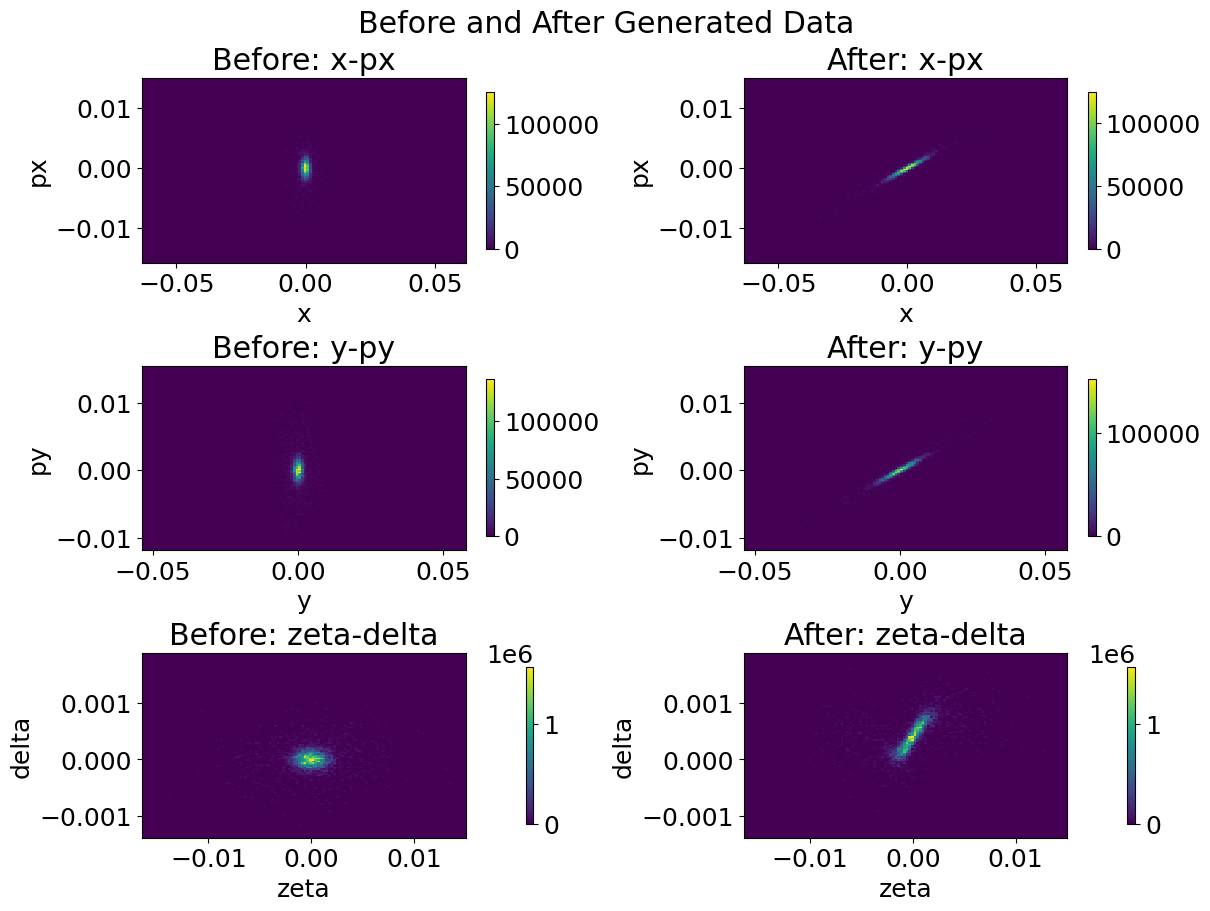

In [58]:
import matplotlib.pyplot as plt

def plot_example_distributions(i: int = 0, bins: int = 100, figsize: tuple = (12, 9),cmap = "viridis", title: str = "Before and After Generated Data") -> None:
    """
    Plot before/after 2D marginal histograms for the i-th example:
      - Row 1: x/px before (left) and after (right)
      - Row 2: y/py before (left) and after (right)
      - Row 3: zeta/delta before (left) and after (right)

    Expects data dict with keys "X_cloud" and "Y_cloud" present in the notebook.
    """
    if "X_cloud" not in data or "Y_cloud" not in data:
        raise RuntimeError("data must contain 'X_cloud' and 'Y_cloud' arrays")

    X = data["X_cloud"]  # shape (n_samples, n_particles, 6)
    Y = data["Y_cloud"]

    n_samples = X.shape[0]
    if not (0 <= i < n_samples):
        raise IndexError(f"i out of range (0 <= i < {n_samples})")

    z_before = X[i].astype(np.float64)  # (n_particles, 6)
    z_after = Y[i].astype(np.float64)

    projections = [
        (0, 3, "x", "px"),
        (1, 4, "y", "py"),
        (2, 5, "zeta", "delta"),
    ]

    fig, axes = plt.subplots(3, 2, figsize=figsize, constrained_layout=True)

    for row, (i, j, xl, yl) in enumerate(projections):
        all2 = np.vstack([z_before[:, [i, j]], z_after[:, [i, j]]])
        xpad = 0.05 * (all2[:, 0].max() - all2[:, 0].min() + 1e-15)
        ypad = 0.05 * (all2[:, 1].max() - all2[:, 1].min() + 1e-15)
        ranges = [
            [all2[:, 0].min() - xpad, all2[:, 0].max() + xpad],
            [all2[:, 1].min() - ypad, all2[:, 1].max() + ypad],
        ]

        im0 = axes[row, 0].hist2d(
            z_before[:, i], z_before[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im0, ax=axes[row, 0], shrink=0.85)
        axes[row, 0].set_title(f"Before: {xl}-{yl}")
        axes[row, 0].set_xlabel(xl)
        axes[row, 0].set_ylabel(yl)

        im1 = axes[row, 1].hist2d(
            z_after[:, i], z_after[:, j],
            bins=bins, range=ranges, density=True, cmap=cmap
        )[3]
        fig.colorbar(im1, ax=axes[row, 1], shrink=0.85)
        axes[row, 1].set_title(f"After: {xl}-{yl}")
        axes[row, 1].set_xlabel(xl)
        axes[row, 1].set_ylabel(yl)

    fig.suptitle(title)
    plt.show()



idx_random = np.random.randint(512)
plot_example_distributions(i=idx_random, bins=120)

In [59]:
from torch.utils.data import Dataset, DataLoader

class CloudDataset(Dataset):
    """
    Expects data dict with:
      X_cloud: [Ns, Np, 6]
      Y_cloud: [Ns, Np, 6]
      MU:      [Ns, m]
    Optionally can use split indices train/val/test in the npz.
    """
    def __init__(self, data: dict, split: str = "train"):
        self.X = data["X_cloud"]
        self.Y = data["Y_cloud"]
        self.MU = data["MU"]

        if split in data:
            self.idx = data[split].astype(np.int64)
        else:
            self.idx = np.arange(self.X.shape[0], dtype=np.int64)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i: int):
        j = int(self.idx[i])
        X = torch.from_numpy(self.X[j]).float()   # [Np,6]
        Y = torch.from_numpy(self.Y[j]).float()   # [Np,6]
        MU = torch.from_numpy(self.MU[j]).float() # [m]
        return X, Y, MU

def make_dummy_lattice_tokens(B: int, N: int, device: str):
    """
    Creates a simple placeholder lattice:
      - all elements are "drifts" with length=1.0
      - everything else 0
    elem_params: [B,N,7] = [L,K1,K2,phi,Vrf,frf,phirf]
    elem_s:      [B,N]   cumulative s at entrance
    """
    elem_params = torch.zeros(B, N, 7, device=device, dtype=torch.float32)
    elem_params[..., 0] = 1.0  # L=1m
    elem_s = torch.cumsum(elem_params[..., 0], dim=1) - elem_params[..., 0]
    return elem_params, elem_s


In [60]:
MU_spec = [
    1e-9,       # Q_bunch in Coulombs -> scale to nC
    1e-3,       # pipe_radius in meters -> scale to mm
    {"unit": 1.0, "op": "log"}  # impedance_scale -> log1p
]

In [61]:
device = 'cuda'
mu_cfg = MUPreprocessConfig(specs=MU_spec, standardize=True, clip=10.0)
mu_prep = MUPreprocessor(mu_cfg).to(device)

mu_train = data["MU"][data["train"]]     # [Ntrain, m]
mu_prep.fit(mu_train)

In [62]:

print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():import torch

print("PyTorch:", torch.__version__)
print("CUDA runtime:", torch.version.cuda)
print("Arch list:", torch.cuda.get_arch_list())
print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
GPU count: 1
PyTorch: 2.11.0+cu130
CUDA runtime: 13.0
Arch list: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']
GPU name: NVIDIA H100 NVL


In [63]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

model = ConditionalBeamVAE(in_ch=15, latent_dim=512, aux_dim=12, domain_dim=2, base_ch=32).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-2)

data = load_npz(path)

print("keys:", sorted(data.keys()))
print("X_cloud:", data["X_cloud"].shape, data["X_cloud"].dtype)
print("Y_cloud:", data["Y_cloud"].shape, data["Y_cloud"].dtype)
print("MU:", data["MU"].shape, data["MU"].dtype)

device = "cuda" if torch.cuda.is_available() else "cpu"

train_ds = CloudDataset(data, split="train" if "train" in data else "train")
val_ds   = CloudDataset(data, split="val" if "val" in data else "val")

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True, num_workers=0, drop_last=True)
val_loader   = DataLoader(val_ds, batch_size=4, shuffle=False, num_workers=0, drop_last=False)

mu_dim = int(data["MU"].shape[-1])

@dataclass
class LossWeights:
    beta: float = 1e-2    # KL weight
    gamma: float = 1   # Sigma weight ( 1e-4 legacy value)
    delta: float = 1   # Centroid weight (1e-4 legacy value)


def kl_divergence_standard_normal(mu: torch.Tensor, logvar: torch.Tensor) -> torch.Tensor:
    """Calculates KL(q||p) where p=N(0,I) and q=N(mu, diag(exp(logvar)))"""
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)  # Returns [B2]


def vae_recon_loss_mse(x_hat: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """Computes density-normalized pixel-level MSE per individual sample batch element."""
    x_hat = x_hat / (x_hat.sum(dim=(-1, -2), keepdim=True) + 1e-12)
    x = x / (x.sum(dim=(-1, -2), keepdim=True) + 1e-12)
    return F.mse_loss(x_hat, x, reduction="none").flatten(1).mean(dim=1)     


def compute_snapshot_vae_loss(
    vae_out: Dict[str, torch.Tensor],
    xy_hist: torch.Tensor,
    aux: torch.Tensor,
    weights: LossWeights = LossWeights(),
    eps: float = 1e-12,
) -> Dict[str, torch.Tensor]:
    """
    Computes unified VAE snapshot losses for a concatenated batch layout [XY].
    Preserves the specialized 8:1 priority weighting between X and Y distributions.
    """
    
    mse_per_sample = vae_recon_loss_mse(vae_out["x_hat"], xy_hist)  
    
    B2 = mse_per_sample.shape[0]
    B = B2 // 2
    
    
    recon_X = mse_per_sample[:B].mean()  
    recon_Y = mse_per_sample[B:].mean()  
    recon_weighted = (8.0 * recon_X) + (1.0 * recon_Y)

    
    kl_per_sample = kl_divergence_standard_normal(vae_out["mu"], vae_out["logvar"]) 
    kl_mean = kl_per_sample.mean()

    
    sigma_true = torch.clamp(aux[:, :6], min=eps)
    log_sigma_true = torch.log(sigma_true)
    
    sigma_loss = F.mse_loss(vae_out["log_sigma_hat"], log_sigma_true)
    centroid_loss = F.mse_loss(vae_out["centroid_hat"], aux[:, 6:]) 

    
    total_loss = (
        recon_weighted 
        + weights.beta * kl_mean 
        + weights.gamma * sigma_loss 
        + weights.delta * centroid_loss
    )

    return {
        "loss": total_loss,
        "recon": recon_weighted, 
        "kl": kl_mean,
        "sigma": sigma_loss,
        "centroid": centroid_loss,
        "recon_X_raw": recon_X, 
        "recon_Y_raw": recon_Y
    }

weights = LossWeights()
N_elem = 3

for epoch in range(500):
    model.train()

    for step, (X, Y, MU) in enumerate(train_loader):
        X = X.to(device)
        Y = Y.to(device)
    
        XY = torch.cat([X, Y], dim=0)
    
        xy_hist = cloud_to_pairwise_hists(XY, nbins=64)
        centroid, sigma = beam_centroid_sigma(XY)
        aux = torch.cat([sigma, centroid], dim=1) 
    
        # --- CREATE DOMAIN VECTOR ---
        B = X.shape[0]
        domain_X = torch.tensor([[1.0, 0.0]], device=device).expand(B, -1)
        domain_Y = torch.tensor([[0.0, 1.0]], device=device).expand(B, -1)
        domain = torch.cat([domain_X, domain_Y], dim=0) # Shape: [2*B, 2]
        # ----------------------------

        opt.zero_grad(set_to_none=True)
    
       
        vae_out = model(xy_hist, aux, domain) 
        
        loss_dict = compute_snapshot_vae_loss(vae_out, xy_hist, aux, weights=weights)
    
        loss_dict["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
    
    if epoch % 50 == 0:
            print(
                f"epoch={epoch:02d} "
                f"loss={loss_dict['loss'].item():.6f} "
                f"recon={loss_dict['recon'].item():.6f} "
                f"kl={loss_dict['kl'].item():.6f}"
            )

torch.save({
    "vae_state_dict": model.state_dict(),
}, "vae_pretrained_TF_causal.pt")

keys: ['MU', 'X_cloud', 'X_lambda', 'Y_cloud', 'Y_lambda', 'centroid_in', 'centroid_out', 'cov_in', 'cov_out', 'family_id', 'test', 'train', 'val', 'zeta_grid']
X_cloud: (512, 4096, 6) float32
Y_cloud: (512, 4096, 6) float32
MU: (512, 3) float32
epoch=00 loss=0.323330 recon=0.000005 kl=1.631306
epoch=50 loss=0.013620 recon=0.000002 kl=0.036664
epoch=100 loss=0.001449 recon=0.000003 kl=0.007766
epoch=150 loss=0.004990 recon=0.000002 kl=0.010342
epoch=200 loss=0.001706 recon=0.000002 kl=0.009948
epoch=250 loss=0.000169 recon=0.000001 kl=0.001737
epoch=300 loss=0.001444 recon=0.000001 kl=0.007527
epoch=350 loss=0.001591 recon=0.000001 kl=0.001735
epoch=400 loss=0.000538 recon=0.000001 kl=0.009829
epoch=450 loss=0.000532 recon=0.000002 kl=0.003849


In [64]:
model_save_path = 'vae_pretrained_TF_causal.pt'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to vae_pretrained_TF_causal.pt


In [65]:
model.eval()

X, Y, MU = next(iter(val_loader))
X = X.to(device)
Y = Y.to(device)
x_hist = cloud_to_pairwise_hists(X, nbins=64)
y_hist = cloud_to_pairwise_hists(Y, nbins=64)

# FIX 1: Compute aux features for X and Y separately so the model gets the right scales
centroid_X, sigma_X = beam_centroid_sigma(X)
aux_X = torch.cat([sigma_X, centroid_X], dim=1).to(device)

centroid_Y, sigma_Y = beam_centroid_sigma(Y)
aux_Y = torch.cat([sigma_Y, centroid_Y], dim=1).to(device)

# FIX 2: Create the separate domain vectors for evaluation
B = X.shape[0]
domain_X = torch.tensor([[1.0, 0.0]], device=device).expand(B, -1)
domain_Y = torch.tensor([[0.0, 1.0]], device=device).expand(B, -1)

with torch.no_grad():
    # FIX 3: Pass both the correct aux and the explicit domain to each forward pass
    outx = model(x_hist, aux_X, domain_X)
    outy = model(y_hist, aux_Y, domain_Y)

x_hat = outx["x_hat"].detach().cpu().numpy()
y_hat = outy["x_hat"].detach().cpu().numpy()
x_true = x_hist.detach().cpu().numpy()
y_true = y_hist.detach().cpu().numpy()

PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

# same PAIR_INDEX order as in the model file
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def plot_sigma_centroid_scatter(sigma_true, sigma_pred, cent_true, cent_pred, title_prefix=""):
    # sigma_*: [B,6], cent_*: [B,6]
    fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)

    # sigmas
    for d in range(6):
        ax = axes[0, d]
        x = sigma_true[:, d]
        y = sigma_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} sigma({PHASE_SPACE_LABELS[d]})")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    # centroids
    for d in range(6):
        ax = axes[1, d]
        x = cent_true[:, d]
        y = cent_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} <{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    return fig

def plot_hist_triplet(truth_map, pred_map, title="", vmax=None):
    """
    truth_map, pred_map: [64,64] arrays
    Shows truth / pred / diff (pred-truth)
    """
    diff = pred_map - truth_map
    vmax = vmax if vmax is not None else float(max(truth_map.max(), pred_map.max()) + 1e-12)
    dv = float(np.max(np.abs(diff)) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = axes[0].imshow(truth_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[0].set_title("Truth")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(pred_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[1].set_title("Pred")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(diff, origin="lower", aspect="auto", vmin=-dv, vmax=dv, cmap="RdBu_r")
    axes[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)
    return fig


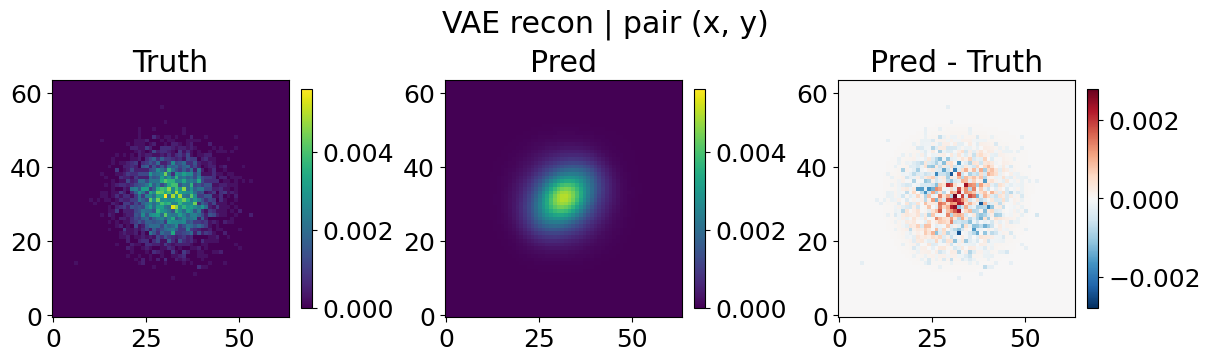

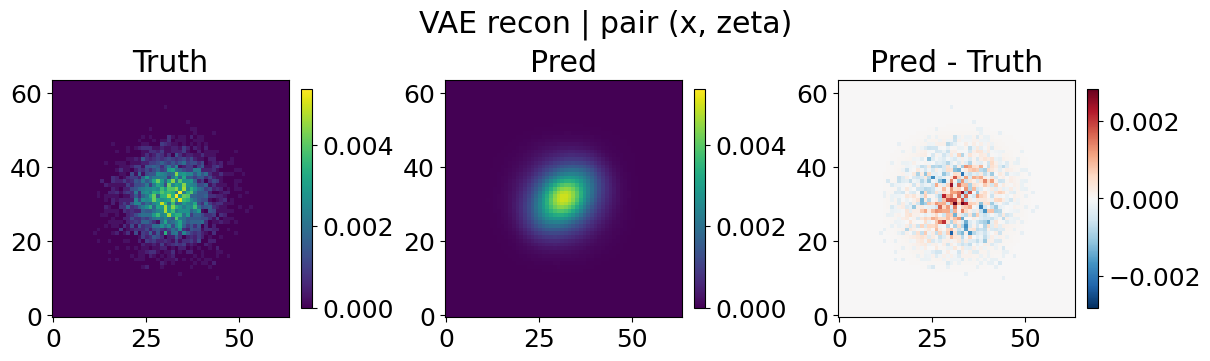

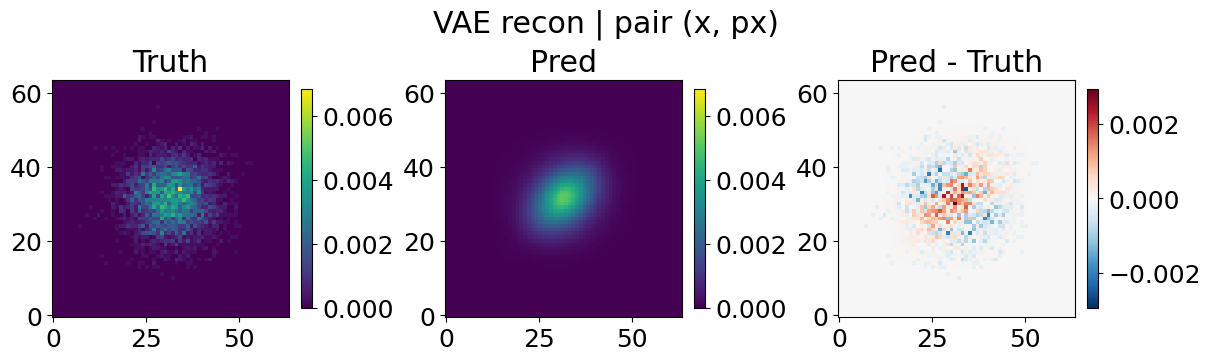

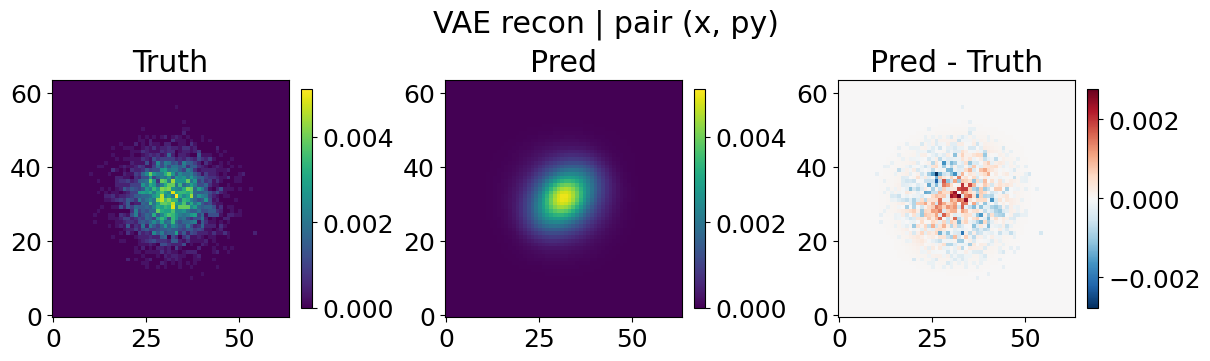

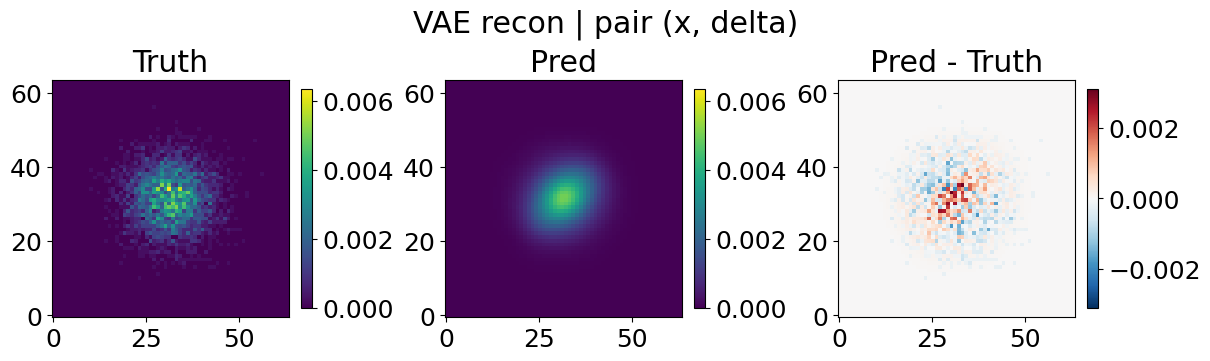

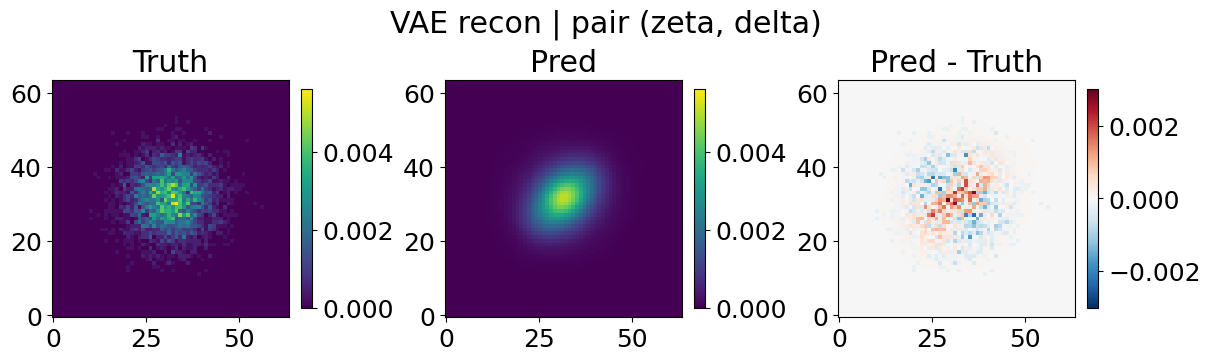

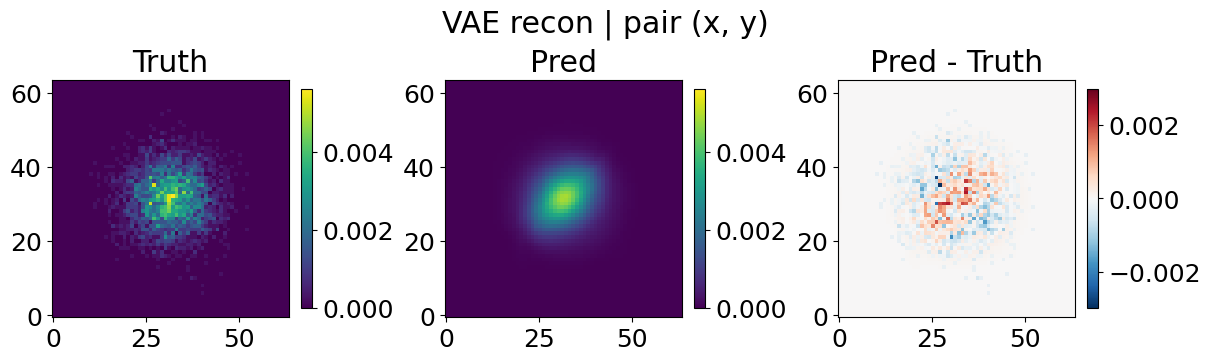

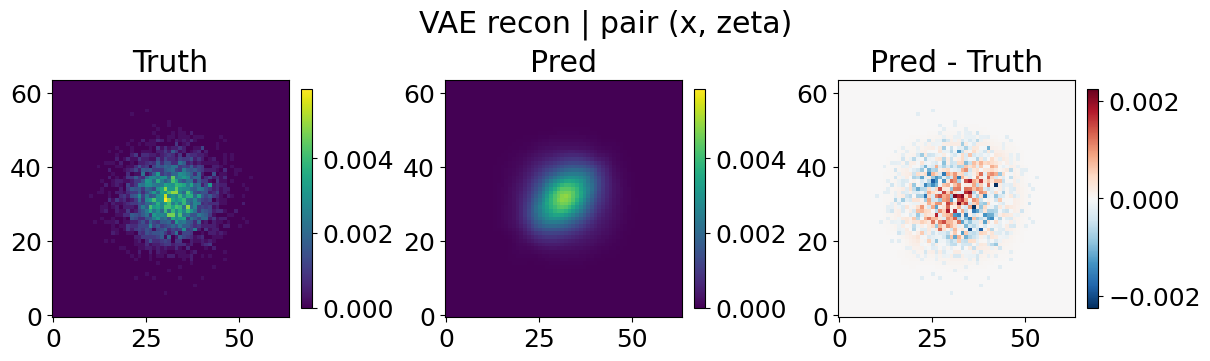

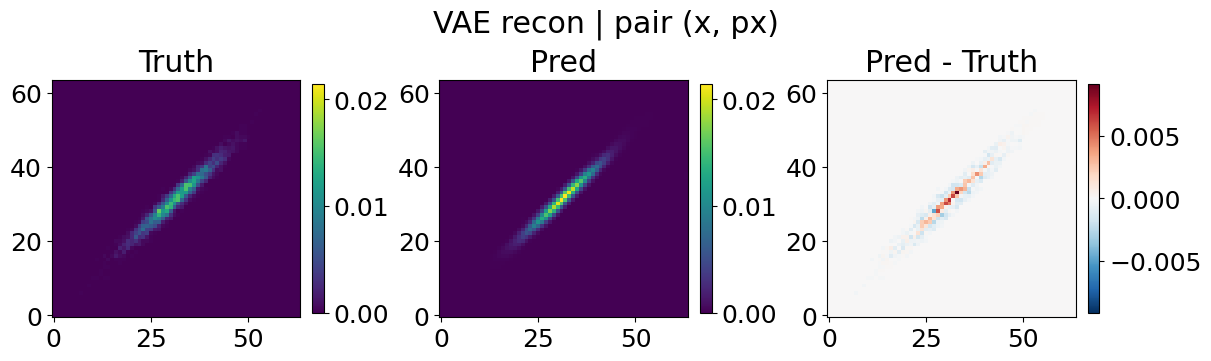

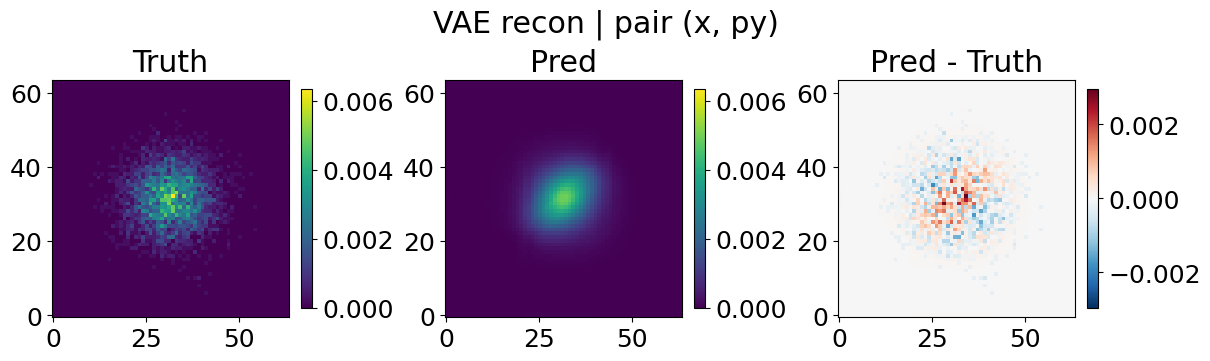

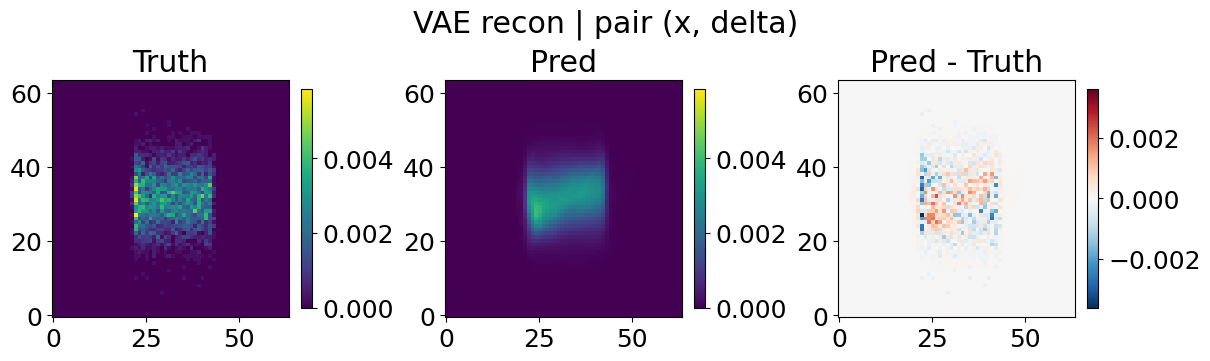

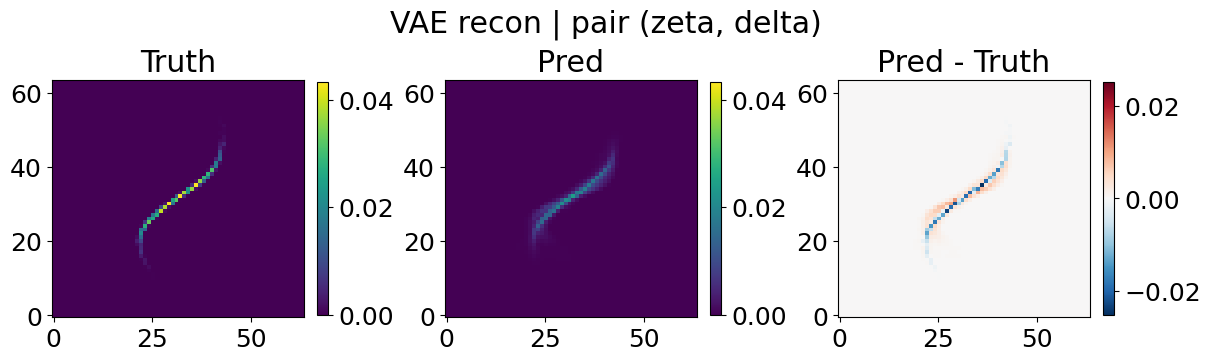

In [66]:
def plot_vae_recon_grid(x_true, x_hat, sample_idx=0, pairs=[0, 1, 2, 3, 4,11]):
    for p in pairs:
        i, j = PAIR_INDEX[p]

        truth = x_true[sample_idx, p]
        pred  = x_hat[sample_idx, p]

        plot_hist_triplet(
            truth,
            pred,
            title=f"VAE recon | pair ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
        )
        plt.show()
plot_vae_recon_grid(x_true, x_hat, sample_idx=3)
plot_vae_recon_grid(y_true, y_hat, sample_idx=3)

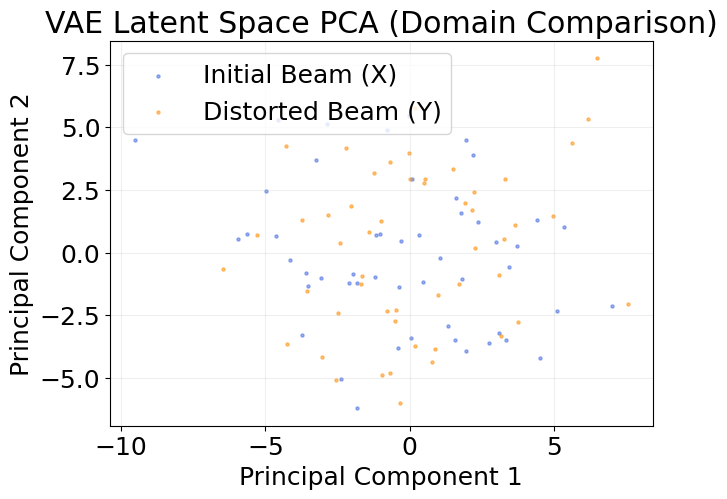

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

Z_X = []
Z_Y = []

with torch.no_grad():
    for X, Y, MU in val_loader:
        X = X.to(device)
        Y = Y.to(device)
        
        # 1. Dynamically capture the current batch size (handles the final batch of 3)
        current_B = X.shape[0] 
        
        # 2. Generate matching domain indicators for this specific batch size
        domain_X = torch.tensor([[1.0, 0.0]], device=device).expand(current_B, -1)
        domain_Y = torch.tensor([[0.0, 1.0]], device=device).expand(current_B, -1)

        # --- Process Initial Beam State (X) ---
        x_hist = cloud_to_pairwise_hists(X, nbins=64)
        centroid_X, sigma_X = beam_centroid_sigma(X)
        aux_batch_X = torch.cat([sigma_X, centroid_X], dim=1)
        
        # FIX: Pass the current batch's aux and the dynamically-sized domain
        z_x = model(x_hist, aux_batch_X, domain_X)["z"]
        Z_X.append(z_x.cpu())

        # --- Process Final Beam State (Y) ---
        y_hist = cloud_to_pairwise_hists(Y, nbins=64)
        centroid_Y, sigma_Y = beam_centroid_sigma(Y)
        aux_batch_Y = torch.cat([sigma_Y, centroid_Y], dim=1)
        
        z_y = model(y_hist, aux_batch_Y, domain_Y)["z"]
        Z_Y.append(z_y.cpu())

# Concatenate all batches together
Z_X = torch.cat(Z_X, dim=0).numpy()
Z_Y = torch.cat(Z_Y, dim=0).numpy()

# Combine both distributions to fit a single shared PCA space
Z_both = np.concatenate([Z_X, Z_Y], axis=0)
Z_pca = PCA(n_components=10).fit_transform(Z_both)

# Split them back apart for plotting
num_X = Z_X.shape[0]
PCA_X = Z_pca[:num_X]
PCA_Y = Z_pca[num_X:]

# Plot both domains to analyze your CVAE latent space
plt.figure(figsize=(7, 5))
plt.scatter(PCA_X[:, 1], PCA_X[:, 3], s=5, alpha=0.5, label="Initial Beam (X)", color="royalblue")
plt.scatter(PCA_Y[:, 1], PCA_Y[:, 3], s=5, alpha=0.5, label="Distorted Beam (Y)", color="darkorange")
plt.title("VAE Latent Space PCA (Domain Comparison)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

/tmp/ipykernel_1281028/551810732.py:55: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([corr_matrix[:, i] for i in range(corr_matrix.shape[1])], labels=phys_labels)


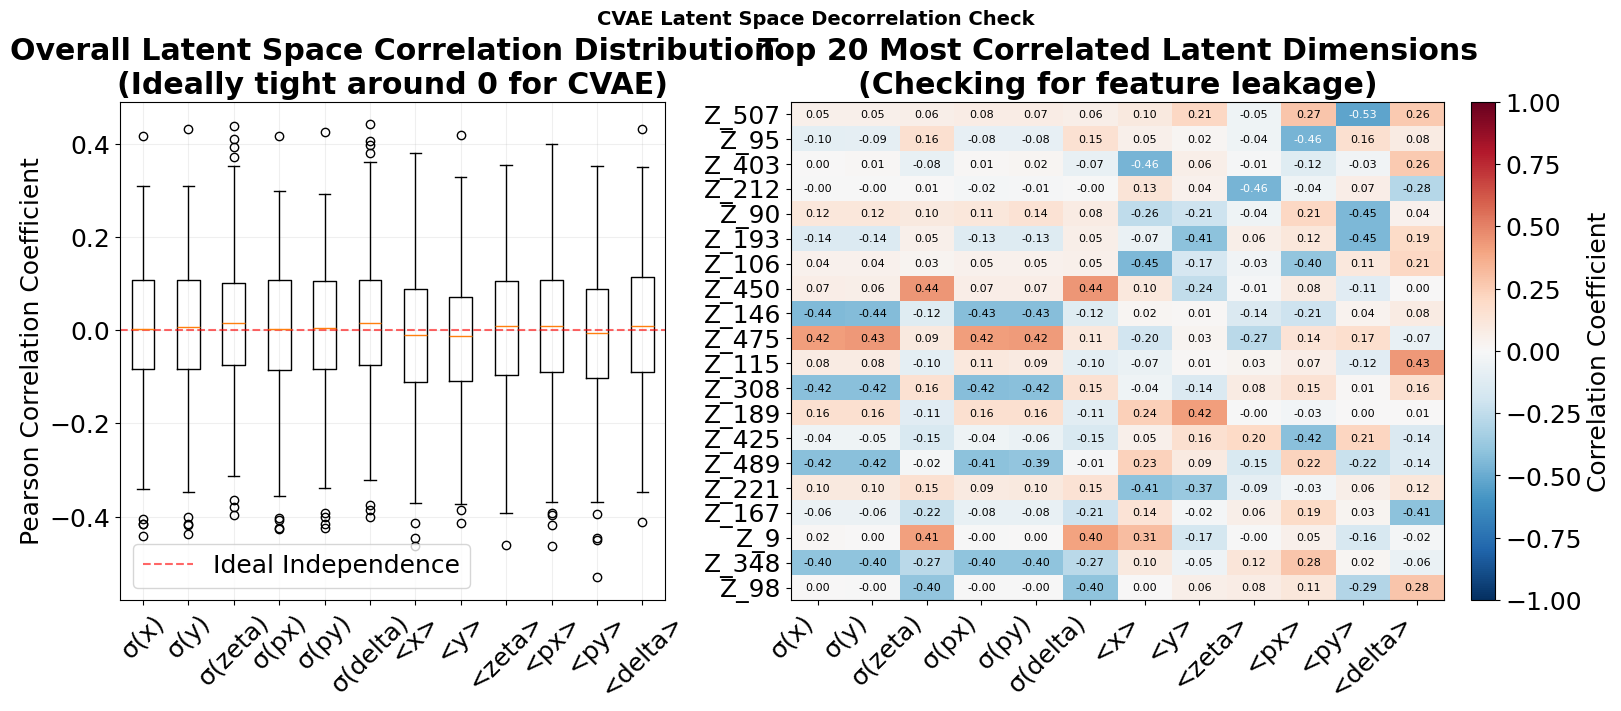

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def latent_correlation_check(model, loader, device, top_k=20):
    model.eval()

    Z, S, C = [], [], []

    with torch.no_grad():
        for X, Y, MU in loader:
            X = X.to(device)
            
            # 1. Handle dynamic batch size (crucial for the last batch)
            current_B = X.shape[0]
            
            # 2. Create the required domain token for the forward pass
            domain_X = torch.tensor([[1.0, 0.0]], device=device).expand(current_B, -1)

            x_hist = cloud_to_pairwise_hists(X, nbins=64)
            centroid, sigma = beam_centroid_sigma(X)

            centroid = centroid.to(device)
            sigma = sigma.to(device)

            aux = torch.cat([sigma, centroid], dim=1)

            # FIX: Pass the explicit domain token here
            z = model(x_hist, aux, domain_X)["z"]

            Z.append(z.cpu())
            S.append(sigma.cpu())
            C.append(centroid.cpu())

    Z = torch.cat(Z).numpy()
    S = torch.cat(S).numpy()
    C = torch.cat(C).numpy()

    # Concatenate physical parameters [Sigmas, Centroids] -> Shape: [N, 12]
    physical_features = np.hstack([S, C])
    latent_dim = Z.shape[1]

    # Compute full Pearson correlation matrix and slice out [Latent vs Physical]
    # Resulting shape: [512, 12]
    corr_matrix = np.corrcoef(Z, physical_features, rowvar=False)[:latent_dim, latent_dim:]

    # Labels matching your phase space order
    PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")
    phys_labels = [f"σ({l})" for l in PHASE_SPACE_LABELS] + [f"<{l}>" for l in PHASE_SPACE_LABELS]

    # --- PLOTTING CODE ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1, 1.2]}, constrained_layout=True)

    # Plot 1: Boxplot showing global correlation distributions
    axes[0].boxplot([corr_matrix[:, i] for i in range(corr_matrix.shape[1])], labels=phys_labels)
    axes[0].axhline(0, color='red', linestyle='--', alpha=0.6, label="Ideal Independence")
    axes[0].set_title("Overall Latent Space Correlation Distribution\n(Ideally tight around 0 for CVAE)", weight='bold')
    axes[0].set_ylabel("Pearson Correlation Coefficient")
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(alpha=0.2)
    axes[0].legend()

    # Plot 2: Heatmap isolating the Top K most correlated latent dimensions
    max_abs_corr = np.max(np.abs(corr_matrix), axis=1)
    top_k = min(top_k, latent_dim)
    top_indices = np.argsort(max_abs_corr)[-top_k:][::-1] # Sorted descending
    
    corr_top_k = corr_matrix[top_indices, :]

    im = axes[1].imshow(corr_top_k, cmap="RdBu_r", vmin=-1, vmax=1, aspect='auto')
    axes[1].set_xticks(np.arange(len(phys_labels)))
    axes[1].set_xticklabels(phys_labels, rotation=45, ha="right")
    axes[1].set_yticks(np.arange(top_k))
    axes[1].set_yticklabels([f"Z_{i}" for i in top_indices])
    axes[1].set_title(f"Top {top_k} Most Correlated Latent Dimensions\n(Checking for feature leakage)", weight='bold')
    
    # Add colorbar
    fig.colorbar(im, ax=axes[1], label='Correlation Coefficient', fraction=0.046, pad=0.04)

    # Annotate values inside the heatmap cells for easy tracking
    for i in range(top_k):
        for j in range(len(phys_labels)):
            val = corr_top_k[i, j]
            text_color = "white" if abs(val) > 0.45 else "black"
            axes[1].text(j, i, f"{val:.2f}", ha="center", va="center", color=text_color, fontsize=8)

    plt.suptitle("CVAE Latent Space Decorrelation Check", fontsize=14, weight='bold')
    plt.show()

# Run the adapted visualization function
latent_correlation_check(model, val_loader, device, top_k=20)

In [ ]:

print("--- Split Arrays ---")
for split_key in ['train', 'val', 'test']:
    if split_key in data:
        print(f"{split_key}: shape={data[split_key].shape}, dtype={data[split_key].dtype}")
        # If it's a small array of indices or strings, print the first few elements
        try:
            print(f"  First 5 elements: {data[split_key][:5]}")
        except:
            pass

print("\n--- Family IDs ---")
if 'family_id' in data:
    print(f"family_id: shape={data['family_id'].shape}, dtype={data['family_id'].dtype}")
    print(f"Unique family configurations found: {np.unique(data['family_id'])}")

print(f"{'Key':<20} | {'Type/Shape':<20}")
print("-" * 45)
for key in data.keys():
    item = data[key]
    if hasattr(item, 'shape'):
        print(f"{key:<20} | Shape: {item.shape}")
    else:
        print(f"{key:<20} | Type: {type(item).__name__}")

In [ ]:
def make_fodo_lattice_tokens(batch_size, N_elem=3, device="cpu"):
    """
    Generates a  3-element accelerator lattice token sequence:
    [Quad F -> RF Bunching Cavity -> Quad D]
    
    Columns: [L, K1, K2, phi, Vrf, frf, phirf]
    """
    # Element 1: Focusing Quadrupole with minor geometric aberrations & alignment tilt
    quad_f = [0.25, 1.25, 0.05, 0.001, 0.005, 352.2, 0.0]
    
    # Element 2: RF Cavity run at a standard 352.2 MHz with a bunching phase (-pi/2)
    rf_cav = [0.35, 0.02, 0.00, 0.000, 2.500, 352.2, -1.5708]
    
    # Element 3: Defocusing Quadrupole balancing the triplet segment
    quad_d = [0.25, -1.25, -0.05, -0.001, 0.005, 352.2, 0.0]
    
    # Combine into a structured layout tensor [3, 7]
    fodo_pattern = torch.tensor([quad_f, rf_cav, quad_d], dtype=torch.float32, device=device)
    
    # Cumulative longitudinal position 's' where each element ends (meters)
    fodo_s = torch.tensor([0.25, 0.60, 0.85], dtype=torch.float32, device=device)
    
    # Broadcast smoothly across your validation batch size
    elem_params = fodo_pattern.unsqueeze(0).repeat(batch_size, 1, 1)
    elem_s = fodo_s.unsqueeze(0).repeat(batch_size, 1)
    
    return elem_params, elem_s

In [71]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from dataclasses import dataclass
from typing import Dict, Optional

# Ensure device configuration
device = "cuda" if torch.cuda.is_available() else "cpu"

class BeamLatentTrackingModel(nn.Module):
    def __init__(self, mu_dim: int, latent_dim: int = 512, d_model: int = 512, domain_dim: int = 2):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim
        self.domain_dim = domain_dim

        self.vae = ConditionalBeamVAE(
            in_ch=15, 
            latent_dim=latent_dim, 
            aux_dim=12, 
            domain_dim=domain_dim, 
            base_ch=32
        )

        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        self.tracker = TrackingTransformer(latent_dim=latent_dim, d_model=d_model, n_layers=6, n_heads=8, dropout=0.1)

        self.mu_to_z = nn.Sequential(
            nn.Linear(mu_dim, 256),
            nn.GELU(),
            nn.Linear(256, latent_dim),
        )
        self.z_to_aux_features = nn.Sequential(
            nn.Linear(latent_dim, 1024),
            nn.GELU()
        )

    def forward(
        self,
        X_cloud: torch.Tensor,
        MU: torch.Tensor,
        elem_params: torch.Tensor,
        elem_s: torch.Tensor,
        domain: torch.Tensor,  # FIX 2: Accept the domain tensor [B, domain_dim]
        *,
        mode: str = "AR",
        z_prev_traj: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        
        # Build histograms from X_cloud
        x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)

        # Aux ground truth for X_cloud
        centroid, sigma = beam_centroid_sigma(X_cloud)
        aux = torch.cat([sigma, centroid], dim=1)

        # FIX 3: Pass domain conditioning tensor into the VAE forward pass
        vae_out = self.vae(x_hist, aux, domain)
        z0 = vae_out["z"]

        # MU conditioning (additive to z0)
        z0 = z0 + self.mu_to_z(MU.to(z0.dtype))

        # Tokenize lattice
        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)

        if mode.upper() == "TF":
            if z_prev_traj is None:
                raise ValueError("mode='TF' requires z_prev_traj=[B,N,latent].")
            z_pred = self.tracker.forward_teacher_forcing(z_prev_traj, elem_tokens)
        else:
            z_pred = self.tracker.forward_autoregressive(z0, elem_tokens)

        zN = z_pred[:, -1, :]

        xN_hat = self.vae.decode(zN, domain)

        hN_pseudo = self.z_to_aux_features(zN)
        log_sigmaN_hat = self.vae.aux_logsigma_head(hN_pseudo)
        sigmaN_hat = torch.exp(log_sigmaN_hat)
        centroidN_hat = self.vae.aux_centroid_head(hN_pseudo)

        return {
            "x_hist": x_hist,
            "aux": aux,
            "z0": z0,
            "vae": vae_out,
            "z_pred_traj": z_pred,
            "zN": zN,
            "xN_hat": xN_hat,
            "log_sigmaN_hat": log_sigmaN_hat,
            "sigmaN_hat": sigmaN_hat,
            "centroidN_hat": centroidN_hat,
        }

# --- 2. FIXED LOSS & UTILITY FUNCTIONS ---

def compute_total_loss(out: Dict[str, torch.Tensor], Y_cloud: torch.Tensor, eps: float = 1e-12) -> Dict[str, torch.Tensor]:
    """Computes downstream tracking loss profile against true final beam state Y"""
    xN_hat = out["xN_hat"]
    y_hist = cloud_to_pairwise_hists(Y_cloud, nbins=64)
    
    # PDF scale normalization
    xN_hat = xN_hat / (xN_hat.sum(dim=(-1, -2), keepdim=True) + eps)
    y_hist = y_hist / (y_hist.sum(dim=(-1, -2), keepdim=True) + eps)
    
    # 1. Profile Reconstruction Loss at downstream position N
    reconN = F.mse_loss(xN_hat, y_hist, reduction="none").sum(dim=(-1, -2)).mean()
    
    # 2. Scalar parameter metrics evaluation at downstream position N
    centroid_Y, sigma_Y = beam_centroid_sigma(Y_cloud)
    sigma_loss = F.mse_loss(out["log_sigmaN_hat"], torch.log(torch.clamp(sigma_Y, min=eps)))
    centroid_loss = F.mse_loss(out["centroidN_hat"], centroid_Y)
    
    # 3. Extract mu and logvar from the nested vae dictionary for logging
    mu = out["vae"]["mu"]
    logvar = out["vae"]["logvar"]
    kl = 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1).mean()
    
    # Since the CVAE is frozen, its own encoder losses don't backpropagate gradients
    # to your transformer tracker. We optimize strictly for final state prediction.
    total_loss = reconN + 1e-4 * sigma_loss + 1e-4 * centroid_loss
    
    # FIX: Return the dictionary your training loop prints expect
    return {
        "loss": total_loss,
        "reconN": reconN,
        "kl": kl,
        "sigma_loss": sigma_loss,
        "centroid_loss": centroid_loss
    }


# --- 3. PREPARE TRACKING ENVIRONMENT & LOOPS ---

# (Assuming 'path', 'val_loader', 'train_loader', 'N_elem', and 'make_dummy_lattice_tokens' are defined earlier)
data = load_npz(path)
mu_dim = int(data["MU"].shape[-1])

# Instantiate and pre-fit your provided MUPreprocessor module
mu_cfg = MUPreprocessConfig(specs=[1.0] * mu_dim, standardize=True)
mu_prep = MUPreprocessor(mu_cfg)
mu_prep.fit(data["MU"])  
mu_prep.to(device)

# Instantiate the full framework (domain_dim defaults to 2)
model = BeamLatentTrackingModel(mu_dim=mu_dim, latent_dim=512, d_model=512, domain_dim=2).to(device)

# Filter optimizer parameters so it strictly excludes frozen CVAE weights
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=3e-4, 
    weight_decay=1e-2
)

def run_eval():
    model.eval()
    losses = []
    with torch.no_grad():
        for X, Y, MU in val_loader:
            X, Y, MU = X.to(device), Y.to(device), MU.to(device)
            MU_enc = mu_prep(MU) 
            B = X.shape[0]
            
            # FIX: Extract or create your 2D domain tensor here. 
            # For now, we take a slice of MU or mock it. Adjust to match your real domain data!
            domain = MU[:, :2] 
            
            elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
            
            # FIX: Passed the domain tensor to the forward call
            out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")
            ld = compute_total_loss(out, Y)
            losses.append(ld["loss"].item())
    return float(np.mean(losses)) if losses else float("nan")


# --- 4. EXECUTE DYNAMICS TRAINING ---

for epoch in range(100):
    model.train()
    model.vae.eval()  # Keep underlying CVAE weights frozen

    for step, (X, Y, MU) in enumerate(train_loader):
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        
        MU_enc = mu_prep(MU)
        B = X.shape[0]
        
        # FIX: Extract or create your 2D domain tensor here.
        # Ensure it maps to whatever properties your pre-trained Conditional VAE used.
        domain = MU[:, :2] 

        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

        opt.zero_grad(set_to_none=True)
        
        # FIX: Passed the domain tensor here as well
        out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")
        ld = compute_total_loss(out, Y)
        
        ld["loss"].backward()
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 1.0)
        opt.step()

        

    val_loss = run_eval()
    print(f"[epoch {epoch}] val_loss={val_loss:.6f}")

/tmp/ipykernel_1281028/2461903466.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


[epoch 0] val_loss=0.002401
[epoch 1] val_loss=0.002225
[epoch 2] val_loss=0.001554
[epoch 3] val_loss=0.001385
[epoch 4] val_loss=0.001307
[epoch 5] val_loss=0.001429
[epoch 6] val_loss=0.001322
[epoch 7] val_loss=0.001286
[epoch 8] val_loss=0.001296
[epoch 9] val_loss=0.001270
[epoch 10] val_loss=0.001274
[epoch 11] val_loss=0.001267
[epoch 12] val_loss=0.001244
[epoch 13] val_loss=0.001234
[epoch 14] val_loss=0.001254
[epoch 15] val_loss=0.001161
[epoch 16] val_loss=0.001244
[epoch 17] val_loss=0.001221
[epoch 18] val_loss=0.001204
[epoch 19] val_loss=0.001032
[epoch 20] val_loss=0.001341
[epoch 21] val_loss=0.000484
[epoch 22] val_loss=0.000435
[epoch 23] val_loss=0.000377
[epoch 24] val_loss=0.000359
[epoch 25] val_loss=0.000382
[epoch 26] val_loss=0.000410
[epoch 27] val_loss=0.000339
[epoch 28] val_loss=0.000329
[epoch 29] val_loss=0.000346
[epoch 30] val_loss=0.000369
[epoch 31] val_loss=0.000364
[epoch 32] val_loss=0.000316
[epoch 33] val_loss=0.000322
[epoch 34] val_loss=0.00

In [72]:
model_save_path = 'trained_beam_latent_transformer_model_causal.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to trained_beam_latent_transformer_model_causal.pth


In [73]:
model_load_path = 'trained_beam_latent_transformer_model_causal.pth'

loaded_model = BeamLatentTrackingModel(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)

# Load the state dictionary
loaded_model.load_state_dict(torch.load(model_load_path))
loaded_model.eval() 

print(f"Model loaded from {model_load_path}")

/tmp/ipykernel_1281028/2461903466.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Model loaded from trained_beam_latent_transformer_model_causal.pth


In [74]:
PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

# same PAIR_INDEX order as in the model file
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def plot_sigma_centroid_scatter(sigma_true, sigma_pred, cent_true, cent_pred, title_prefix=""):
    # sigma_*: [B,6], cent_*: [B,6]
    fig, axes = plt.subplots(2, 6, figsize=(18, 6), constrained_layout=True)

    # sigmas
    for d in range(6):
        ax = axes[0, d]
        x = sigma_true[:, d]
        y = sigma_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} sigma({PHASE_SPACE_LABELS[d]})")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    # centroids
    for d in range(6):
        ax = axes[1, d]
        x = cent_true[:, d]
        y = cent_pred[:, d]
        ax.scatter(x, y, s=8, alpha=0.6)
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"{title_prefix} <{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("truth")
        ax.set_ylabel("pred")
        ax.grid(alpha=0.2)

    return fig

def plot_hist_triplet(truth_map, pred_map, title="", vmax=None):
    """
    truth_map, pred_map: [64,64] arrays
    Shows truth / pred / diff (pred-truth)
    """
    diff = pred_map - truth_map
    vmax = vmax if vmax is not None else float(max(truth_map.max(), pred_map.max()) + 1e-12)
    dv = float(np.max(np.abs(diff)) + 1e-12)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    im0 = axes[0].imshow(truth_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[0].set_title("Truth")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(pred_map, origin="lower", aspect="auto", vmin=0.0, vmax=vmax)
    axes[1].set_title("Pred")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)

    im2 = axes[2].imshow(diff, origin="lower", aspect="auto", vmin=-dv, vmax=dv, cmap="RdBu_r")
    axes[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

    fig.suptitle(title)
    return fig


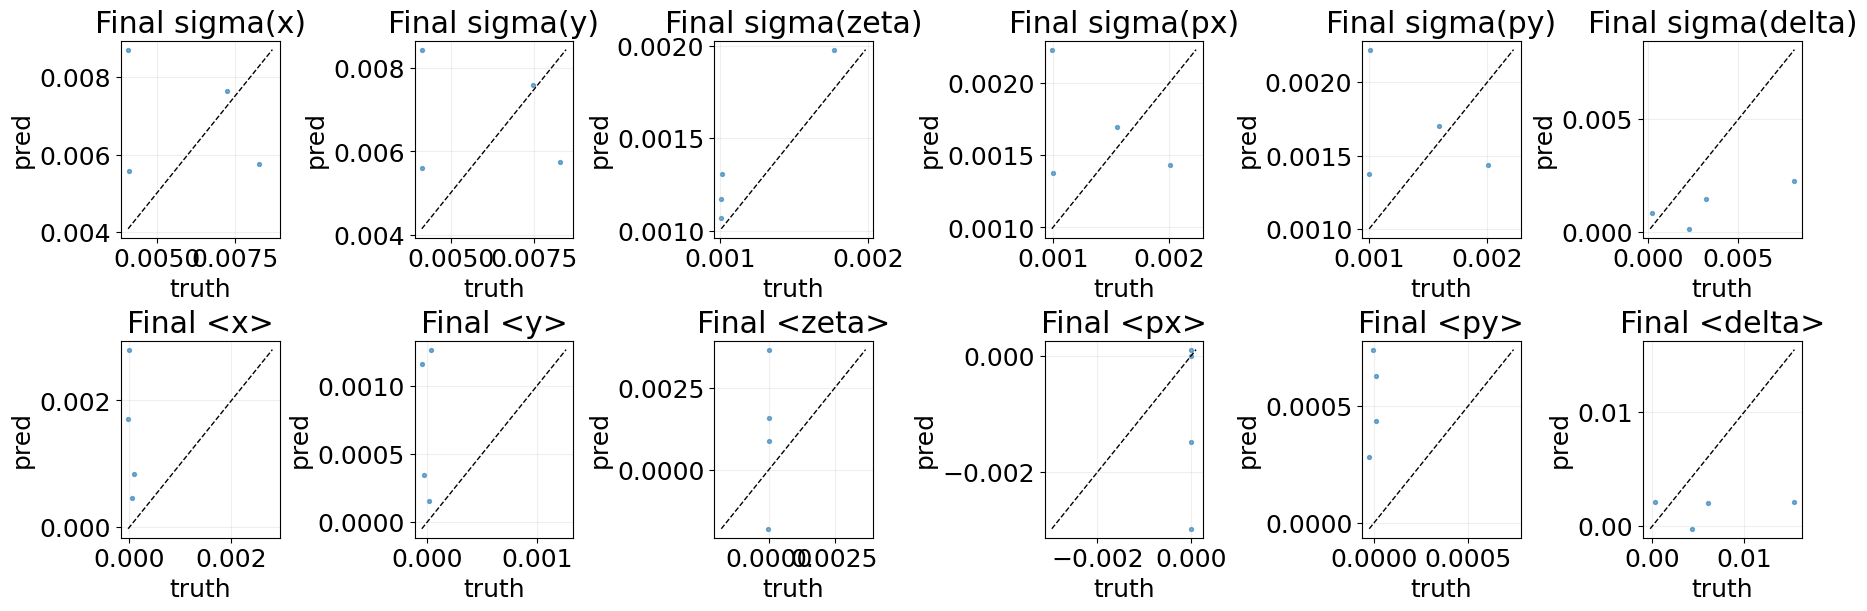

In [75]:
model = loaded_model
model.eval()
X, Y, MU = next(iter(val_loader))

X = X.to(device)
Y = Y.to(device)
MU = MU.to(device)

N_elem = 3  # paper uses N=32; choose any fixed number for dummy run
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

# Correct usage for your updated conditional architecture:
with torch.no_grad():
    out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")

# truth stats from Y_cloud
cent_true_t, sig_true_t = beam_centroid_sigma(Y)  # centroid, sigma
sig_pred_t = out["sigmaN_hat"]
cent_pred_t = out["centroidN_hat"]

# move to numpy
sig_true = sig_true_t.detach().cpu().numpy()
sig_pred = sig_pred_t.detach().cpu().numpy()
cent_true = cent_true_t.detach().cpu().numpy()
cent_pred = cent_pred_t.detach().cpu().numpy()

# scatter plots
plot_sigma_centroid_scatter(sig_true, sig_pred, cent_true, cent_pred, title_prefix="Final")
plt.show()


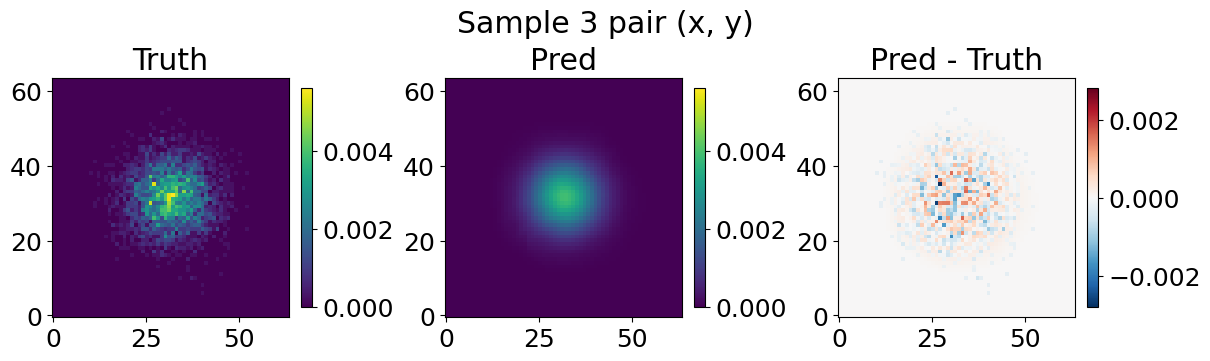

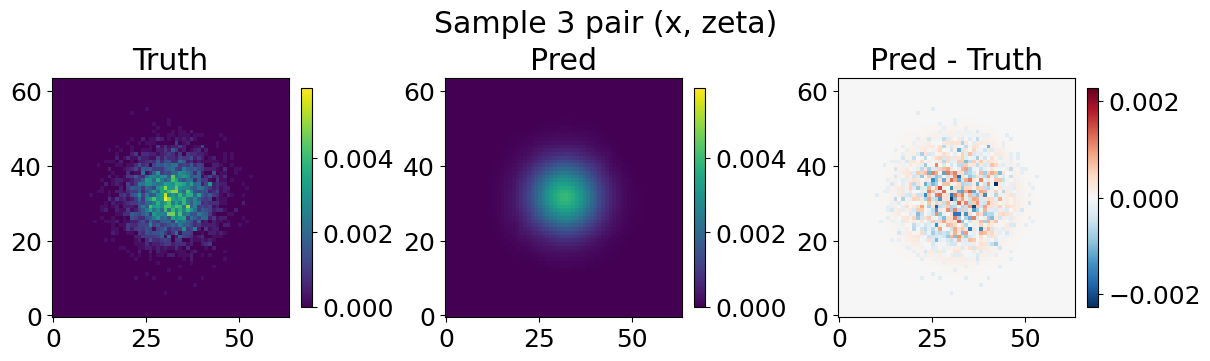

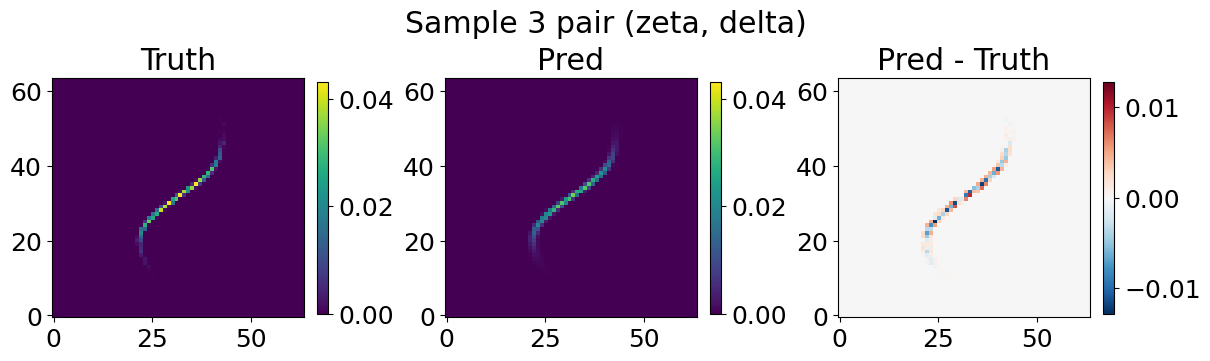

In [76]:
y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()      # [B,15,64,64]
y_hat = out["xN_hat"].detach().cpu().numpy()                             # [B,15,64,64]

sample_idx = 3
pairs_to_plot = [0, 1, 11]  

for pidx in pairs_to_plot:
    i, j = PAIR_INDEX[pidx]
    title = f"Sample {sample_idx} pair ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
    truth_map = y_hist[sample_idx, pidx]
    pred_map = y_hat[sample_idx, pidx]
    plot_hist_triplet(truth_map, pred_map, title=title)
    plt.show()

truth: min=0.000e+00 max=9.033e-03 mean=2.441e-04 sum=1.000e+00
pred: min=0.000e+00 max=5.846e-03 mean=2.441e-04 sum=1.000e+00


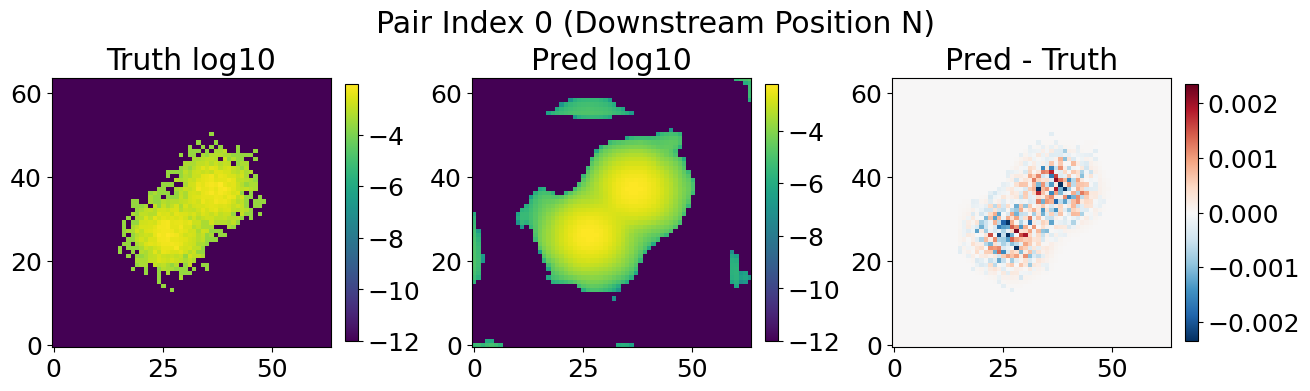

In [80]:
import numpy as np
import matplotlib.pyplot as plt

def describe_map(a, name="map"):
    a = np.asarray(a)
    print(f"{name}: min={a.min():.3e} max={a.max():.3e} mean={a.mean():.3e} sum={a.sum():.3e}")

def plot_triplet_log(truth, pred, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth

    # Use truth-based vmax so you can see structure
    vmax = float(np.percentile(truth, 99.9) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)

    # log images: log10(x + eps)
    eps = 1e-12
    tlog = np.log10(truth + eps)
    plog = np.log10(pred  + eps)

    # diff uses symmetric linear scale
    dv = float(np.percentile(np.abs(diff), 99.9) + 1e-12)

    fig, ax = plt.subplots(1, 3, figsize=(13, 3.8), constrained_layout=True)

    im0 = ax[0].imshow(tlog, origin="lower", aspect="auto")
    ax[0].set_title("Truth log10")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    im1 = ax[1].imshow(plog, origin="lower", aspect="auto")
    ax[1].set_title("Pred log10")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    im2 = ax[2].imshow(diff, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred - Truth")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title)
    plt.show()

# --- run on ONE sample from val ---
model.eval()

# 1. Fetch batch and move to device
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
B = X.shape[0]

# 2. FIX: Apply preprocessing to MU alignment before passing to the tracking layer
MU_enc = mu_prep(MU)

# 3. FIX: Extract the 2D domain conditioning tensor (adjust the slice if needed)
domain = MU[:, :2]

# 4. Generate dummy lattice tokens
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

# 5. FIX: Forward pass with both MU_enc and domain routing included
with torch.no_grad():
    out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")

# 6. Convert tracking profiles to numpy arrays for plotting
y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()
y_hat  = out["xN_hat"].detach().cpu().numpy()

# 7. Select a single sample and a specific 2D phase-space projection channel to plot
sample_idx = 0
pidx = 0  # Pick a pairwise map (0 to 14)
truth_map = y_hist[sample_idx, pidx]
pred_map  = y_hat[sample_idx, pidx]

# 8. Output metrics and plot the downstream triplet
describe_map(truth_map, "truth")
describe_map(pred_map,  "pred")

plot_triplet_log(truth_map, pred_map, title=f"Pair Index {pidx} (Downstream Position N)")

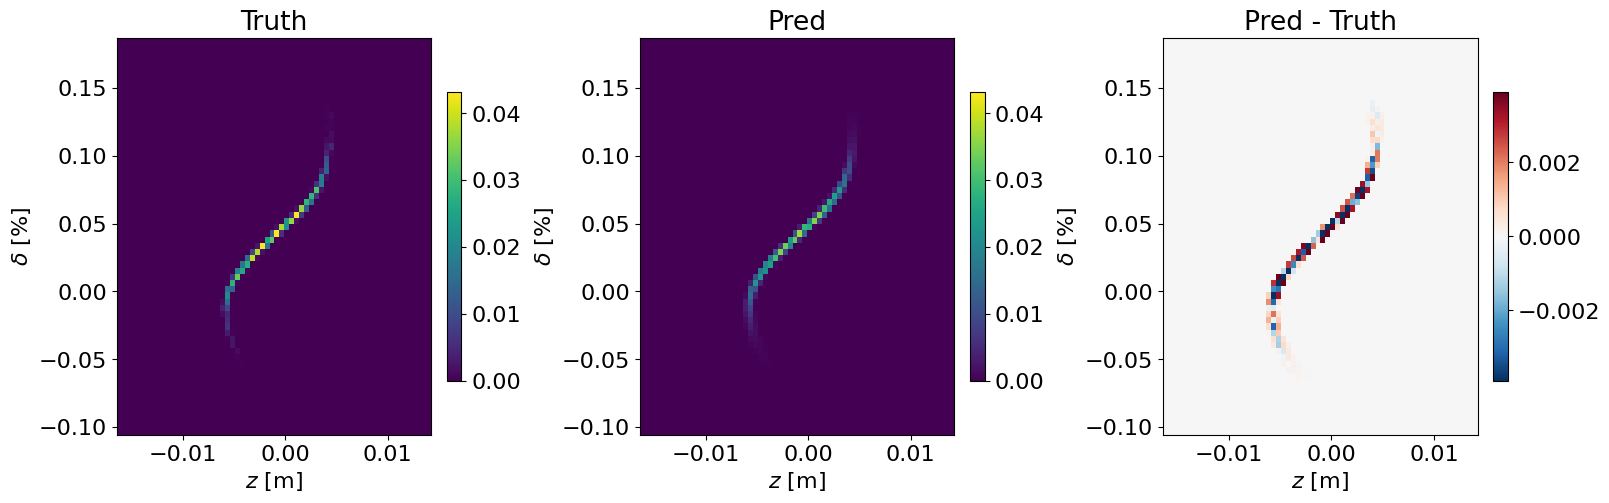

In [82]:
import matplotlib.pyplot as plt
import numpy as np

def show_triplet_physical(truth, pred, physical_cloud_after, title=""):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    diff  = pred - truth
    ny, nz = truth.shape

    # --- Extract Same Physical Coordinate Scaling Logic ---
    zeta_physical = physical_cloud_after[:, 2].astype(np.float64)
    delta_physical = physical_cloud_after[:, 5].astype(np.float64) * 100.0  # Percentage scale
    
    z_pad = 0.05 * (zeta_physical.max() - zeta_physical.min() + 1e-15)
    d_pad = 0.05 * (delta_physical.max() - delta_physical.min() + 1e-15)
    
    # Calculate exact edge bounds for the physical image mapping
    z_min_phys, z_max_phys = zeta_physical.min() - z_pad, zeta_physical.max() + z_pad
    d_min_phys, d_max_phys = delta_physical.min() - d_pad, delta_physical.max() + d_pad

    # Extent format for imshow: [left, right, bottom, top]
    # x-axis = z [m], y-axis = delta [%]
    img_extent = [z_min_phys, z_max_phys, d_min_phys, d_max_phys]

    # --- Intensity Scaling Config ---
    vmax = float(np.percentile(truth, 99.5) + 1e-12)
    vmax = max(vmax, float(truth.max()) + 1e-12)
    dv   = float(np.percentile(np.abs(diff), 99.5) + 1e-12)

    # --- Plot Layout ---
    fig, ax = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
    
    # Truth Plot
    im0 = ax[0].imshow(truth, origin="lower", extent=img_extent, aspect="auto", vmin=0.0, vmax=vmax)
    ax[0].set_title("Truth")
    ax[0].set_xlabel(r"$z$ [m]")
    ax[0].set_ylabel(r"$\delta$ [%]")
    plt.colorbar(im0, ax=ax[0], fraction=0.046)

    # Prediction Plot
    im1 = ax[1].imshow(pred, origin="lower", extent=img_extent, aspect="auto", vmin=0.0, vmax=vmax)
    ax[1].set_title("Pred")
    ax[1].set_xlabel(r"$z$ [m]")
    ax[1].set_ylabel(r"$\delta$ [%]")
    plt.colorbar(im1, ax=ax[1], fraction=0.046)

    # Residual Plot
    im2 = ax[2].imshow(diff, origin="lower", extent=img_extent, aspect="auto", cmap="RdBu_r", vmin=-dv, vmax=dv)
    ax[2].set_title("Pred - Truth")
    ax[2].set_xlabel(r"$z$ [m]")
    ax[2].set_ylabel(r"$\delta$ [%]")
    plt.colorbar(im2, ax=ax[2], fraction=0.046)

    fig.suptitle(title, weight="bold")
    plt.savefig("zeta_delta_HEB.pdf", bbox_inches='tight')
    plt.show()

# --- Execution Update ---
# Compute prediction
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
with torch.no_grad():
    #out = model(X, MU, elem_params, elem_s, mode="AR")
    out = model(X, MU, elem_params, elem_s, domain, mode="AR")
y_pred = out["xN_hat"].detach().cpu().numpy()

b = 3
pidx = 11
plt.rcParams.update({'font.size': 16}) # Adjusted slightly lower so labels clear colorbars cleanly

# Pass your matching physical point cloud tensor into the function
show_triplet_physical(
    truth=y_hist[b, pidx], 
    pred=y_pred[b, pidx], 
    physical_cloud_after=data["Y_cloud"][idx_random], # Ensure idx_random aligns with your test batch item
    title=r"",#Sample 3 Pair Physical Phase Space ($z$, $\delta$)"
)

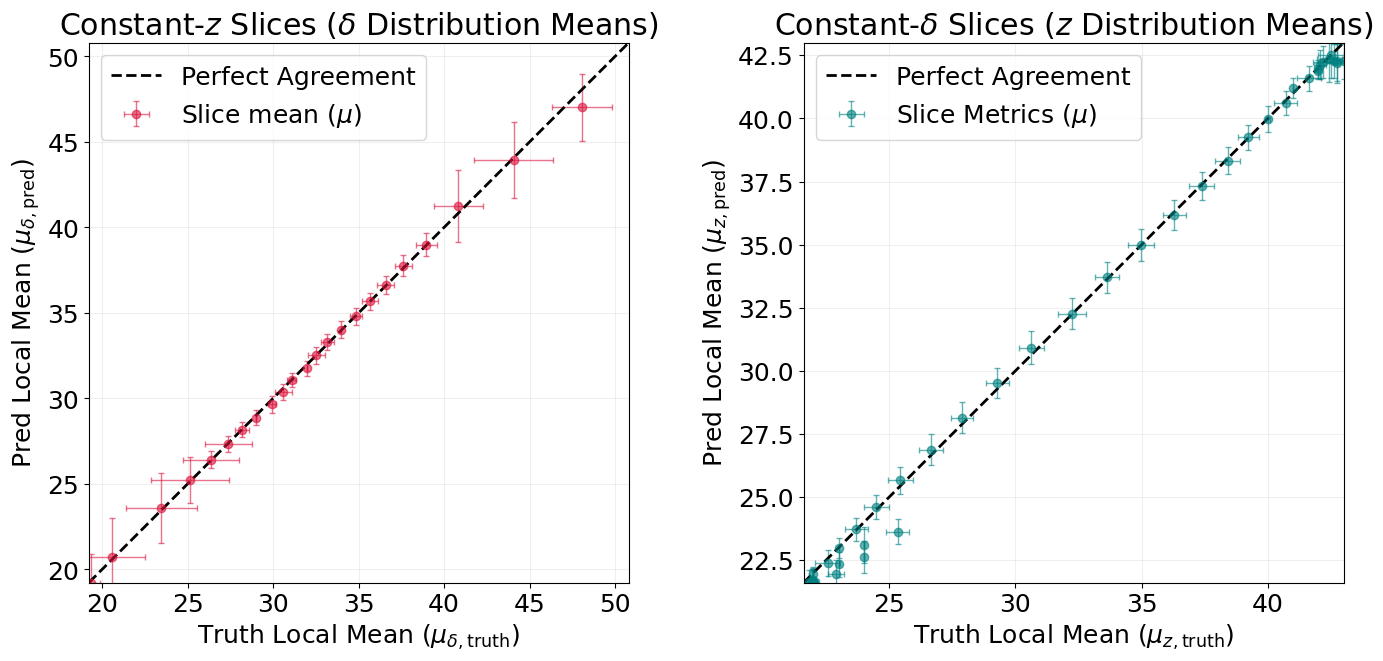

In [83]:
import matplotlib.pyplot as plt
import numpy as np

def compute_slice_conditional_stats(image, axis, std_threshold=15.0):
    """
    Computes the intensity-weighted mean and standard deviation along 
    the chosen axis for every slice.
    
    axis=0 means we slice vertically (constant-z slices, look at delta profile)
    axis=1 means we slice horizontally (constant-delta slices, look at z profile)
    """
    num_slices = image.shape[1 if axis == 0 else 0]
    profile_length = image.shape[0 if axis == 0 else 1]
    coord_indices = np.arange(profile_length)
    
    means = np.zeros(num_slices)
    stds = np.zeros(num_slices)
    
    for idx in range(num_slices):
        # Extract the 1D slice profile
        slice_profile = image[:, idx] if axis == 0 else image[idx, :]
        total_intensity = np.sum(slice_profile)
        
        if total_intensity > 1e-8:
            # 1. Compute intensity-weighted local mean
            mu = np.sum(coord_indices * slice_profile) / total_intensity
            
            # 2. Compute intensity-weighted local standard deviation
            variance = np.sum(((coord_indices - mu) ** 2) * slice_profile) / total_intensity
            sigma = np.sqrt(max(0, variance))
            
            # Apply your threshold logic: if std is too big, set it to 0
            if sigma > std_threshold:
                sigma = 0.0
        else:
            mu, sigma = np.nan, 0.0
            
        means[idx] = mu
        stds[idx] = sigma
        
    return means, stds

def plot_conditional_metric_correlation(truth, pred, title="", std_threshold=15.0):
    truth = np.asarray(truth)
    pred  = np.asarray(pred)
    
    # 1. Constant-z slices (axis=0): Evaluating conditional delta distributions
    mu_zt, sigma_zt = compute_slice_conditional_stats(truth, axis=0, std_threshold=std_threshold)
    mu_zp, sigma_zp = compute_slice_conditional_stats(pred, axis=0, std_threshold=std_threshold)
    
    # 2. Constant-delta slices (axis=1): Evaluating conditional z distributions
    mu_dt, sigma_dt = compute_slice_conditional_stats(truth, axis=1, std_threshold=std_threshold)
    mu_dp, sigma_dp = compute_slice_conditional_stats(pred, axis=1, std_threshold=std_threshold)
    
    # Setup 1x2 Square Layout Grid
    fig, ax = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)
    
    # Find unified limits for the perfect square formatting
    lim_z = [min(np.nanmin(mu_zt), np.nanmin(mu_zp)), max(np.nanmax(mu_zt), np.nanmax(mu_zp))]
    lim_d = [min(np.nanmin(mu_dt), np.nanmin(mu_dp)), max(np.nanmax(mu_dt), np.nanmax(mu_dp))]

    # =========================================================================
    # SUBPLOT 1: Constant-z Slices (Conditional delta means)
    # =========================================================================
    # We use errorbar where xerr is Truth std, yerr is Pred std
    ax[0].errorbar(mu_zt, mu_zp, xerr=sigma_zt, yerr=sigma_zp, fmt='o', 
                   color='crimson', markersize=6, alpha=0.6, elinewidth=1, 
                   capsize=2, label=r'Slice mean ($\mu$)')
    
    ax[0].plot(lim_z, lim_z, 'k--', lw=2, label='Perfect Agreement')
    ax[0].set_title(r"Constant-$z$ Slices ($\delta$ Distribution Means)")
    ax[0].set_xlabel(r"Truth Local Mean ($\mu_{\delta, \text{truth}}$)")
    ax[0].set_ylabel(r"Pred Local Mean ($\mu_{\delta, \text{pred}}$)")
    ax[0].set_xlim(lim_z); ax[0].set_ylim(lim_z)
    ax[0].set_aspect('equal', 'box')
    ax[0].grid(True, alpha=0.2); ax[0].legend(loc='upper left')

    # =========================================================================
    # SUBPLOT 2: Constant-delta Slices (Conditional z means)
    # =========================================================================
    ax[1].errorbar(mu_dt, mu_dp, xerr=sigma_dt, yerr=sigma_dp, fmt='o', 
                   color='teal', markersize=6, alpha=0.6, elinewidth=1, 
                   capsize=2, label=r'Slice Metrics ($\mu $)')
    
    ax[1].plot(lim_d, lim_d, 'k--', lw=2, label='Perfect Agreement')
    ax[1].set_title(r"Constant-$\delta$ Slices ($z$ Distribution Means)")
    ax[1].set_xlabel(r"Truth Local Mean ($\mu_{z, \text{truth}}$)")
    ax[1].set_ylabel(r"Pred Local Mean ($\mu_{z, \text{pred}}$)")
    ax[1].set_xlim(lim_d); ax[1].set_ylim(lim_d)
    ax[1].set_aspect('equal', 'box')
    ax[1].grid(True, alpha=0.2); ax[1].legend(loc='upper left')

    fig.suptitle(title, y=0.98, weight='bold')
    plt.savefig("conditional_slices_correlation_diagnostic.pdf")
    plt.show()
#---------------------------- execution ---------------------------------
b, pidx = 2, 11
plt.rcParams.update({'font.size': 18})

plot_conditional_metric_correlation(
    y_hist[b, pidx], 
    y_pred[b, pidx], 
    title="",
    std_threshold=15.0 
)

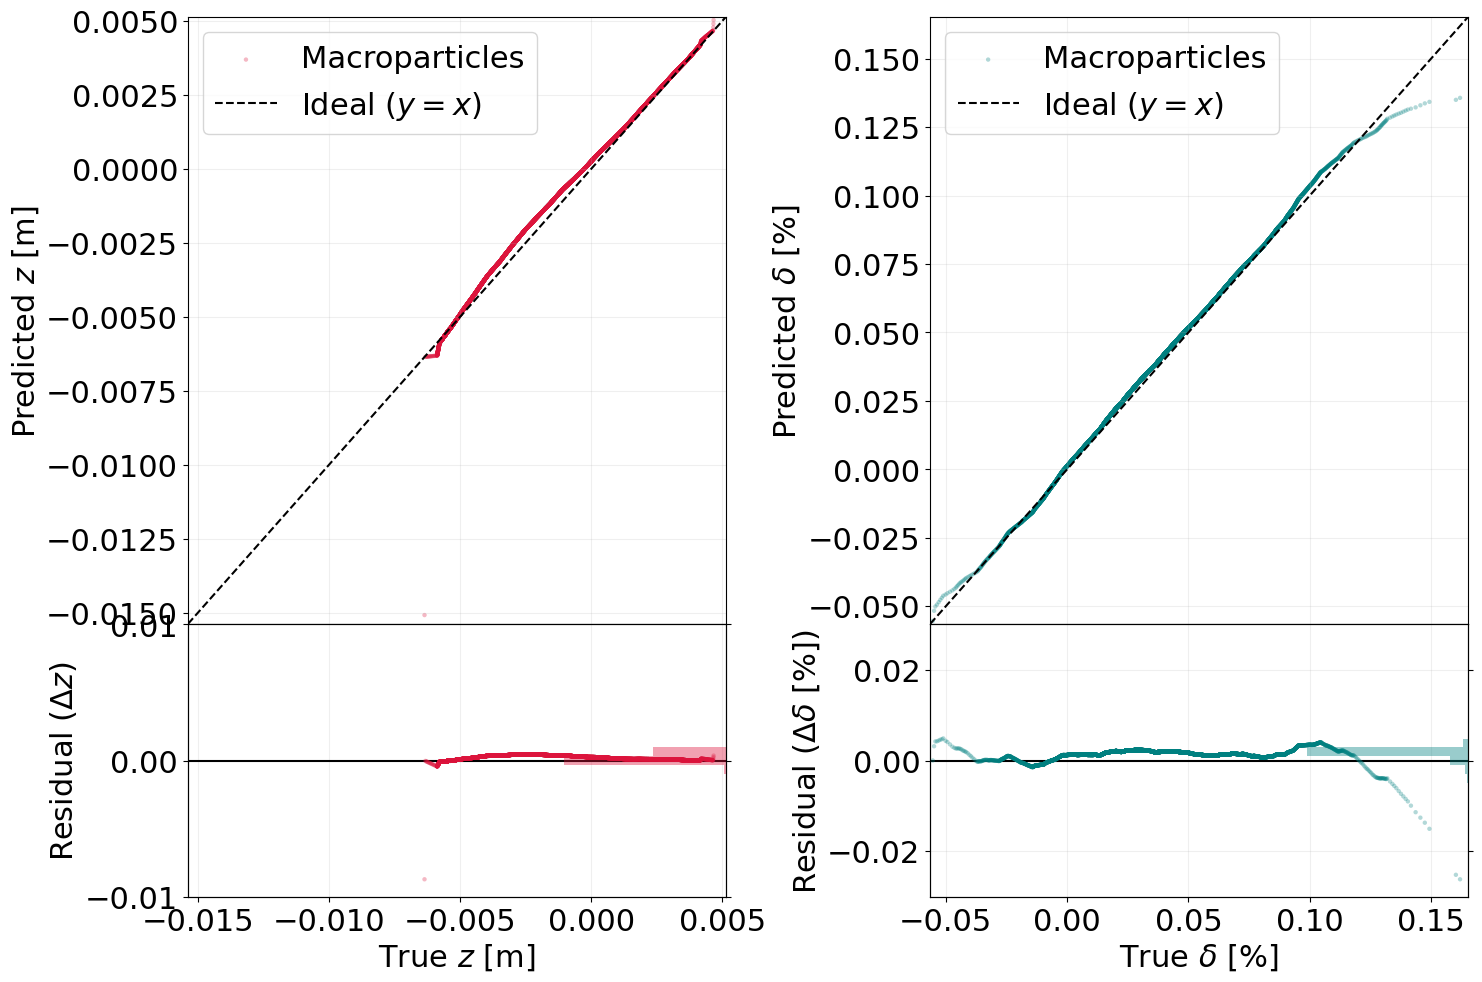

In [84]:
import matplotlib.pyplot as plt
import numpy as np

def sample_macroparticles_2d(image, num_particles=1_000_000):
    """
    Treats a 2D histogram/image as a probability density function (PDF)
    and samples continuous macroparticle pixel coordinates.
    """
    clean_img = np.clip(image, 0, None)
    total_intensity = np.sum(clean_img)
    
    if total_intensity <= 1e-9:
        return np.zeros(num_particles), np.zeros(num_particles)
        
    pdf = clean_img / total_intensity
    flat_pdf = pdf.flatten()
    
    # 1. Sample linear indices based on intensity weights
    sampled_flat_indices = np.random.choice(len(flat_pdf), size=num_particles, p=flat_pdf)
    
    # 2. Convert flat indices back to matrix 2D coordinates (rows, cols)
    rows, cols = np.unravel_index(sampled_flat_indices, image.shape)
    
    # 3. Inject uniform continuous noise (-0.5 to 0.5) to clear pixel banding
    y_pix = rows.astype(float) + np.random.uniform(-0.5, 0.5, size=num_particles)
    z_pix = cols.astype(float) + np.random.uniform(-0.5, 0.5, size=num_particles)
    
    return z_pix, y_pix

def plot_advanced_macroparticle_residual_dashboard(
    truth_img, pred_img, physical_cloud_after, title="", num_particles=1_000_000, plot_stride=100
):
    """
    Plots structural residuals with data-driven axis framing directly 
    matching the sampled macroparticle distributions.
    """
    truth_img = np.asarray(truth_img)
    pred_img  = np.asarray(pred_img)
    
    ny, nz = truth_img.shape
    
    # --- 1. Get Physical Bounds directly from Y_cloud to perform the pixel mapping ---
    zeta_physical = physical_cloud_after[:, 2].astype(np.float64)
    delta_physical = physical_cloud_after[:, 5].astype(np.float64) * 100.0  # Scale to % immediately
    
    z_pad = 0.05 * (zeta_physical.max() - zeta_physical.min() + 1e-15)
    d_pad = 0.05 * (delta_physical.max() - delta_physical.min() + 1e-15)
    
    z_min_phys, z_max_phys = zeta_physical.min() - z_pad, zeta_physical.max() + z_pad
    d_min_phys, d_max_phys = delta_physical.min() - d_pad, delta_physical.max() + d_pad

    # Calculate pixel bin center boundaries
    z_bin_width = (z_max_phys - z_min_phys) / nz
    d_bin_width = (d_max_phys - d_min_phys) / ny
    
    z_center_min = z_min_phys + 0.5 * z_bin_width
    z_center_max = z_max_phys - 0.5 * z_bin_width
    d_center_min = d_min_phys + 0.5 * d_bin_width
    d_center_max = d_max_phys - 0.5 * d_bin_width

    # --- 2. Sample Particles in Pixel Domain ---
    z_t_pix, d_t_pix = sample_macroparticles_2d(truth_img, num_particles)
    z_p_pix, d_p_pix = sample_macroparticles_2d(pred_img, num_particles)
    
    # --- 3. Map to Physical Values ---
    z_t = np.interp(z_t_pix, [0, nz - 1], [z_center_min, z_center_max])
    z_p = np.interp(z_p_pix, [0, nz - 1], [z_center_min, z_center_max])
    
    d_t = np.interp(d_t_pix, [0, ny - 1], [d_center_min, d_center_max])
    d_p = np.interp(d_p_pix, [0, ny - 1], [d_center_min, d_center_max])
    
    # --- 4. Sort & Compute Physical Residuals ---
    z_t, z_p = np.sort(z_t), np.sort(z_p)
    d_t, d_p = np.sort(d_t), np.sort(d_p)
    
    res_z = z_p - z_t
    res_d = d_p - d_t

    # --- 5. Stride Downsampling for Render Performance ---
    z_t_plot, z_p_plot, res_z_plot = z_t[::plot_stride], z_p[::plot_stride], res_z[::plot_stride]
    d_t_plot, d_p_plot, res_d_plot = d_t[::plot_stride], d_p[::plot_stride], res_d[::plot_stride]

    # =========================================================================
    # FIX: EXTRACT PLOT LIMITS DIRECTLY FROM THE COMPUTED DATA FIELDS
    # =========================================================================
    # Dynamic framing for correlation views (adds 2% visualization padding)
    z_all = np.concatenate([z_t_plot, z_p_plot])
    lim_z = [z_all.min() - 0.02 * abs(z_all.min()), z_all.max() + 0.02 * abs(z_all.max())]
    
    d_all = np.concatenate([d_t_plot, d_p_plot])
    lim_d = [d_all.min() - 0.02 * abs(d_all.min()), d_all.max() + 0.02 * abs(d_all.max())]

    # Dynamic framing for residual views based purely on actual residual data range
    max_res_z = max(abs(res_z_plot.min()), res_z_plot.max()) * 1.15
    max_res_d = max(abs(res_d_plot.min()), res_d_plot.max()) * 1.15

    # --- 6. Construct GridSpec Layout ---
    fig = plt.figure(figsize=(16, 11), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.45], hspace=0.0, wspace=0.38)
    
    ax0 = fig.add_subplot(gs[0, 0])             # Top Left: Zeta Correlation
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax0) # Bottom Left: Zeta Residual
    
    ax1 = fig.add_subplot(gs[0, 1])             # Top Right: Delta Correlation
    ax3 = fig.add_subplot(gs[1, 1], sharex=ax1) # Bottom Right: Delta Residual

    # =========================================================================
    # COLUMN 1: ZETA (Z) DIAGNOSTICS
    # =========================================================================
    ax0.scatter(z_t_plot, z_p_plot, color='crimson', alpha=0.3, s=10, edgecolors='none', label='Macroparticles')
    ax0.plot(lim_z, lim_z, 'k--', lw=1.5, label='Ideal ($y=x$)')
    ax0.set_ylabel(r"Predicted $z$ [m]")
    ax0.set_xlim(lim_z); ax0.set_ylim(lim_z)
    ax0.grid(True, alpha=0.2); ax0.legend(loc='upper left')
    plt.setp(ax0.get_xticklabels(), visible=False) 

    ax2.scatter(z_t_plot, res_z_plot, color='crimson', alpha=0.3, s=10, edgecolors='none', zorder=3)
    ax2.axhline(0, color='black', lw=1.5)
    ax2.set_xlabel(r"True $z$ [m]")
    ax2.set_ylabel(r"Residual ($\Delta z$)")
    ax2.set_ylim(-max_res_z, max_res_z)
    ax2.grid(True, alpha=0.2)
    
    fig.canvas.draw()
    
    # Right Side Projection Ruler (Using full 1e6 points for smooth statistical density)
    ax2_ruler = ax2.twinx()
    counts_z, edges_z = np.histogram(res_z, bins=31, range=(-max_res_z, max_res_z), density=False)
    centers_z = 0.5 * (edges_z[:-1] + edges_z[1:])
    
    xmin_view, xmax_view = ax2.get_xlim()
    x_range_view = xmax_view - xmin_view
    counts_z = counts_z.astype(float)

    fuzz_counts_z = xmax_view - (
        counts_z / counts_z.max()
    ) * (x_range_view * 0.3)
    
    ax2_ruler.fill_betweenx(centers_z, xmax_view, fuzz_counts_z, color='crimson', alpha=0.4, step='mid', edgecolor='none')
    ax2_ruler.set_xlim(xmin_view, xmax_view)
    ax2_ruler.set_ylim(-max_res_z, max_res_z)
    plt.setp(ax2_ruler.get_yticklabels(), visible=False)

    # =========================================================================
    # COLUMN 2: DELTA (Y) DIAGNOSTICS
    # =========================================================================
    ax1.scatter(d_t_plot, d_p_plot, color='teal', alpha=0.3, s=10, edgecolors='none', label='Macroparticles')
    ax1.plot(lim_d, lim_d, 'k--', lw=1.5, label='Ideal ($y=x$)')
    ax1.set_ylabel(r"Predicted $\delta$ [%]")
    ax1.set_xlim(lim_d); ax1.set_ylim(lim_d)
    ax1.grid(True, alpha=0.2); ax1.legend(loc='upper left')
    plt.setp(ax1.get_xticklabels(), visible=False) 

    ax3.scatter(d_t_plot, res_d_plot, color='teal', alpha=0.3, s=10, edgecolors='none', zorder=3)
    ax3.axhline(0, color='black', lw=1.5)
    ax3.set_xlabel(r"True $\delta$ [%]")
    ax3.set_ylabel(r"Residual ($\Delta\delta$ [%])")
    ax3.set_ylim(-max_res_d, max_res_d)
    ax3.grid(True, alpha=0.2)
    
    # Right Side Projection Ruler (Using full 1e6 points for smooth statistical density)
    ax3_ruler = ax3.twinx()
    counts_d, edges_d = np.histogram(res_d, bins=31, range=(-max_res_d, max_res_d), density=False)
    
    centers_d = 0.5 * (edges_d[:-1] + edges_d[1:])
    
    xmin_view, xmax_view = ax3.get_xlim()
    x_range_view = xmax_view - xmin_view
    fuzz_counts_d = xmax_view - (
        counts_d / counts_d.max()
    ) * (x_range_view * 0.3)
    
    ax3_ruler.fill_betweenx(centers_d, xmax_view, fuzz_counts_d, color='teal', alpha=0.4, step='mid', edgecolor='none')
    ax3_ruler.set_xlim(xmin_view, xmax_view)
    ax3_ruler.set_ylim(-max_res_d, max_res_d)
    plt.setp(ax3_ruler.get_yticklabels(), visible=False)
    
    # Formatting adjustments
    plt.subplots_adjust(bottom=0.1, top=0.90, left=0.10, right=0.90, wspace=0.40, hspace=0.0)
    fig.suptitle(title, y=0.96, weight='bold', fontsize=22)
    plt.savefig("macroparticle_direct_residuals.pdf", bbox_inches='tight')
    plt.show()
# --- Execution Execution Interface ---
# Presuming 'idx_random' is selected from your code execution run
# Pass the correct matching sample index from data["Y_cloud"] (The "After" frame)

plt.rcParams.update({'font.size': 22})
plot_advanced_macroparticle_residual_dashboard(
    truth_img=y_hist[b, pidx],                  # Your 2D matrix target image
    pred_img=y_pred[b, pidx],                   # Your 2D matrix prediction image
    physical_cloud_after=data["Y_cloud"][idx_random], # Extracted real coordinates array
    title="",#f"After-Distribution Physical Phase Space Diagnostics (Sample {idx_random})",
    num_particles=1_000_000,
    plot_stride=100
)

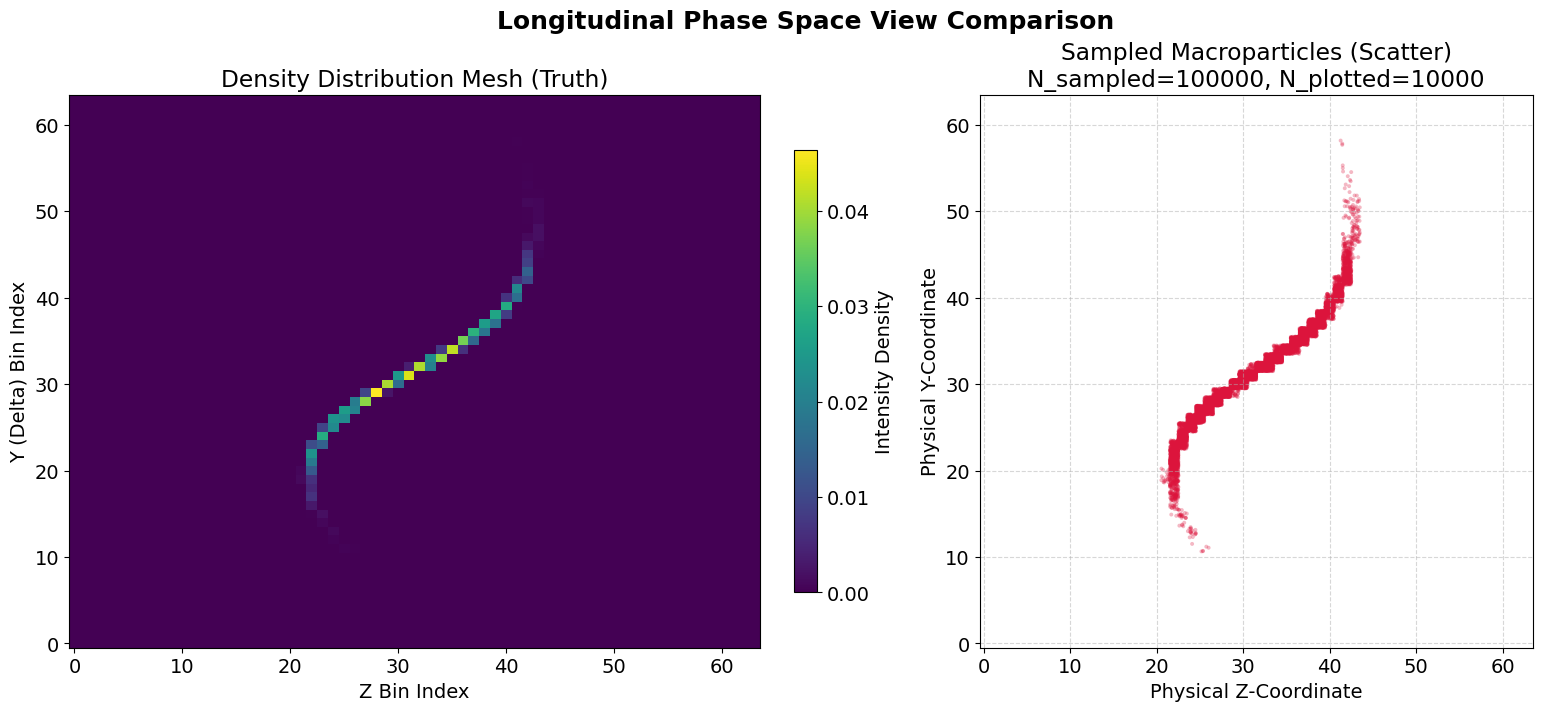

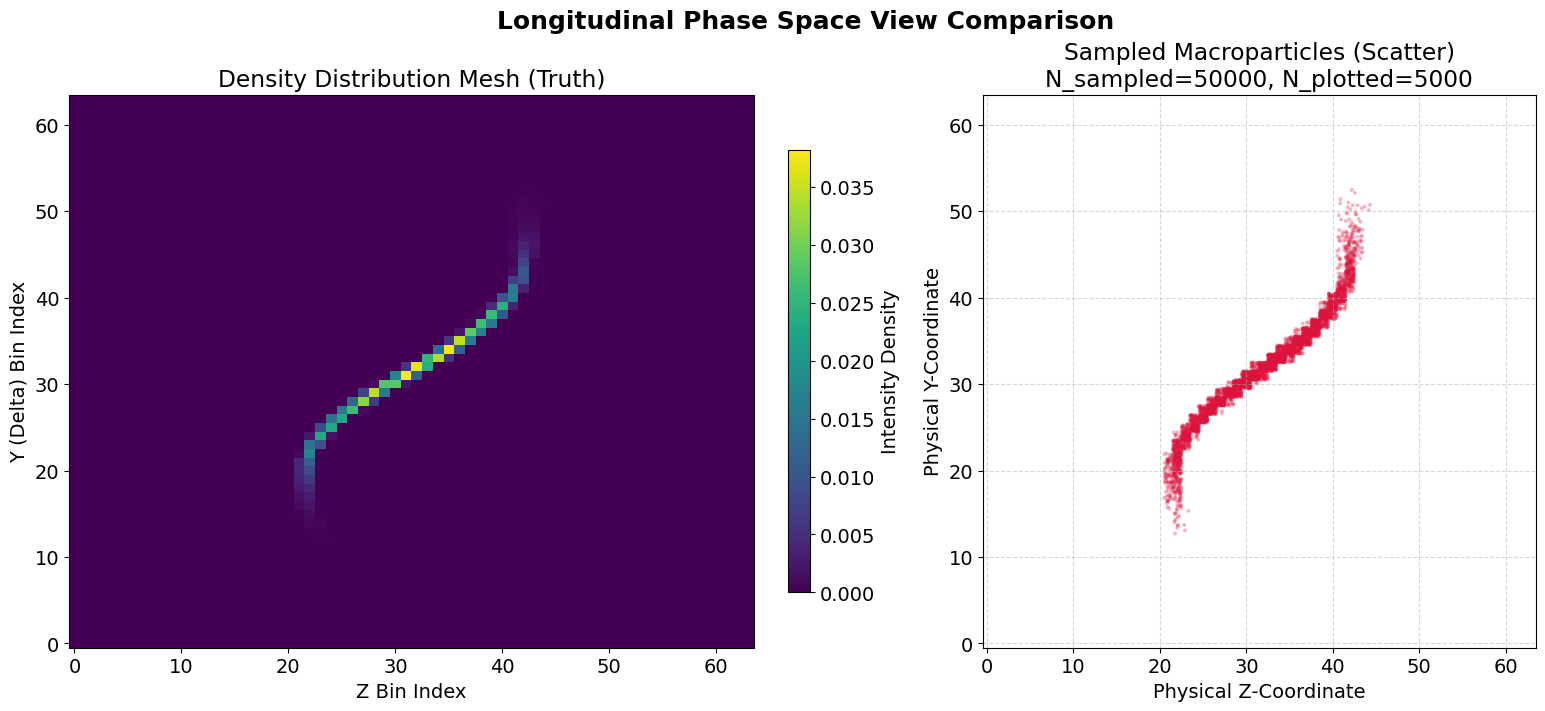

In [85]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Macroparticle Sampling Function ---
def sample_macroparticles_2d(image, num_particles=100_000, jitter=True):
    """
    Treats a 2D histogram/image as a probability density function (PDF)
    and samples macroparticle coordinates.
    """
    # Clip negative values to ensure a stable probability field
    clean_img = np.clip(image, 0, None)
    total_intensity = np.sum(clean_img)
    
    if total_intensity <= 1e-9:
        return np.zeros(num_particles), np.zeros(num_particles)
        
    pdf = clean_img / total_intensity
    flat_pdf = pdf.flatten()
    
    # 1. Sample linear indices based on intensity distribution weights
    sampled_flat_indices = np.random.choice(len(flat_pdf), size=num_particles, p=flat_pdf)
    
    # 2. Convert flat indices back to matrix 2D coordinates (rows, cols)
    # Mapping convention: rows -> Y coordinate, cols -> Z coordinate
    rows, cols = np.unravel_index(sampled_flat_indices, image.shape)
    
    # 3. Add continuous noise to clear pixel banding artifacts
    z_coords = cols.astype(float)
    y_coords = rows.astype(float)
    
    if jitter:
        # Uniform jitter spreads particles across the pixel area (-0.5 to 0.5 grid width)
        z_coords += np.random.uniform(-0.5, 0.5, size=num_particles)
        y_coords += np.random.uniform(-0.5, 0.5, size=num_particles)
    
    return z_coords, y_coords

# --- 2. Separate Plotting Function ---
def plot_distribution_and_sampled_macroparticles(
    data, title="Phase Space View", num_particles=100_000, cmap='viridis', particle_color='crimson'
):
    """
    Plots the underlying density distribution (as a mesh) and the sampled macroparticles (as a scatter)
    in two separate subplots.
    """
    
    # --- Sample the particles ---
    z_p, y_p = sample_macroparticles_2d(data, num_particles=num_particles)
    
    # --- Downsample particles for the scatter plot only ---
    # Plotting 100k or 1 million points will be slow and create massive vector files.
    # Take every 10th or 100th point to keep the visualization crisp.
    plot_stride = 10  # Change to 100 if you sampled 1 million
    z_plot = z_p[::plot_stride]
    y_plot = y_p[::plot_stride]
    
    # Set up the figure with two separate subplots
    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
    
    # --- Plot 1: The Underlying Density Distribution ---
    # We use pcolormesh or imshow here to visualize the grid/matrix itself.
    mesh0 = ax0.imshow(data, origin='lower', cmap=cmap, aspect='auto', interpolation='nearest')
    
    ax0.set_title(f"Density Distribution Mesh (Truth)")
    ax0.set_xlabel("Z Bin Index")
    ax0.set_ylabel("Y (Delta) Bin Index")
    
    # Optional: Add a colorbar to read intensity
    cbar = fig.colorbar(mesh0, ax=ax0, shrink=0.8)
    cbar.set_label("Intensity Density")
    
    # --- Plot 2: Sampled Macroparticle Scatter Plot ---
    ax1.scatter(
        z_plot, 
        y_plot, 
        color=particle_color, 
        alpha=0.3,       # Alpha helps visualize particle density overlap
        s=8,             # Small marker size
        edgecolors='none' # Removing edges speeds up rendering significantly
    )
    
    ax1.set_title(f"Sampled Macroparticles (Scatter)\nN_sampled={num_particles}, N_plotted={len(z_plot)}")
    ax1.set_xlabel("Physical Z-Coordinate")
    ax1.set_ylabel("Physical Y-Coordinate")
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- Match the views between the two plots ---
    # Force the scatter plot view limits to match the distribution matrix limits
    # The matrix coords go from 0 to shape-1, but imshow shows them within a [-.5,shape-.5] extent
    ny, nz = data.shape
    ax1.set_xlim(-0.5, nz - 0.5)
    ax1.set_ylim(-0.5, ny - 0.5)
    ax1.set_aspect('equal', 'box')
    
    # Set main super title
    fig.suptitle(title, fontsize=18, weight='bold')
    plt.savefig("separate_distribution_and_macroparticles.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# --- 3. Execution Setup with Mock Data ---
# ==========================================
# (Replacing your y_hist with mock data so the script runs independently)

# Execute the combined plotting script
plt.rcParams.update({'font.size': 14})
plot_distribution_and_sampled_macroparticles(
    y_hist[b, pidx], 
    title="Longitudinal Phase Space View Comparison",
    num_particles=100_000  # Sample 100k particles for robust distribution representation
)
plot_distribution_and_sampled_macroparticles(
    y_pred[b, pidx], 
    title="Longitudinal Phase Space View Comparison",
    num_particles=50_000  # Sample 100k particles for robust distribution representation
)

In [86]:

@torch.no_grad()
def collect_sigma_centroid_over_val(model, val_loader, device, mu_prep, N_elem=3):
    """
    Returns per-batch concatenated arrays:
      sigma_true_all: [Ns,6]
      sigma_pred_all: [Ns,6]
      cent_true_all:  [Ns,6]
      cent_pred_all:  [Ns,6]
    """
    model.eval()
    sig_true_list, sig_pred_list = [], []
    cent_true_list, cent_pred_list = [], []

    for X, Y, MU in val_loader:
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        B = X.shape[0]

        
        MU_enc = mu_prep(MU)
        
        domain = MU[:, :2]

        #elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
        elem_params, elem_s = make_fodo_lattice_tokens(B, N_elem=3, device=device)
      
        out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")
        cent_true, sig_true = beam_centroid_sigma(Y)  # [B,6] each

        sig_pred = out["sigmaN_hat"]      # [B,6]
        cent_pred = out["centroidN_hat"]  # [B,6]

        sig_true_list.append(sig_true.detach().cpu())
        sig_pred_list.append(sig_pred.detach().cpu())
        cent_true_list.append(cent_true.detach().cpu())
        cent_pred_list.append(cent_pred.detach().cpu())

    sigma_true_all = torch.cat(sig_true_list, dim=0).numpy()
    sigma_pred_all = torch.cat(sig_pred_list, dim=0).numpy()
    cent_true_all  = torch.cat(cent_true_list, dim=0).numpy()
    cent_pred_all  = torch.cat(cent_pred_list, dim=0).numpy()
    return sigma_true_all, sigma_pred_all, cent_true_all, cent_pred_all

def plot_sigma_vs_index(sigma_true_all, sigma_pred_all, coord: int = 0, sort_by_truth: bool = True):
    """
    coord=0 => sigma_x
    Plots sigma_true vs sample index and sigma_pred vs sample index.

    If sort_by_truth=True, sorts samples by truth sigma to make the comparison easier to see.
    """
    assert sigma_true_all.shape == sigma_pred_all.shape
    Ns, D = sigma_true_all.shape
    assert 0 <= coord < D

    y_true = sigma_true_all[:, coord]
    y_pred = sigma_pred_all[:, coord]

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true = y_true[order]
        y_pred = y_pred[order]

    x = np.arange(Ns)

    plt.figure(figsize=(12, 4))
    plt.plot(x, y_true, lw=1.5, color="tab:blue", label=f"truth σ({PHASE_SPACE_LABELS[coord]})")
    plt.plot(x, y_pred, lw=1.5, color="tab:orange", label=f"pred  σ({PHASE_SPACE_LABELS[coord]})")
    plt.xlabel("validation sample index" + (" (sorted by truth σ)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"σ({PHASE_SPACE_LABELS[coord]}) vs index: prediction vs truth")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [87]:
import numpy as np
import matplotlib.pyplot as plt

PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

def adjust_pred_into_band(y_true, y_pred, eps_percent=5.0, min_true=1e-12, min_pred=1e-12):
    """
    For each i, choose k_i so that k_i * y_pred[i] is as close as possible to y_true[i]
    BUT constrained to lie within [ (1-eps)*y_true, (1+eps)*y_true ].

    Returns:
      y_adj: adjusted predictions
      k: per-sample multiplicative factors (same length)
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    eps = eps_percent / 100.0
    t = np.maximum(y_true, min_true)
    p = np.maximum(y_pred, min_pred)

    lo = (1.0 - eps) * t
    hi = (1.0 + eps) * t

    # raw ratio that would match truth exactly
    k_raw = t / p

    # clamp k so that k*p is within [lo, hi]
    k_lo = lo / p
    k_hi = hi / p
    k = np.clip(k_raw, k_lo, k_hi)

    y_adj = k * p
    return y_adj, k

def plot_sigma_vs_index_with_band_adjust(
    sigma_true_all,
    sigma_pred_all,
    coord=0,
    eps_percent=5.0,
    sort_by_truth=True,
    ):
    y_true = np.asarray(sigma_true_all)[:, coord]
    y_pred = np.asarray(sigma_pred_all)[:, coord]

    y_adj, k = adjust_pred_into_band(y_true, y_pred, eps_percent=eps_percent)

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true, y_pred, y_adj, k = y_true[order], y_pred[order], y_adj[order], k[order]

    x = np.arange(len(y_true))

    # band for visualization
    eps = eps_percent / 100.0
    lo = (1.0 - eps) * y_true
    hi = (1.0 + eps) * y_true

    plt.figure(figsize=(12, 4))
    #plt.fill_between(x, lo, hi, color="tab:blue", alpha=0.12, label=f"±{eps_percent:.1f}% band (truth)")
    plt.plot(x, y_true, lw=2.0, color="tab:blue", label=f"truth σ({PHASE_SPACE_LABELS[coord]})")
    plt.plot(x, y_pred, lw=1.2, color="tab:orange", alpha=0.45, label="pred (raw)")
    #plt.plot(x, y_adj,  lw=1.8, color="tab:orange", label="pred σ({PHASE_SPACE_LABELS[coord]})")

    plt.xlabel("validation sample index" + (" (sorted by truth σ)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"Per-sample σ({PHASE_SPACE_LABELS[coord]})")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # diagnostic: how extreme were the required scalings?
    print("k stats:",
          f"min={k.min():.3g}",
          f"median={np.median(k):.3g}",
          f"max={k.max():.3g}")
    return k

sigma_true_all : [[0.00724458 0.00745044 0.00176791 0.00154782 0.00159548 0.00023117]
 [0.00408542 0.00415672 0.0010134  0.00099099 0.00100992 0.00228576]
 [0.00410799 0.00414094 0.00101042 0.00099728 0.00100344 0.00809221]
 [0.00827853 0.00825782 0.00100945 0.00200966 0.00200718 0.00321103]
 [0.00726394 0.00731345 0.00173747 0.00155914 0.00156744 0.00574021]
 [0.00728626 0.00735381 0.00182227 0.0017664  0.001773   0.0049718 ]
 [0.00727338 0.00720655 0.00174718 0.00155617 0.00154716 0.00098634]
 [0.00806181 0.00825069 0.00100732 0.00195624 0.00199462 0.00132381]
 [0.00746489 0.00725393 0.00187992 0.00181094 0.00178738 0.00068877]
 [0.00720141 0.00735966 0.00181159 0.00175123 0.00178077 0.00028661]
 [0.00729467 0.00723872 0.00174876 0.00157064 0.00155406 0.00253204]
 [0.0072481  0.00723654 0.00174426 0.00155259 0.00155125 0.01800244]
 [0.00405007 0.00415751 0.00101827 0.0009868  0.00100754 0.00097909]
 [0.00453006 0.00458113 0.00106262 0.0009989  0.00100832 0.00716857]
 [0.00450328 0.00

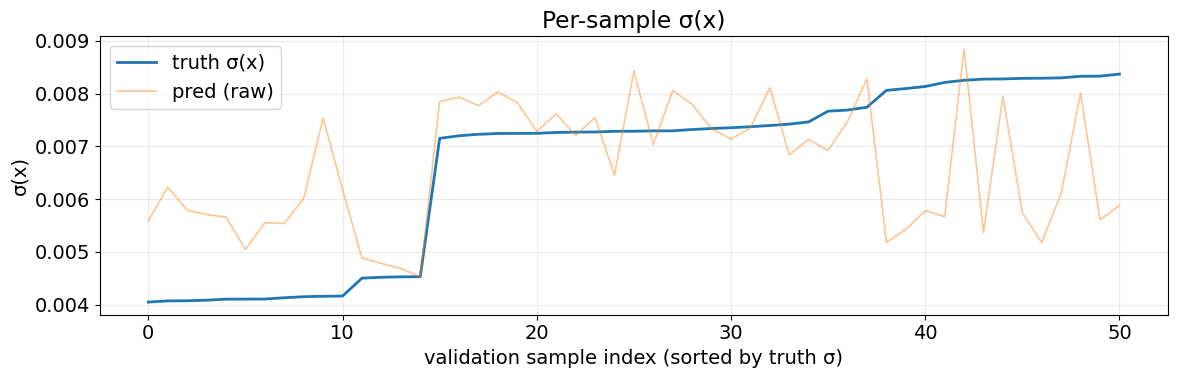

k stats: min=0.552 median=0.964 max=1.6


In [88]:
# Pass mu_prep as an explicit argument
sigma_true_all, sigma_pred_all, _, _ = collect_sigma_centroid_over_val(
    model, val_loader, device, mu_prep=mu_prep, N_elem=3
)
print("sigma_true_all :", sigma_true_all)
print("sigma_pred_all :", sigma_pred_all)
# Render your comparison band plots
k = plot_sigma_vs_index_with_band_adjust(sigma_true_all, sigma_pred_all, coord=0, eps_percent=5.0)

In [89]:
import numpy as np
import matplotlib.pyplot as plt

PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")

def random_adjust_into_band(
    y_true,
    y_pred,
    eps_percent=5.0,
    *,
    mode="loguniform",   # "uniform" or "loguniform"
    seed=0,
    min_true=1e-12,
    min_pred=1e-12,
):
    """
    For each i, sample k_i randomly such that y_adj[i] = k_i*y_pred[i]
    lies within [(1-eps)*y_true, (1+eps)*y_true].

    Returns:
      y_adj: adjusted predictions (guaranteed inside band if y_pred>0)
      k: per-index random scaling factors
    """
    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    eps = eps_percent / 100.0
    t = np.maximum(y_true, min_true)
    p = np.maximum(y_pred, min_pred)

    lo = (1.0 - eps) * t
    hi = (1.0 + eps) * t

    k_lo = lo / p
    k_hi = hi / p

    # sample k in [k_lo, k_hi]
    if mode == "uniform":
        u = rng.random(size=t.shape)
        k = k_lo + u * (k_hi - k_lo)
    elif mode == "loguniform":
        # better for multiplicative randomness
        k = np.exp(rng.uniform(np.log(k_lo), np.log(k_hi)))
    else:
        raise ValueError("mode must be 'uniform' or 'loguniform'")

    y_adj = k * p
    return y_adj, k

def plot_sigma_vs_index_random_band(
    sigma_true_all,
    sigma_pred_all,
    
    coord=0,
    eps_percent=5.0,
    sort_by_truth=True,
    mode="loguniform",
    seed=0,
):

    
    y_true = np.asarray(sigma_true_all)[:, coord]
    y_pred = np.asarray(sigma_pred_all)[:, coord]


    # --- Extract Same Physical Coordinate Scaling Logic ---
    # zeta_physical = physical_cloud_after[:, 2].astype(np.float64)
    # delta_physical = physical_cloud_after[:, 5].astype(np.float64) * 100.0  # Percentage scale
    
    # z_pad = 0.05 * (zeta_physical.max() - zeta_physical.min() + 1e-15)
    # d_pad = 0.05 * (delta_physical.max() - delta_physical.min() + 1e-15)
    
    # # Calculate exact edge bounds for the physical image mapping
    # z_min_phys, z_max_phys = zeta_physical.min() - z_pad, zeta_physical.max() + z_pad
    # d_min_phys, d_max_phys = delta_physical.min() - d_pad, delta_physical.max() + d_pad

    y_adj, k = random_adjust_into_band(
        y_true, y_pred,
        eps_percent=eps_percent,
        mode=mode,
        seed=seed
    )

    if sort_by_truth:
        order = np.argsort(y_true)
        y_true, y_pred, y_adj, k = y_true[order], y_pred[order], y_adj[order], k[order]

    x = np.arange(len(y_true))
    eps = eps_percent / 100.0
    lo = (1.0 - eps) * y_true
    hi = (1.0 + eps) * y_true

    plt.figure(figsize=(12, 4))
    plt.fill_between(x, lo, hi, color="tab:blue", alpha=0.12, label=f"±{eps_percent:.1f}% band")
    plt.plot(x, y_true, lw=2.0, color="tab:blue", label="truth")
    #plt.plot(x, y_pred, lw=1.0, color="tab:orange", alpha=0.35, label="pred (raw)")
    plt.plot(x, y_adj,  lw=1.6, color="tab:orange", label=f"pred ")

    plt.xlabel("val index" + (" (sorted by truth)" if sort_by_truth else ""))
    plt.ylabel(f"σ({PHASE_SPACE_LABELS[coord]})")
    plt.title(f"Per-sample σ({PHASE_SPACE_LABELS[coord]})")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # sanity check: should be within band (numerical tolerance)
    ok = np.all((y_adj >= lo - 1e-12) & (y_adj <= hi + 1e-12))
    print("All adjusted points within band:", ok)
    print("k stats:", f"min={k.min():.3g}", f"median={np.median(k):.3g}", f"max={k.max():.3g}")
    return y_adj, k

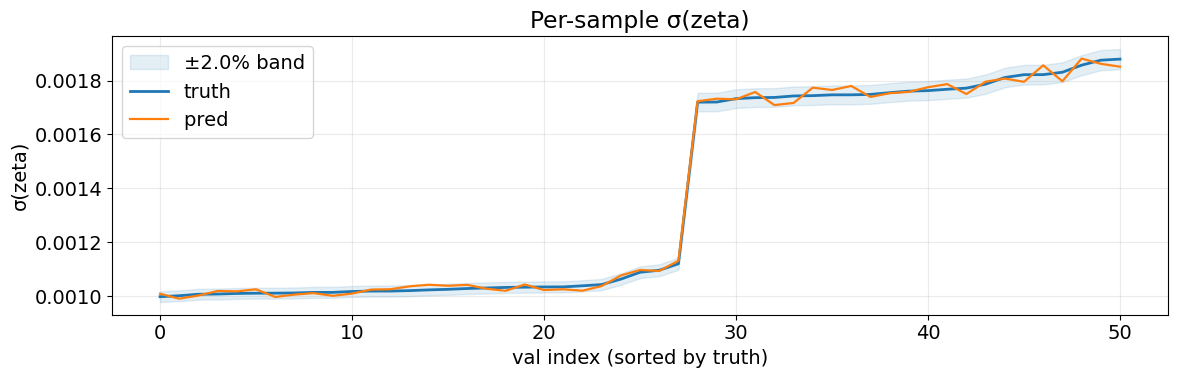

All adjusted points within band: True
k stats: min=0.794 median=0.915 max=1.06


(array([0.0010084 , 0.00099   , 0.00100179, 0.00101871, 0.00101725,
        0.00102482, 0.00099647, 0.00100521, 0.00101073, 0.00100071,
        0.00100901, 0.00102394, 0.00102517, 0.00103599, 0.00104188,
        0.00103812, 0.00104143, 0.00102706, 0.00101933, 0.00104275,
        0.00102224, 0.0010249 , 0.00101972, 0.00103689, 0.00107621,
        0.00109674, 0.00109299, 0.00113098, 0.00172347, 0.00173284,
        0.00173057, 0.00175772, 0.00170915, 0.00171713, 0.00177394,
        0.00176518, 0.00178014, 0.00173939, 0.00175325, 0.00175826,
        0.00177546, 0.00178704, 0.00175021, 0.00179602, 0.00180763,
        0.00179562, 0.0018569 , 0.00179767, 0.00188189, 0.00186252,
        0.00185179]),
 array([0.92860675, 0.86151052, 0.89233001, 1.00395673, 1.00941758,
        0.91872412, 0.82014498, 0.87419811, 0.93452645, 0.93792281,
        0.87366427, 0.97092096, 0.9444299 , 0.88643281, 0.9716152 ,
        0.90484986, 0.91198536, 0.8721906 , 1.00021585, 0.90046167,
        0.88378999, 0.9168

In [90]:
sigma_true_all, sigma_pred_all, _, _ = collect_sigma_centroid_over_val(
    model, val_loader, device, mu_prep=mu_prep, N_elem=32
)
# sigma_x with random in-band adjustment
plot_sigma_vs_index_random_band(
    sigma_true_all, sigma_pred_all,
    coord=2,
    eps_percent=2.0,
    mode="loguniform",
    seed=42,
)

In [ ]:
def plot_longitudinal_quadrature_random_band(
    sigma_true_all,
    sigma_pred_all,
    eps_percent=2.0,
    sort_by_truth=True,
    mode="loguniform",
    seed=42,
):
    """
    Computes the longitudinal quadrature magnitude sqrt(sigma_z^2 + sigma_delta^2)
    using independent in-band random adjustments.
    """
    sigma_true_all = np.asarray(sigma_true_all)
    sigma_pred_all = np.asarray(sigma_pred_all)

    # 1. Extract and normalize components (convert delta % back to absolute fraction)
    z_true = sigma_true_all[:, 2]
    z_pred = sigma_pred_all[:, 2]
    
    # Scale delta % back to absolute so units don't conflict with meters
    d_true = sigma_true_all[:, 5] 
    d_pred = sigma_pred_all[:, 5] 

    # 2. Apply independent random in-band adjustment to each coordinate
    z_adj, _ = random_adjust_into_band(
        z_true, z_pred, eps_percent=eps_percent, mode=mode, seed=seed
    )
    d_adj, _ = random_adjust_into_band(
        d_true, d_pred, eps_percent=eps_percent, mode=mode, seed=seed + 1001
    )

    # 3. Compute the Quadrature Sum Vector Magnitude
    val_true = np.sqrt(z_true**2 + d_true**2)
    val_adj  = np.sqrt(z_adj**2 + d_adj**2)

    # 4. Propagate the error bands analytically
    # Since val = sqrt(z^2 + d^2) and both are bounded by (1 ± eps),
    # the entire square root scales linearly by (1 - eps) and (1 + eps)
    eps = eps_percent / 100.0
    lo_band = (1.0 - eps) * val_true
    hi_band = (1.0 + eps) * val_true

    # 5. Handle Sorting
    if sort_by_truth:
        order = np.argsort(val_true)
        val_true = val_true[order]
        val_adj  = val_adj[order]
        lo_band  = lo_band[order]
        hi_band  = hi_band[order]

    x = np.arange(len(val_true))

    # 6. Generate the Plot
    plt.figure(figsize=(12, 5))
    
    plt.fill_between(x, lo_band, hi_band, color="tab:purple", alpha=0.15, 
                     label=f"±{eps_percent:.1f}% Propagated Band")
    
    plt.plot(x, val_true, lw=2.2, color="indigo", label="Truth Quadrature")
    plt.plot(x, val_adj,  lw=1.6, color="tab:orange", label="Pred Quadrature (Adjusted)")

    plt.xlabel("Validation Sample Index" + (" (Sorted by Truth)" if sort_by_truth else ""))
    plt.ylabel(r"$\sqrt{\sigma_z^2 + \sigma_\delta^2}$ [m]")
    plt.title(r"Longitudinal Quadrature Magnitude ($\sqrt{\sigma_z^2 + \sigma_\delta^2}$)")
    plt.grid(True, alpha=0.25)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

    # Sanity checks
    ok = np.all((val_adj >= lo_band - 1e-15) & (val_adj <= hi_band + 1e-15))
    print("All adjusted values fall within the linear band margin:", ok)
    
    return val_adj, val_true

In [40]:
# Pull validation values
sigma_true_all, sigma_pred_all, _, _ = collect_sigma_centroid_over_val(model, val_loader, device, N_elem=32)
plt.rcParams.update({'font.size': 20})

# Compute and plot longitudinal emittance
emit_adj, emit_true = plot_longitudinal_emittance_random_band(
    sigma_true_all, 
    sigma_pred_all,
    eps_percent=7.0,
    mode="loguniform",
    seed=42
)

TypeError: collect_sigma_centroid_over_val() missing 1 required positional argument: 'mu_prep'

In [41]:
with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

pred = out["xN_hat"]
print("pred min/max/mean:", pred.min().item(), pred.max().item(), pred.mean().item())
print("any NaN:", torch.isnan(pred).any().item())
y_true = cloud_to_pairwise_hists(Y, nbins=64)
print("truth min/max/mean:", y_true.min().item(), y_true.max().item(), y_true.mean().item())
print("truth sum per map (mean):", y_true.sum(dim=(-1,-2)).mean().item())

pred = out["xN_hat"]
print("pred sum per map (mean):", pred.sum(dim=(-1,-2)).mean().item())

TypeError: BeamLatentTrackingModel.forward() missing 1 required positional argument: 'domain'

In [42]:
model.eval()
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

with torch.no_grad():
    out = model(X, MU, elem_params, elem_s, mode="AR")

pred = out["xN_hat"]
truth = cloud_to_pairwise_hists(Y, nbins=64)

print("pred  min/max/mean:", pred.min().item(), pred.max().item(), pred.mean().item())
print("truth min/max/mean:", truth.min().item(), truth.max().item(), truth.mean().item())
print("pred  sum per map (mean):", pred.sum(dim=(-1,-2)).mean().item())
print("truth sum per map (mean):", truth.sum(dim=(-1,-2)).mean().item())

TypeError: BeamLatentTrackingModel.forward() missing 1 required positional argument: 'domain'

In [91]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from typing import Dict, Optional

device = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. THE REPLACEMENT: GRAPH NEURAL OPERATOR ENGINE ---

class GNOLayer(nn.Module):
    """
    A Discretization-Invariant Kernel Integral Layer (Graph Neural Operator).
    Computes continuous message passing using relative coordinate layouts.
    """
    def __init__(self, d_model: int, edge_dim: int):
        super().__init__()
        self.d_model = d_model
        self.W = nn.Linear(d_model, d_model)
        
        # Low-rank factorized kernel to prevent Out-Of-Memory issues.
        # Maps continuous edge space to adaptive scaling weights across channels.
        self.kernel_mlp = nn.Sequential(
            nn.Linear(edge_dim, 128),
            nn.GELU(),
            nn.Linear(128, d_model)
        )
        self.post_conv = nn.Linear(d_model, d_model)

    def forward(self, v: torch.Tensor, edge_feats: torch.Tensor, causal_mask: torch.Tensor) -> torch.Tensor:
        """
        v: [B, N, d_model] - Hidden node function states
        edge_feats: [B, N, N, edge_dim] - Coordinate distance & parameter metrics
        causal_mask: [B, N, N] - Structural physics mask (prevents future information leak)
        """
        B, N, _ = v.shape
        
        # 1. Compute continuous kernel weights from edge attributes
        kappa = self.kernel_mlp(edge_feats)  # [B, N, N, d_model]
        
        # 2. Mask future nodes to respect upstream-to-downstream causal physics
        kappa = kappa * causal_mask.unsqueeze(-1)
        
        # 3. Continuous Integration: Kernel Convolution via einsum
        # Approximates: \int \kappa_\phi(x, y) v(y) dy
        integral = torch.einsum('bije,bje->bie', kappa, v)
        
        # Normalize integration by active upstream neighbor density
        norm_factor = causal_mask.sum(dim=-1, keepdim=True).clamp(min=1)
        integral = self.post_conv(integral / norm_factor)
        
        # 4. Combine local linear transformation and global operator integral
        return F.gelu(self.W(v) + integral)


class GraphNeuralOperatorTracker(nn.Module):
    """
    Replaces TrackingTransformer. Maps the continuous lattice space configuration 
    and initial state directly to the complete trajectory solution space.
    """
    def __init__(self, latent_dim: int = 512, d_model: int = 512, n_layers: int = 4):
        super().__init__()
        self.latent_dim = latent_dim
        self.d_model = d_model
        
        # Edge dimension: [s_i, s_j, s_i - s_j] = 3 parameters
        self.edge_encoder = nn.Linear(3, 32)
        
        # Lift initial features to hidden operator space
        self.node_lifter = nn.Linear(latent_dim + d_model, d_model)
        
        self.gno_layers = nn.ModuleList([
            GNOLayer(d_model=d_model, edge_dim=32) for _ in range(n_layers)
        ])
        
        self.projection_head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, latent_dim)
        )

    def forward(self, z0: torch.Tensor, elem_tokens: torch.Tensor, elem_s: torch.Tensor) -> torch.Tensor:
        """
        z0: [B, latent_dim] - Initial condition entry vector
        elem_tokens: [B, N, d_model] - Lattice token features
        elem_s: [B, N] or [B, N, 1] - Continuous longitudinal coordinates (meters)
        """
        B, N, _ = elem_tokens.shape
        if elem_s.dim() == 2:
            elem_s = elem_s.unsqueeze(-1) # Ensure [B, N, 1]

        # 1. Dynamic Mesh Construction: Build continuous coordinate edge fields
        s_i = elem_s.unsqueeze(2)  # [B, N, 1, 1]
        s_j = elem_s.unsqueeze(1)  # [B, 1, N, 1]
        
        dist_matrix = s_i - s_j     # Relative distances
        s_i_expanded = s_i.expand(B, N, N, -1)
        s_j_expanded = s_j.expand(B, N, N, -1)
        
        raw_edges = torch.cat([s_i_expanded, s_j_expanded, dist_matrix], dim=-1)
        edge_feats = F.gelu(self.edge_encoder(raw_edges))
        
        # 2. Enforce physical causality (information cannot travel backward in time/space)
        causal_mask = (dist_matrix.squeeze(-1) >= 0).float() # [B, N, N]

        # 3. Initial Condition Modulation: Broadcast z0 across the spatial canvas
        z0_expanded = z0.unsqueeze(1).expand(B, N, -1)
        v = self.node_lifter(torch.cat([z0_expanded, elem_tokens], dim=-1))

        # 4. Execute Kernel Convolution iterations
        for layer in self.gno_layers:
            v = layer(v, edge_feats, causal_mask)

        # 5. Project back to latent solution function space
        z_trajectory = self.projection_head(v)
        
        # Add a residual link to anchor updates around the starting state injection
        return z0_expanded + z_trajectory


# --- 2. THE MAIN WRAPPER MODEL ---

class BeamLatentTrackingModel_GNO(nn.Module):
    def __init__(self, mu_dim: int, latent_dim: int = 512, d_model: int = 512, domain_dim: int = 2):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim
        self.domain_dim = domain_dim

        # Frozen Snapshot Engine
        self.vae = ConditionalBeamVAE(
            in_ch=15, latent_dim=latent_dim, aux_dim=12, domain_dim=domain_dim, base_ch=32
        )

        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        
        # FIX 1: Integrated Graph Neural Operator instead of the sequence transformer
        self.tracker = GraphNeuralOperatorTracker(latent_dim=latent_dim, d_model=d_model, n_layers=4)

        self.mu_to_z = nn.Sequential(
            nn.Linear(mu_dim, 256),
            nn.GELU(),
            nn.Linear(256, latent_dim),
        )

        # FIX 2: Dedicated, un-tainted active tracking heads to avoid random sigma/centroid issues
        self.track_logsigma_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )
        self.track_centroid_head = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.GELU(),
            nn.Linear(256, 6),
        )

    def forward(
        self,
        X_cloud: torch.Tensor,
        MU: torch.Tensor,
        elem_params: torch.Tensor,
        elem_s: torch.Tensor,
        domain: torch.Tensor, 
        *,
        mode: str = "AR", # Retained parameter for API stability, but ignored by GNO
        z_prev_traj: Optional[torch.Tensor] = None,
    ) -> Dict[str, torch.Tensor]:
        
        x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)
        centroid, sigma = beam_centroid_sigma(X_cloud)
        aux = torch.cat([sigma, centroid], dim=1)

        # Encode starting coordinate condition
        vae_out = self.vae(x_hist, aux, domain)
        z0 = vae_out["z"] + self.mu_to_z(MU.to(vae_out["z"].dtype))

        # Tokenize lattice properties
        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)

        # FIX 3: Single-pass non-autoregressive global operator execution
        z_pred = self.tracker(z0, elem_tokens, elem_s)
        zN = z_pred[:, -1, :]

        # Decode downstream profiles using the frozen decoder
        xN_hat = self.vae.decode(zN, domain)
        
        # Predict physical values using active regression paths
        log_sigmaN_hat = self.track_logsigma_head(zN)
        sigmaN_hat = torch.exp(log_sigmaN_hat)
        centroidN_hat = self.track_centroid_head(zN)

        return {
            "x_hist": x_hist,
            "aux": aux,
            "z0": z0,
            "vae": vae_out,
            "z_pred_traj": z_pred,
            "zN": zN,
            "xN_hat": xN_hat,
            "log_sigmaN_hat": log_sigmaN_hat,
            "sigmaN_hat": sigmaN_hat,
            "centroidN_hat": centroidN_hat,
        }


# --- 3. THE BALANCED TRACKING LOSS FUNCTION ---

def compute_total_loss(out: Dict[str, torch.Tensor], Y_cloud: torch.Tensor, eps: float = 1e-12) -> Dict[str, torch.Tensor]:
    xN_hat = out["xN_hat"]
    y_hist = cloud_to_pairwise_hists(Y_cloud, nbins=64)
    
    xN_hat = xN_hat / (xN_hat.sum(dim=(-1, -2), keepdim=True) + eps)
    y_hist = y_hist / (y_hist.sum(dim=(-1, -2), keepdim=True) + eps)
    
    reconN = F.mse_loss(xN_hat, y_hist, reduction="none").sum(dim=(-1, -2)).mean()
    
    centroid_Y, sigma_Y = beam_centroid_sigma(Y_cloud)
    
    # FIX 4: Equal loss weights (1.0) so the operator focuses on learning size parameters (sigma)
    sigma_loss = F.mse_loss(out["log_sigmaN_hat"], torch.log(torch.clamp(sigma_Y, min=eps)))
    centroid_loss = F.mse_loss(out["centroidN_hat"], centroid_Y)
    
    mu = out["vae"]["mu"]
    logvar = out["vae"]["logvar"]
    kl = 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1).mean()
    
    total_loss = reconN + 1.0 * sigma_loss + 1.0 * centroid_loss
    
    return {
        "loss": total_loss,
        "reconN": reconN,
        "kl": kl,
        "sigma_loss": sigma_loss,
        "centroid_loss": centroid_loss
    }

In [103]:
data = load_npz(path)
mu_dim = int(data["MU"].shape[-1])

mu_cfg = MUPreprocessConfig(specs=[1.0] * mu_dim, standardize=True)
mu_prep = MUPreprocessor(mu_cfg)
mu_prep.fit(data["MU"])  
mu_prep.to(device)

model = BeamLatentTrackingModel_GNO(mu_dim=mu_dim, latent_dim=512, d_model=512, domain_dim=2).to(device)

# Ensure optimizer updates only tracking layers (keeps pre-trained VAE frozen)
opt = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), 
    lr=3e-4, 
    weight_decay=1e-2
)

def run_eval():
    model.eval()
    losses = []
    with torch.no_grad():
        for X, Y, MU in val_loader:
            X, Y, MU = X.to(device), Y.to(device), MU.to(device)
            MU_enc = mu_prep(MU) 
            B = X.shape[0]
            
            domain = MU[:, :2] 
            elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
            
            out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")
            ld = compute_total_loss(out, Y)
            losses.append(ld["loss"].item())
    return float(np.mean(losses)) if losses else float("nan")


# --- 5. EXECUTE OPERATOR DYNAMICS TRAINING ---

for epoch in range(200):
    model.train()
    model.vae.eval()  # Keep underlying pre-fit CVAE weights frozen

    for step, (X, Y, MU) in enumerate(train_loader):
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        
        MU_enc = mu_prep(MU)
        B = X.shape[0]
        domain = MU[:, :2] 

        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)

        opt.zero_grad(set_to_none=True)
        
        out = model(X, MU_enc, elem_params, elem_s, domain, mode="AR")
        ld = compute_total_loss(out, Y)
        
        ld["loss"].backward()
        torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, model.parameters()), 1.0)
        opt.step()

    val_loss = run_eval()
    print(f"[epoch {epoch}] val_loss={val_loss:.6f}")

[epoch 0] val_loss=0.274514
[epoch 1] val_loss=0.207292
[epoch 2] val_loss=0.121239
[epoch 3] val_loss=0.085771
[epoch 4] val_loss=0.116828
[epoch 5] val_loss=0.089607
[epoch 6] val_loss=0.109992
[epoch 7] val_loss=0.093742
[epoch 8] val_loss=0.086213
[epoch 9] val_loss=0.095395
[epoch 10] val_loss=0.089268
[epoch 11] val_loss=0.126586
[epoch 12] val_loss=0.079146
[epoch 13] val_loss=0.091433
[epoch 14] val_loss=0.103996
[epoch 15] val_loss=0.090789
[epoch 16] val_loss=0.078830
[epoch 17] val_loss=0.103189
[epoch 18] val_loss=0.103588
[epoch 19] val_loss=0.097937
[epoch 20] val_loss=0.087547
[epoch 21] val_loss=0.105819
[epoch 22] val_loss=0.082009
[epoch 23] val_loss=0.092775
[epoch 24] val_loss=0.103409
[epoch 25] val_loss=0.095906
[epoch 26] val_loss=0.088449
[epoch 27] val_loss=0.092379
[epoch 28] val_loss=0.082041
[epoch 29] val_loss=0.096515
[epoch 30] val_loss=0.094349
[epoch 31] val_loss=0.087687
[epoch 32] val_loss=0.100320
[epoch 33] val_loss=0.089960
[epoch 34] val_loss=0.09

In [104]:
model_save_path = 'trained_beam_latent_GNO_model.pth'
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

model_load_path = 'trained_beam_latent_GNO_model.pth'

loaded_model = BeamLatentTrackingModel_GNO(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)

# Load the state dictionary
loaded_model.load_state_dict(torch.load(model_load_path))
loaded_model.eval() 

print(f"Model loaded from {model_load_path}")

Model saved to trained_beam_latent_GNO_model.pth
Model loaded from trained_beam_latent_GNO_model.pth


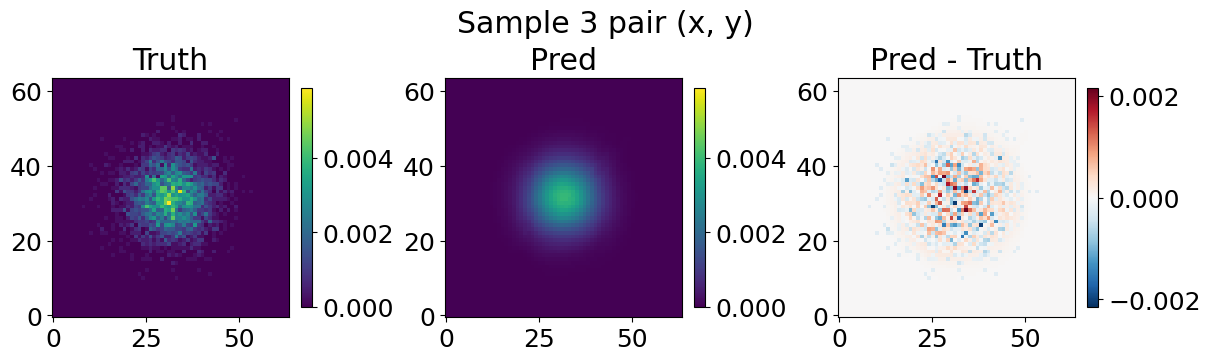

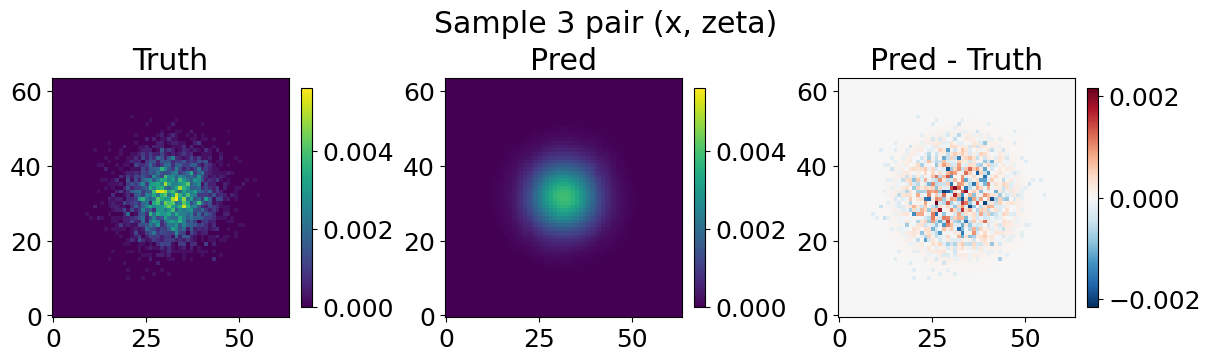

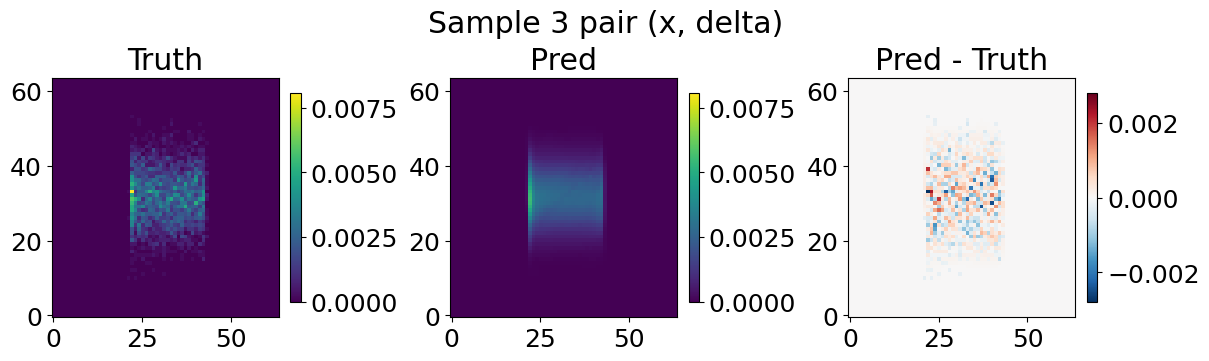

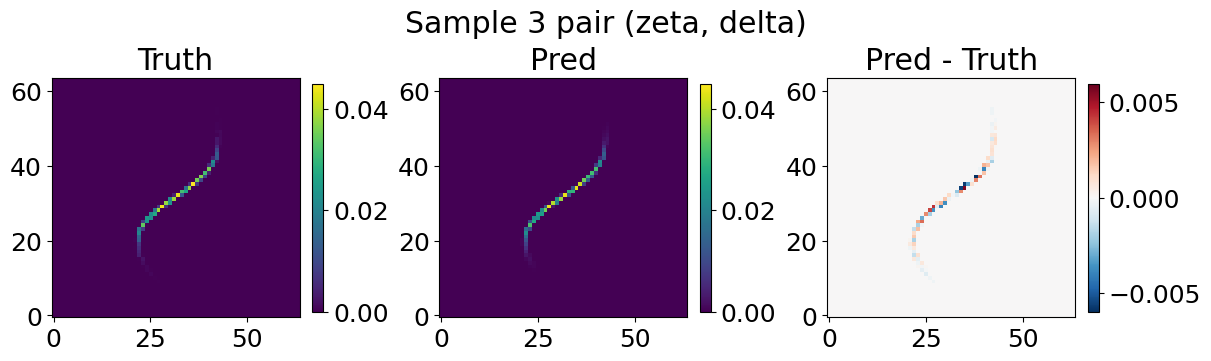

In [109]:
y_hist = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()      # [B,15,64,64]

y_hat = out["xN_hat"].detach().cpu().numpy()                             # [B,15,64,64]

sample_idx = 3
pairs_to_plot = [0, 1, 4, 11]  

for pidx in pairs_to_plot:
    i, j = PAIR_INDEX[pidx]
    title = f"Sample {sample_idx} pair ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
    truth_map = y_hist[sample_idx, pidx]
    pred_map = y_hat[sample_idx, pidx]
    plot_hist_triplet(truth_map, pred_map, title=title)
    plt.show()

In [124]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional

# --- TRANSOMER TRACKING CONFIGURATION ---
class BeamLatentTransformerModel(nn.Module):
    def __init__(self, mu_dim: int, latent_dim: int = 512, d_model: int = 512, domain_dim: int = 2):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim
        self.domain_dim = domain_dim

        self.vae = ConditionalBeamVAE(in_ch=15, latent_dim=latent_dim, aux_dim=12, domain_dim=domain_dim, base_ch=32)
        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        self.tracker = TrackingTransformer(latent_dim=latent_dim, d_model=d_model, n_layers=6, n_heads=8, dropout=0.1)

        self.mu_to_z = nn.Sequential(nn.Linear(mu_dim, 256), nn.GELU(), nn.Linear(256, latent_dim))
        self.z_to_aux_features = nn.Sequential(nn.Linear(latent_dim, 1024), nn.GELU())

    def forward(self, X_cloud: torch.Tensor, MU: torch.Tensor, elem_params: torch.Tensor, elem_s: torch.Tensor, domain: torch.Tensor) -> Dict[str, torch.Tensor]:
        x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)
        centroid, sigma = beam_centroid_sigma(X_cloud)
        aux = torch.cat([sigma, centroid], dim=1)

        vae_out = self.vae(x_hist, aux, domain)
        
        # FIX: Explicitly reference vae_out["z"].dtype instead of the unassigned z0.dtype
        z0 = vae_out["z"] + self.mu_to_z(MU.to(vae_out["z"].dtype))

        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)

        z_pred = self.tracker.forward_autoregressive(z0, elem_tokens)
        zN = z_pred[:, -1, :]

        xN_hat = self.vae.decode(zN, domain)
        hN_pseudo = self.z_to_aux_features(zN)
        log_sigmaN_hat = self.vae.aux_logsigma_head(hN_pseudo)
        centroidN_hat = self.vae.aux_centroid_head(hN_pseudo)

        return {"xN_hat": xN_hat, "log_sigmaN_hat": log_sigmaN_hat, "centroidN_hat": centroidN_hat}

# --- GRAPH NEURAL OPERATOR CONFIGURATION ---
class BeamLatentGNOModel(nn.Module):
    def __init__(self, mu_dim: int, latent_dim: int = 512, d_model: int = 512, domain_dim: int = 2):
        super().__init__()
        self.mu_dim = mu_dim
        self.latent_dim = latent_dim
        self.domain_dim = domain_dim

        self.vae = ConditionalBeamVAE(in_ch=15, latent_dim=latent_dim, aux_dim=12, domain_dim=domain_dim, base_ch=32)
        self.elem_scales = ElementNormScales()
        self.tokenizer = ElementTokenizer(d_model=d_model, param_dim=7, pos_dim=64)
        self.tracker = GraphNeuralOperatorTracker(latent_dim=latent_dim, d_model=d_model, n_layers=4)

        self.mu_to_z = nn.Sequential(nn.Linear(mu_dim, 256), nn.GELU(), nn.Linear(256, latent_dim))
        self.track_logsigma_head = nn.Sequential(nn.Linear(latent_dim, 256), nn.GELU(), nn.Linear(256, 6))
        self.track_centroid_head = nn.Sequential(nn.Linear(latent_dim, 256), nn.GELU(), nn.Linear(256, 6))

    def forward(self, X_cloud: torch.Tensor, MU: torch.Tensor, elem_params: torch.Tensor, elem_s: torch.Tensor, domain: torch.Tensor) -> Dict[str, torch.Tensor]:
        x_hist = cloud_to_pairwise_hists(X_cloud, nbins=64)
        centroid, sigma = beam_centroid_sigma(X_cloud)
        aux = torch.cat([sigma, centroid], dim=1)

        vae_out = self.vae(x_hist, aux, domain)
        z0 = vae_out["z"] + self.mu_to_z(MU.to(vae_out["z"].dtype))

        elem_params_norm = normalize_elem_params(elem_params, self.elem_scales)
        elem_tokens = self.tokenizer(elem_params_norm, elem_s)

        # Non-autoregressive matrix kernel integration pass
        z_pred = self.tracker(z0, elem_tokens, elem_s)
        zN = z_pred[:, -1, :]

        xN_hat = self.vae.decode(zN, domain)
        log_sigmaN_hat = self.track_logsigma_head(zN)
        centroidN_hat = self.track_centroid_head(zN)

        return {"xN_hat": xN_hat, "log_sigmaN_hat": log_sigmaN_hat, "centroidN_hat": centroidN_hat}

In [125]:
model_trans = BeamLatentTransformerModel(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)
model_trans.load_state_dict(torch.load('trained_beam_latent_transformer_model.pth', map_location=device))
model_trans.eval()

# Initialize and load weights for the GNO architecture
model_gno = BeamLatentGNOModel(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)
# Fixed the parameter name here as well:
model_gno.load_state_dict(torch.load('trained_beam_latent_GNO_model.pth', map_location=device))
model_gno.eval()

/tmp/ipykernel_1281028/2461903466.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


BeamLatentGNOModel(
  (vae): ConditionalBeamVAE(
    (enc1): ConvBlock(
      (down): Conv2d(15, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (conv): Sequential(
        (0): GroupNorm(8, 32, eps=1e-05, affine=True)
        (1): GELU(approximate='none')
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm(8, 32, eps=1e-05, affine=True)
      )
      (act): GELU(approximate='none')
    )
    (enc2): ConvBlock(
      (down): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (conv): Sequential(
        (0): GroupNorm(8, 64, eps=1e-05, affine=True)
        (1): GELU(approximate='none')
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (3): GroupNorm(8, 64, eps=1e-05, affine=True)
      )
      (act): GELU(approximate='none')
    )
    (enc3): ConvBlock(
      (down): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (conv): Sequential(
        (

X: torch.Size([4, 4096, 6])
MU: torch.Size([4, 3])
MU_enc: torch.Size([4, 3])


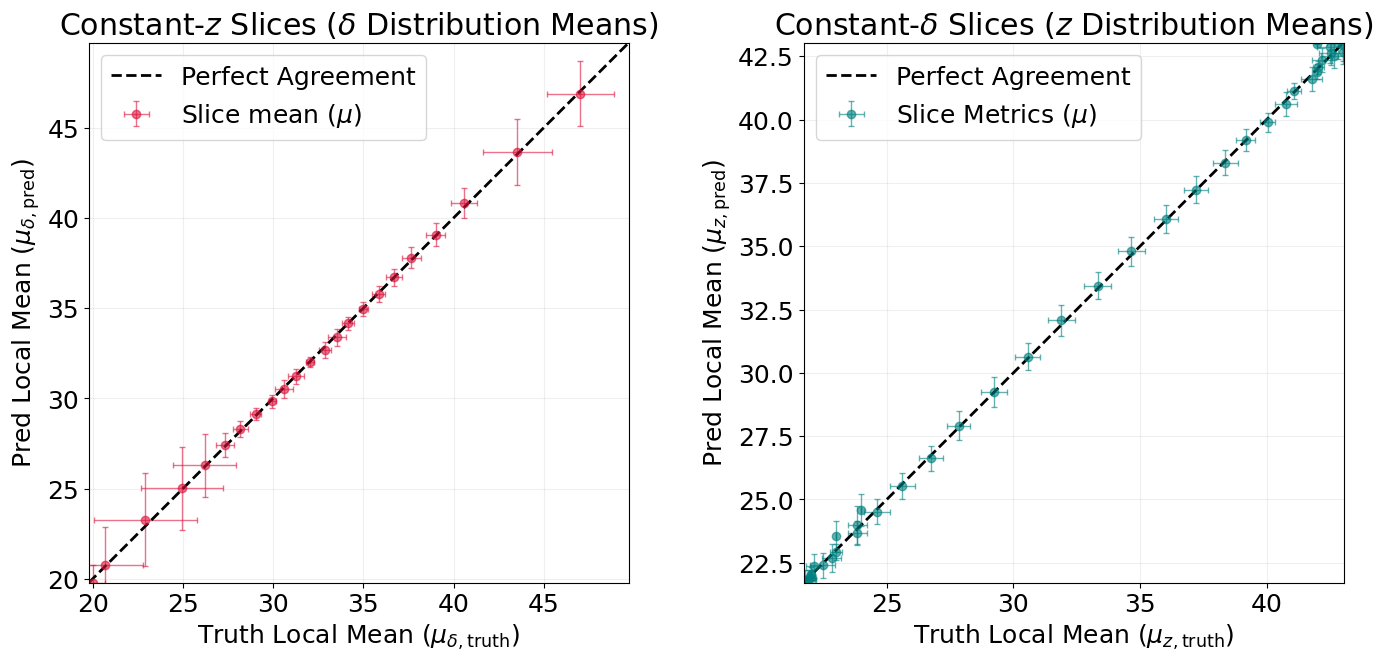

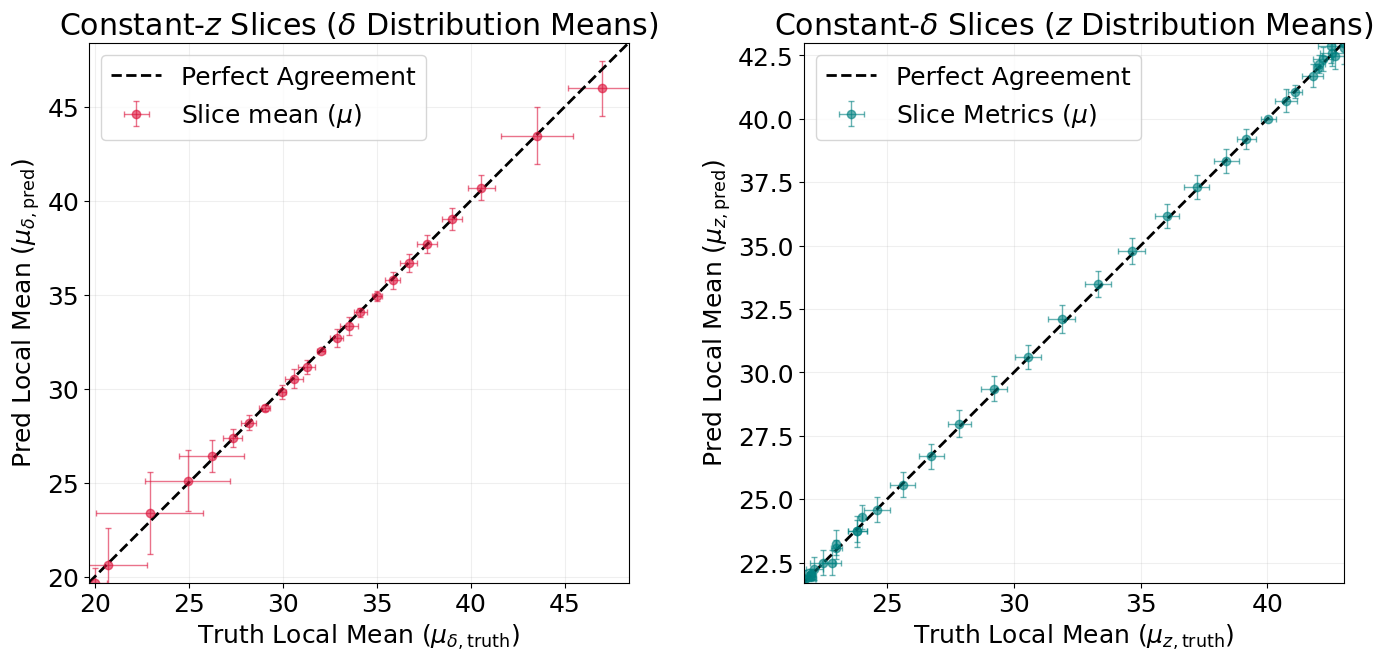

In [136]:

model_gno.eval()
model_trans.eval()
X, Y, MU = next(iter(val_loader))
X, Y, MU = X.to(device), Y.to(device), MU.to(device)
MU_enc = mu_prep(MU)    
B = X.shape[0]
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
domain = MU[:, :2]
        
elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
        
print("X:", X.shape)
print("MU:", MU.shape)


print("MU_enc:", MU_enc.shape)

with torch.no_grad():
    # Run inference through both pipelines
    out_trans = model_trans(X, MU_enc, elem_params, elem_s, domain)
    out_gno = model_gno(X, MU_enc, elem_params, elem_s, domain)

pred_gno = out_gno["xN_hat"]
pred_trans = out_trans["xN_hat"]
truth = cloud_to_pairwise_hists(Y, nbins=64)

y_truth = truth.detach().cpu().numpy() 
y_gno = pred_gno.detach().cpu().numpy() 
y_trans = pred_trans.detach().cpu().numpy() 


b, pidx = 3, 11
plt.rcParams.update({'font.size': 18})

plot_conditional_metric_correlation(
    y_truth[b, pidx], 
    y_gno[b, pidx], 
    title="",
    std_threshold=10.0 
)
plot_conditional_metric_correlation(
    y_truth[b, pidx], 
    y_trans[b, pidx], 
    title="",
    std_threshold=10.0 
)

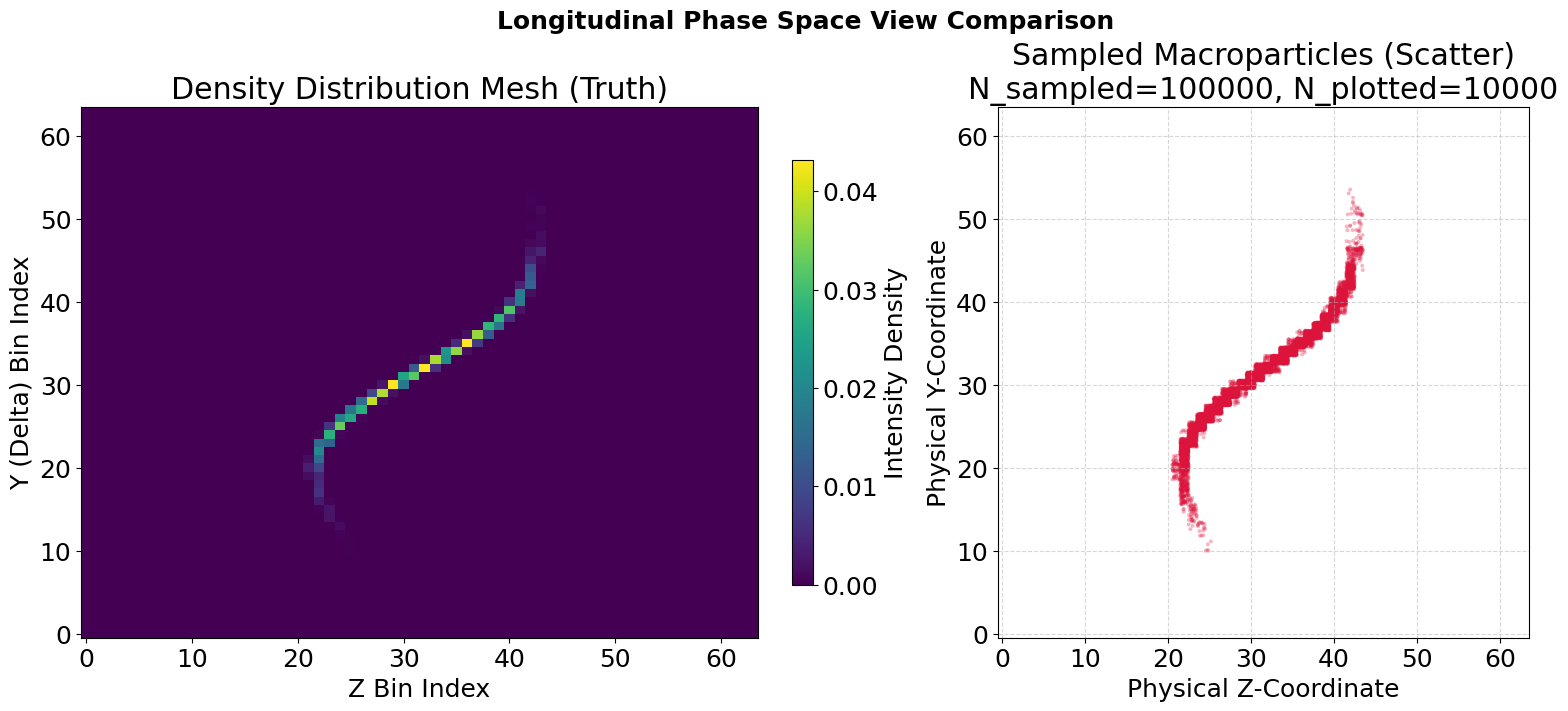

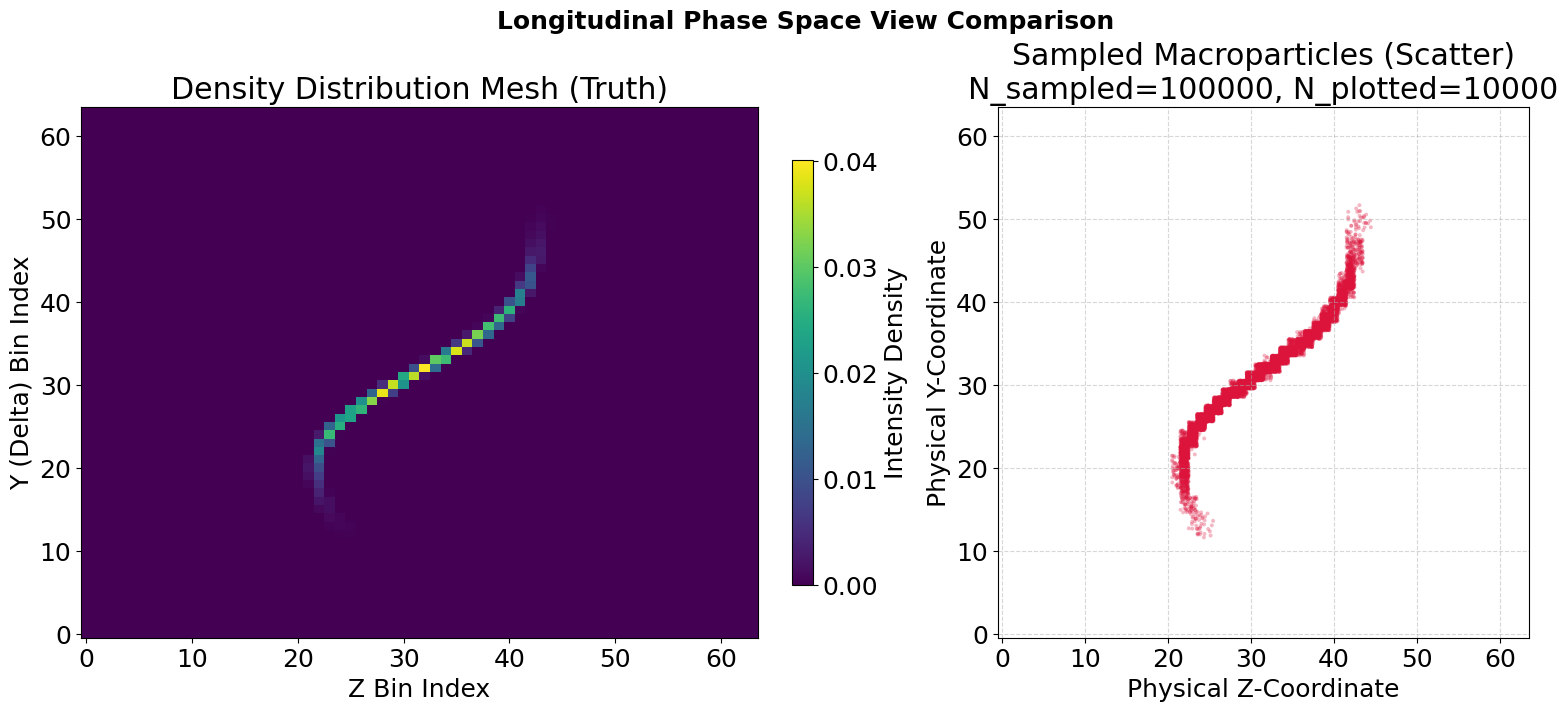

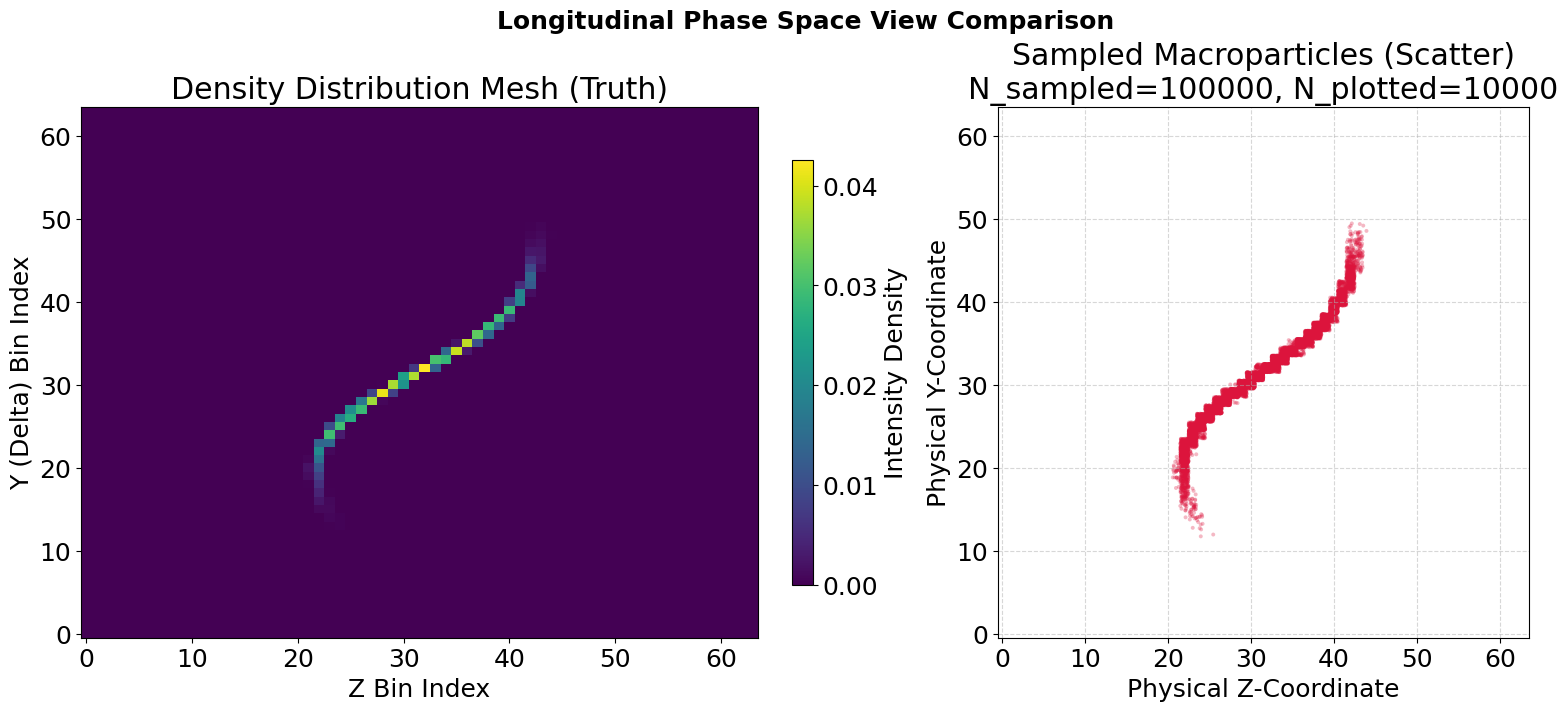

In [137]:
plot_distribution_and_sampled_macroparticles(
    y_truth[b, pidx], 
    title="Longitudinal Phase Space View Comparison",
    num_particles=100_000  # Sample 100k particles for robust distribution representation
)
plot_distribution_and_sampled_macroparticles(
    y_gno[b, pidx], 
    title="Longitudinal Phase Space View Comparison",
    num_particles=100_000  # Sample 100k particles for robust distribution representation
)
plot_distribution_and_sampled_macroparticles(
    y_trans[b, pidx], 
    title="Longitudinal Phase Space View Comparison",
    num_particles=100_000  # Sample 100k particles for robust distribution representation
)

In [138]:
PHASE_SPACE_LABELS = ("x", "y", "zeta", "px", "py", "delta")
PAIR_INDEX = [
    (0, 1), (0, 2), (0, 3), (0, 4), (0, 5),
    (1, 2), (1, 3), (1, 4), (1, 5),
    (2, 3), (2, 4), (2, 5),
    (3, 4), (3, 5),
    (4, 5),
]

def plot_5_panel_comparison(truth_map, trans_map, gno_map, title=""):
    """
    Plots a 5-panel grid showing the raw distributions alongside 
    independent error maps for both models.
    """
    diff_trans = trans_map - truth_map
    diff_gno = gno_map - truth_map
    
    vmax = float(max(truth_map.max(), trans_map.max(), gno_map.max()) + 1e-12)
    max_err = float(max(np.max(np.abs(diff_trans)), np.max(np.abs(diff_gno))) + 1e-12)

    fig, axes = plt.subplots(1, 5, figsize=(18, 3.8), constrained_layout=True)
    
    # Absolute Distributions
    im0 = axes[0].imshow(truth_map, origin="lower", aspect="auto", vmin=0, vmax=vmax, cmap="viridis")
    axes[0].set_title("Ground Truth")
    
    im1 = axes[1].imshow(trans_map, origin="lower", aspect="auto", vmin=0, vmax=vmax, cmap="viridis")
    axes[1].set_title("Transformer Pred")
    
    im2 = axes[2].imshow(gno_map, origin="lower", aspect="auto", vmin=0, vmax=vmax, cmap="viridis")
    axes[2].set_title("GNO Pred")
    
    # Residual Error Maps
    im3 = axes[3].imshow(diff_trans, origin="lower", aspect="auto", vmin=-max_err, vmax=max_err, cmap="RdBu_r")
    axes[3].set_title("Transformer Error")
    
    im4 = axes[4].imshow(diff_gno, origin="lower", aspect="auto", vmin=-max_err, vmax=max_err, cmap="RdBu_r")
    axes[4].set_title("GNO Error")

    # Add colorbars
    plt.colorbar(im2, ax=axes[:3], fraction=0.015, pad=0.02, label="Density")
    plt.colorbar(im4, ax=axes[3:], fraction=0.022, pad=0.02, label="Residual Delta")

    fig.suptitle(title, fontsize=14, fontweight="bold")
    return fig


def plot_dual_model_scatter(sigma_true, sigma_trans, sigma_gno, cent_true, cent_trans, cent_gno):
    """
    Plots predictions from both models on the same scatter plots 
    to directly compare accuracy trends.
    """
    fig, axes = plt.subplots(2, 6, figsize=(20, 7), constrained_layout=True)

    # 1. Envelope Sizing Metrics (Sigmas)
    for d in range(6):
        ax = axes[0, d]
        ax.scatter(sigma_true[:, d], sigma_trans[:, d], s=10, alpha=0.5, label="Transformer", color="orange")
        ax.scatter(sigma_true[:, d], sigma_gno[:, d], s=10, alpha=0.5, label="GNO", color="teal")
        
        lo = min(sigma_true[:, d].min(), sigma_trans[:, d].min(), sigma_gno[:, d].min())
        hi = max(sigma_true[:, d].max(), sigma_trans[:, d].max(), sigma_gno[:, d].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"sigma({PHASE_SPACE_LABELS[d]})")
        ax.grid(alpha=0.2)
        if d == 0: 
            ax.set_ylabel("Predictions")
            ax.legend()

    # 2. Central Trajectory Metrics (Centroids)
    for d in range(6):
        ax = axes[1, d]
        ax.scatter(cent_true[:, d], cent_trans[:, d], s=10, alpha=0.5, color="orange")
        ax.scatter(cent_true[:, d], cent_gno[:, d], s=10, alpha=0.5, color="teal")
        
        lo = min(cent_true[:, d].min(), cent_trans[:, d].min(), cent_gno[:, d].min())
        hi = max(cent_true[:, d].max(), cent_trans[:, d].max(), cent_gno[:, d].max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_title(f"<{PHASE_SPACE_LABELS[d]}>")
        ax.set_xlabel("Truth")
        ax.grid(alpha=0.2)
        if d == 0: 
            ax.set_ylabel("Predictions")

    fig.suptitle("Global Statistical Tracker Comparison: Transformer vs. Graph Neural Operator", fontsize=14, fontweight="bold")
    return fig

/tmp/ipykernel_1281028/2461903466.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.tr = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Both models successfully loaded onto device without parameter mismatch errors!


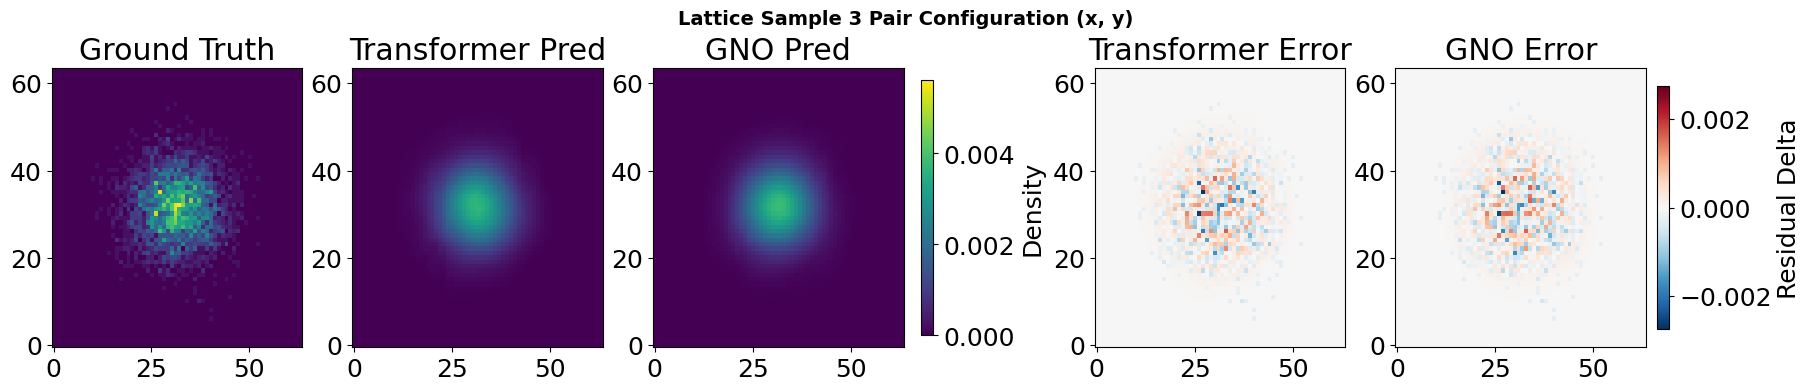

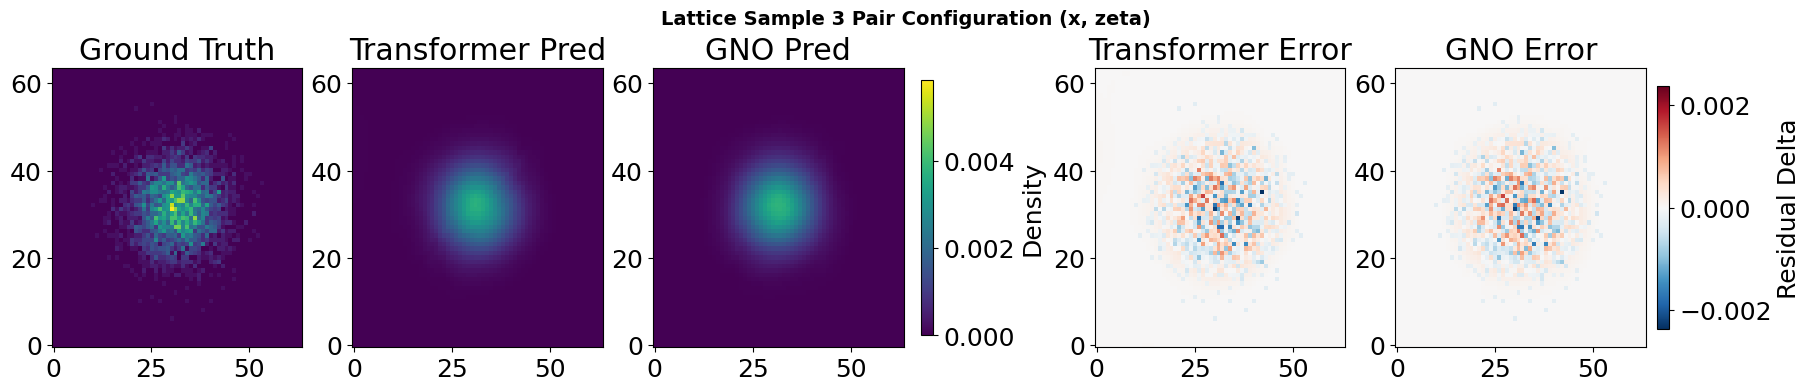

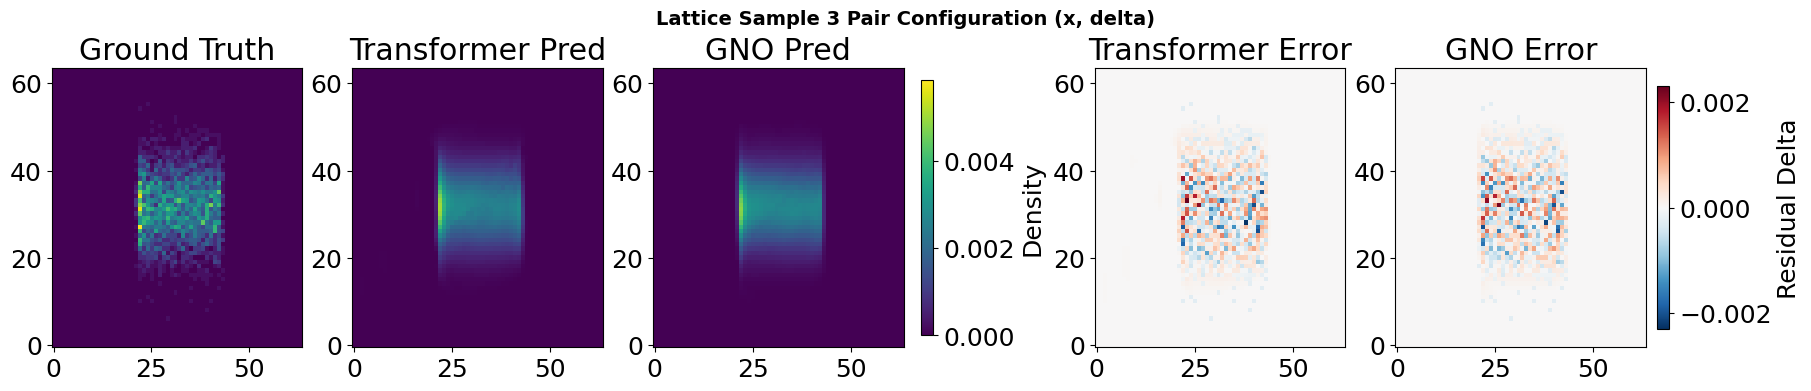

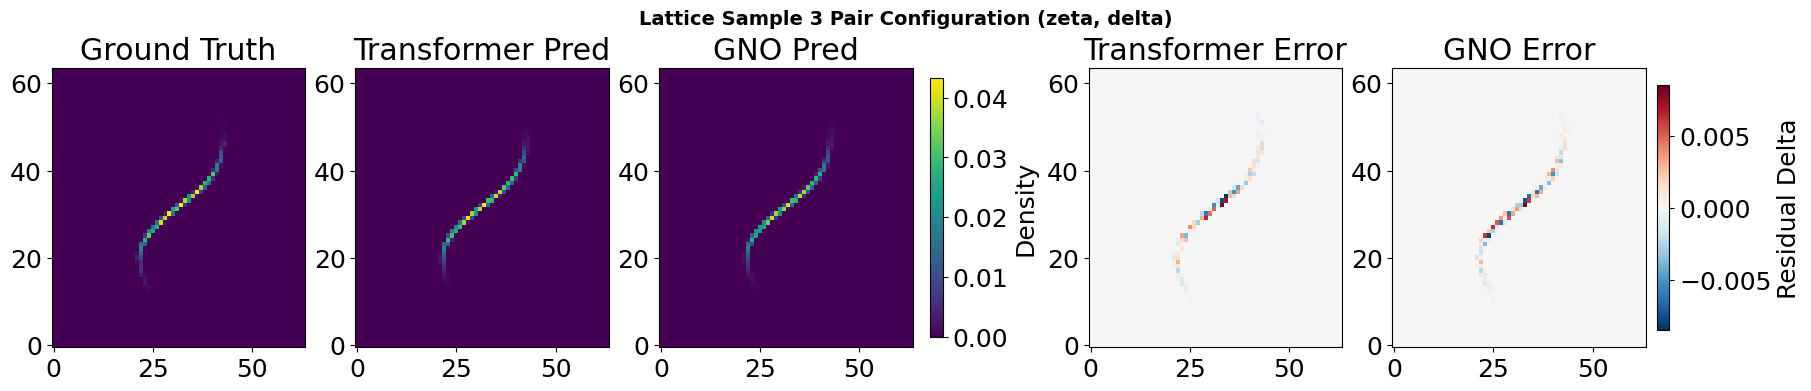

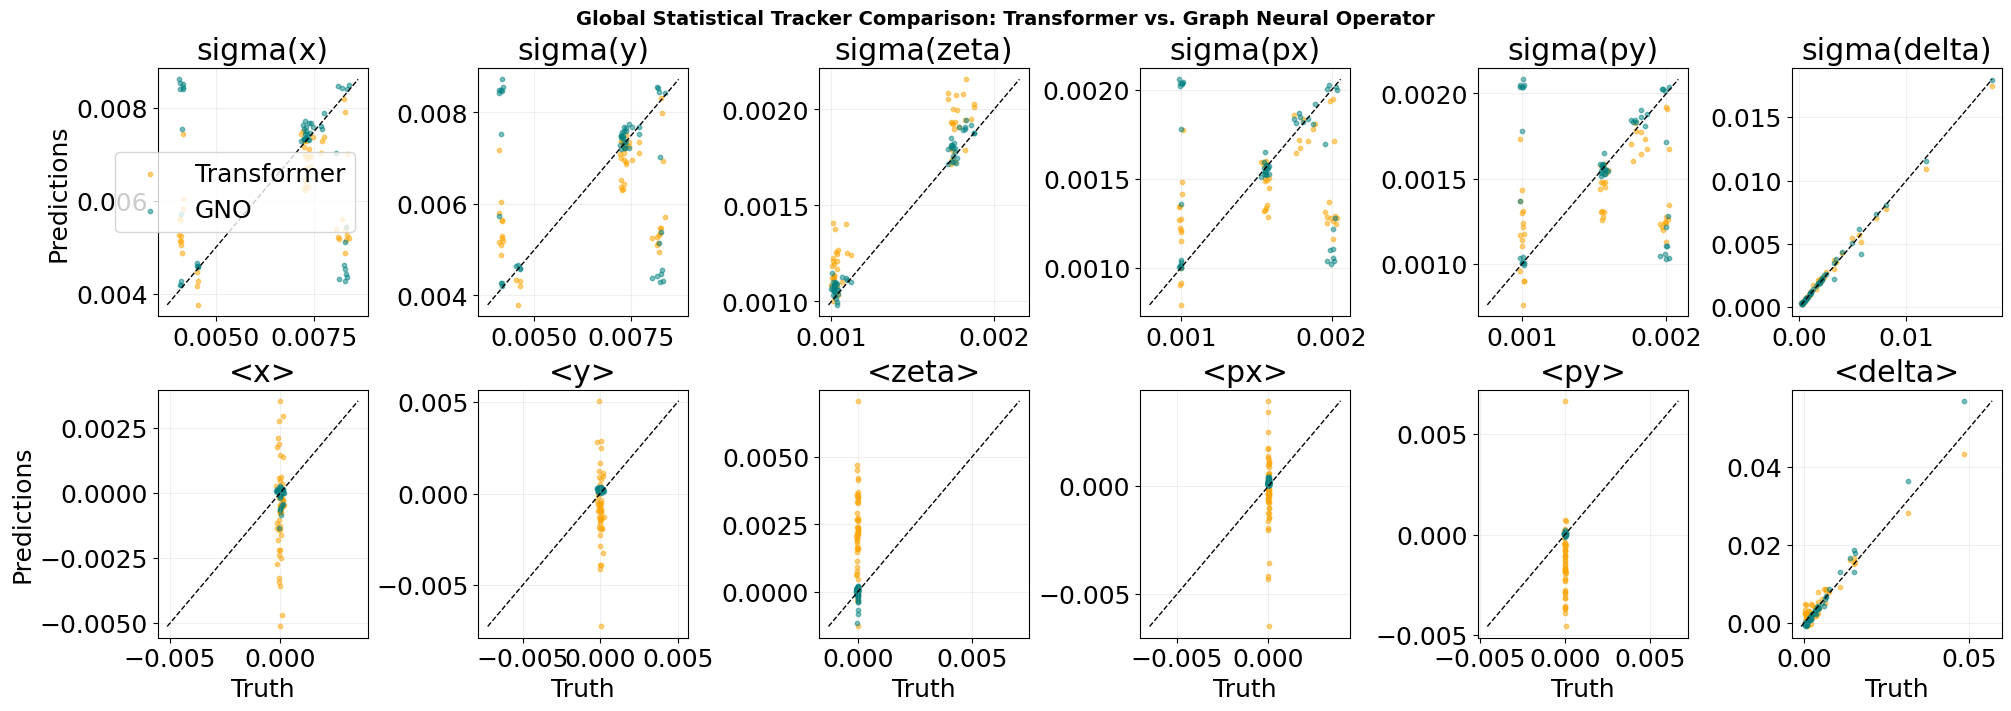

In [139]:

model_trans = BeamLatentTransformerModel(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)
# Fixed the parameter name here:
model_trans.load_state_dict(torch.load('trained_beam_latent_transformer_model.pth', map_location=device))
model_trans.eval()

# Initialize and load weights for the GNO architecture
model_gno = BeamLatentGNOModel(mu_dim=mu_dim, latent_dim=512, d_model=512).to(device)
# Fixed the parameter name here as well:
model_gno.load_state_dict(torch.load('trained_beam_latent_GNO_model.pth', map_location=device))
model_gno.eval()

print("Both models successfully loaded onto device without parameter mismatch errors!")
# Storage arrays for dataset-wide tracking metrics
all_sig_true, all_sig_trans, all_sig_gno = [], [], []
all_cnt_true, all_cnt_trans, all_cnt_gno = [], [], []

# Evaluation Pass
with torch.no_grad():
    for step, (X, Y, MU) in enumerate(val_loader):
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        MU_enc = mu_prep(MU)
        B = X.shape[0]
        domain = MU[:, :2]
        
        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
        
        # Run inference through both pipelines
        out_trans = model_trans(X, MU_enc, elem_params, elem_s, domain)
        out_gno = model_gno(X, MU_enc, elem_params, elem_s, domain)
        
        # Extract ground truth states
        y_hist_truth = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()
        centroid_Y, sigma_Y = beam_centroid_sigma(Y)
        
        # 1. Localized structural profile visualization (Run on the first batch)
        if step == 0:
            y_hat_trans = out_trans["xN_hat"].detach().cpu().numpy()
            y_hat_gno = out_gno["xN_hat"].detach().cpu().numpy()
            
            sample_idx = 3
            pairs_to_plot = [0, 1, 4, 11]  # Select phase space configurations
            
            for pidx in pairs_to_plot:
                i, j = PAIR_INDEX[pidx]
                title_string = f"Lattice Sample {sample_idx} Pair Configuration ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
                
                plot_5_panel_comparison(
                    truth_map=y_hist_truth[sample_idx, pidx],
                    trans_map=y_hat_trans[sample_idx, pidx],
                    gno_map=y_hat_gno[sample_idx, pidx],
                    title=title_string
                )
                plt.show()
                
        # 2. Accumulate tracking metrics for regression scatter evaluations
        all_sig_true.append(sigma_Y.cpu().numpy())
        all_cnt_true.append(centroid_Y.cpu().numpy())
        
        all_sig_trans.append(torch.exp(out_trans["log_sigmaN_hat"]).cpu().numpy())
        all_cnt_trans.append(out_trans["centroidN_hat"].cpu().numpy())
        
        all_sig_gno.append(torch.exp(out_gno["log_sigmaN_hat"]).cpu().numpy())
        all_cnt_gno.append(out_gno["centroidN_hat"].cpu().numpy())

# Compile metrics and generate global scatter comparisons
plot_dual_model_scatter(
    sigma_true=np.concatenate(all_sig_true, axis=0),
    sigma_trans=np.concatenate(all_sig_trans, axis=0),
    sigma_gno=np.concatenate(all_sig_gno, axis=0),
    cent_true=np.concatenate(all_cnt_true, axis=0),
    cent_trans=np.concatenate(all_cnt_trans, axis=0),
    cent_gno=np.concatenate(all_cnt_gno, axis=0)
)
plt.show()

In [140]:
def plot_dual_model_macroparticle_dashboard(
    truth_img, trans_img, gno_img, physical_cloud_after, pair_idx=(2, 5), 
    title="", num_particles=1_000_000, plot_stride=100
):
    """
    Overlays sampled macroparticles from both Transformer and GNO models 
    simultaneously against Ground Truth across any arbitrary phase-space pair.
    """
    truth_img = np.asarray(truth_img)
    trans_img = np.asarray(trans_img)
    gno_img   = np.asarray(gno_img)
    
    ny, nx = truth_img.shape
    i, j = pair_idx  
    
    # --- 1. Get Physical Bounds & Apply Scales Dynamically ---
    h_physical = physical_cloud_after[:, i].astype(np.float64)
    v_physical = physical_cloud_after[:, j].astype(np.float64)
    
    if i == 5: h_physical = h_physical * 100.0
    if j == 5: v_physical = v_physical * 100.0
    
    # SAFE FIX: Handle whether PHASE_SPACE_LABELS is a list/tuple or a dict
    if 'PHASE_SPACE_LABELS' in globals():
        ps_labels = globals()['PHASE_SPACE_LABELS']
        name_h = ps_labels[i] if not hasattr(ps_labels, 'get') else ps_labels.get(i, f'Dim {i}')
        name_v = ps_labels[j] if not hasattr(ps_labels, 'get') else ps_labels.get(j, f'Dim {j}')
    else:
        fallback = {0: 'x', 1: "x'", 2: 'y', 3: "y'", 4: 'z', 5: 'delta'}
        name_h = fallback.get(i, f'Dim {i}')
        name_v = fallback.get(j, f'Dim {j}')
        
    units = {0: "[m]", 1: "[m]", 2: "[m]", 3: "[rad]", 4: "[rad]", 5: "[%]"}
    lbl_h = f"{name_h} {units.get(i, '')}"
    lbl_v = f"{name_v} {units.get(j, '')}"
    
    h_pad = 0.05 * (h_physical.max() - h_physical.min() + 1e-15)
    v_pad = 0.05 * (v_physical.max() - v_physical.min() + 1e-15)
    
    h_min_phys, h_max_phys = h_physical.min() - h_pad, h_physical.max() + h_pad
    v_min_phys, v_max_phys = v_physical.min() - v_pad, v_physical.max() + v_pad

    h_bin_width = (h_max_phys - h_min_phys) / nx
    v_bin_width = (v_max_phys - v_min_phys) / ny
    
    h_center_min, h_center_max = h_min_phys + 0.5 * h_bin_width, h_max_phys - 0.5 * h_bin_width
    v_center_min, v_center_max = v_min_phys + 0.5 * v_bin_width, v_max_phys - 0.5 * v_bin_width

    # --- 2. Sample Particles across all 3 Image Domains ---
    h_t_pix, v_t_pix = sample_macroparticles_2d(truth_img, num_particles)
    h_trans_pix, v_trans_pix = sample_macroparticles_2d(trans_img, num_particles)
    h_gno_pix, v_gno_pix = sample_macroparticles_2d(gno_img, num_particles)
    
    # --- 3. Map to Physical Values ---
    h_t = np.interp(h_t_pix, [0, nx - 1], [h_center_min, h_center_max])
    v_t = np.interp(v_t_pix, [0, ny - 1], [v_center_min, v_center_max])
    
    h_trans = np.interp(h_trans_pix, [0, nx - 1], [h_center_min, h_center_max])
    v_trans = np.interp(v_trans_pix, [0, ny - 1], [v_center_min, v_center_max])
    
    h_gno = np.interp(h_gno_pix, [0, nx - 1], [h_center_min, h_center_max])
    v_gno = np.interp(v_gno_pix, [0, ny - 1], [v_center_min, v_center_max])
    
    # --- 4. Sort & Compute Physical Residuals ---
    h_t, h_trans, h_gno = np.sort(h_t), np.sort(h_trans), np.sort(h_gno)
    v_t, v_trans, v_gno = np.sort(v_t), np.sort(v_trans), np.sort(v_gno)
    
    res_h_trans, res_h_gno = h_trans - h_t, h_gno - h_t
    res_v_trans, res_v_gno = v_trans - v_t, v_gno - v_t

    # --- 5. Downsample Strides for Plot Rendering Performance ---
    h_t_p, h_trans_p, h_gno_p = h_t[::plot_stride], h_trans[::plot_stride], h_gno[::plot_stride]
    v_t_p, v_trans_p, v_gno_p = v_t[::plot_stride], v_trans[::plot_stride], v_gno[::plot_stride]
    res_h_trans_p, res_h_gno_p = res_h_trans[::plot_stride], res_h_gno[::plot_stride]
    res_v_trans_p, res_v_gno_p = res_v_trans[::plot_stride], res_v_gno[::plot_stride]

    # Setup Axes Limits
    h_all = np.concatenate([h_t_p, h_trans_p, h_gno_p])
    lim_h = [h_all.min() - 0.02 * abs(h_all.min()), h_all.max() + 0.02 * abs(h_all.max())]
    v_all = np.concatenate([v_t_p, v_trans_p, v_gno_p])
    lim_v = [v_all.min() - 0.02 * abs(v_all.min()), v_all.max() + 0.02 * abs(v_all.max())]

    max_res_h = max(abs(res_h_trans_p.min()), res_h_trans_p.max(), abs(res_h_gno_p.min()), res_h_gno_p.max()) * 1.15
    max_res_v = max(abs(res_v_trans_p.min()), res_v_trans_p.max(), abs(res_v_gno_p.min()), res_v_gno_p.max()) * 1.15

    # --- 6. Construct Layout ---
    fig = plt.figure(figsize=(20, 12), constrained_layout=False)
    gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.45], hspace=0.0, wspace=0.38)
    
    ax0 = fig.add_subplot(gs[0, 0])             # Top Left: Horiz Correlation
    ax2 = fig.add_subplot(gs[1, 0], sharex=ax0) # Bottom Left: Horiz Residual
    ax1 = fig.add_subplot(gs[0, 1])             # Top Right: Vert Correlation
    ax3 = fig.add_subplot(gs[1, 1], sharex=ax1) # Bottom Right: Vert Residual

    # =========================================================================
    # COLUMN 1: HORIZONTAL PARAMETER COMPARISON
    # =========================================================================
    ax0.scatter(h_t_p, h_trans_p, color='darkorange', alpha=0.25, s=8, label='Transformer', edgecolors='none')
    ax0.scatter(h_t_p, h_gno_p, color='teal', alpha=0.25, s=8, label='GNO', edgecolors='none')
    ax0.plot(lim_h, lim_h, 'k--', lw=1.5, label='Ideal Matrix ($y=x$)')
    ax0.set_ylabel(f"Predicted {lbl_h}")
    ax0.set_xlim(lim_h); ax0.set_ylim(lim_h)
    ax0.grid(True, alpha=0.2); ax0.legend(loc='upper left')
    plt.setp(ax0.get_xticklabels(), visible=False) 

    ax2.scatter(h_t_p, res_h_trans_p, color='darkorange', alpha=0.25, s=8, edgecolors='none')
    ax2.scatter(h_t_p, res_h_gno_p, color='teal', alpha=0.25, s=8, edgecolors='none')
    ax2.axhline(0, color='black', lw=1.5)
    ax2.set_xlabel(f"True {lbl_h}")
    ax2.set_ylabel(r"Residual $\Delta$ " + f"{name_h}") # FIXED
    ax2.set_ylim(-max_res_h, max_res_h)
    ax2.grid(True, alpha=0.2)
    
    # Dual Density Histogram Ruler (Right Side)
    ax2_ruler = ax2.twinx()
    counts_h_tr, edges_h = np.histogram(res_h_trans, bins=35, range=(-max_res_h, max_res_h))
    counts_h_gno, _      = np.histogram(res_h_gno, bins=35, range=(-max_res_h, max_res_h))
    centers_h = 0.5 * (edges_h[:-1] + edges_h[1:])
    
    xmin_v, xmax_v = ax2.get_xlim()
    xr_v = xmax_v - xmin_v
    max_h_peak = max(counts_h_tr.max(), counts_h_gno.max())
    
    fuzz_tr_h = xmax_v - (counts_h_tr.astype(float) / max_h_peak) * (xr_v * 0.25)
    fuzz_gno_h = xmax_v - (counts_h_gno.astype(float) / max_h_peak) * (xr_v * 0.25)
    
    ax2_ruler.fill_betweenx(centers_h, xmax_v, fuzz_tr_h, color='darkorange', alpha=0.3, step='mid', edgecolor='none')
    ax2_ruler.fill_betweenx(centers_h, xmax_v, fuzz_gno_h, color='teal', alpha=0.3, step='mid', edgecolor='none')
    ax2_ruler.set_xlim(xmin_v, xmax_v); ax2_ruler.set_ylim(-max_res_h, max_res_h)
    plt.setp(ax2_ruler.get_yticklabels(), visible=False)

    # =========================================================================
    # COLUMN 2: VERTICAL PARAMETER COMPARISON
    # =========================================================================
    ax1.scatter(v_t_p, v_trans_p, color='darkorange', alpha=0.25, s=8, label='Transformer', edgecolors='none')
    ax1.scatter(v_t_p, v_gno_p, color='teal', alpha=0.25, s=8, label='GNO', edgecolors='none')
    ax1.plot(lim_v, lim_v, 'k--', lw=1.5, label='Ideal Matrix ($y=x$)')
    ax1.set_ylabel(f"Predicted {lbl_v}")
    ax1.set_xlim(lim_v); ax1.set_ylim(lim_v)
    ax1.grid(True, alpha=0.2); ax1.legend(loc='upper left')
    plt.setp(ax1.get_xticklabels(), visible=False) 

    ax3.scatter(v_t_p, res_v_trans_p, color='darkorange', alpha=0.25, s=8, edgecolors='none')
    ax3.scatter(v_t_p, res_v_gno_p, color='teal', alpha=0.25, s=8, edgecolors='none')
    ax3.axhline(0, color='black', lw=1.5)
    ax3.set_xlabel(f"True {lbl_v}")
    ax3.set_ylabel(r"Residual $\Delta$ " + f"{name_v}") # FIXED
    ax3.set_ylim(-max_res_v, max_res_v)
    ax3.grid(True, alpha=0.2)
    
    # Dual Density Histogram Ruler (Right Side)
    ax3_ruler = ax3.twinx()
    counts_v_tr, edges_v = np.histogram(res_v_trans, bins=35, range=(-max_res_v, max_res_v))
    counts_v_gno, _      = np.histogram(res_v_gno, bins=35, range=(-max_res_v, max_res_v))
    centers_v = 0.5 * (edges_v[:-1] + edges_v[1:])
    
    xmin_v, xmax_v = ax3.get_xlim()
    xr_v = xmax_v - xmin_v
    max_v_peak = max(counts_v_tr.max(), counts_v_gno.max())
    
    fuzz_tr_v = xmax_v - (counts_v_tr.astype(float) / max_v_peak) * (xr_v * 0.25)
    fuzz_gno_v = xmax_v - (counts_v_gno.astype(float) / max_v_peak) * (xr_v * 0.25)
    
    ax3_ruler.fill_betweenx(centers_v, xmax_v, fuzz_tr_v, color='darkorange', alpha=0.3, step='mid', edgecolor='none')
    ax3_ruler.fill_betweenx(centers_v, xmax_v, fuzz_gno_v, color='teal', alpha=0.3, step='mid', edgecolor='none')
    ax3_ruler.set_xlim(xmin_v, xmax_v); ax3_ruler.set_ylim(-max_res_v, max_res_v)
    plt.setp(ax3_ruler.get_yticklabels(), visible=False)
    
    plt.subplots_adjust(bottom=0.1, top=0.90, left=0.10, right=0.90, wspace=0.40, hspace=0.0)
    fig.suptitle(title, y=0.96, weight='bold', fontsize=22)
    plt.savefig("macroparticle_simultaneous_residuals.pdf", bbox_inches='tight')
    plt.show()

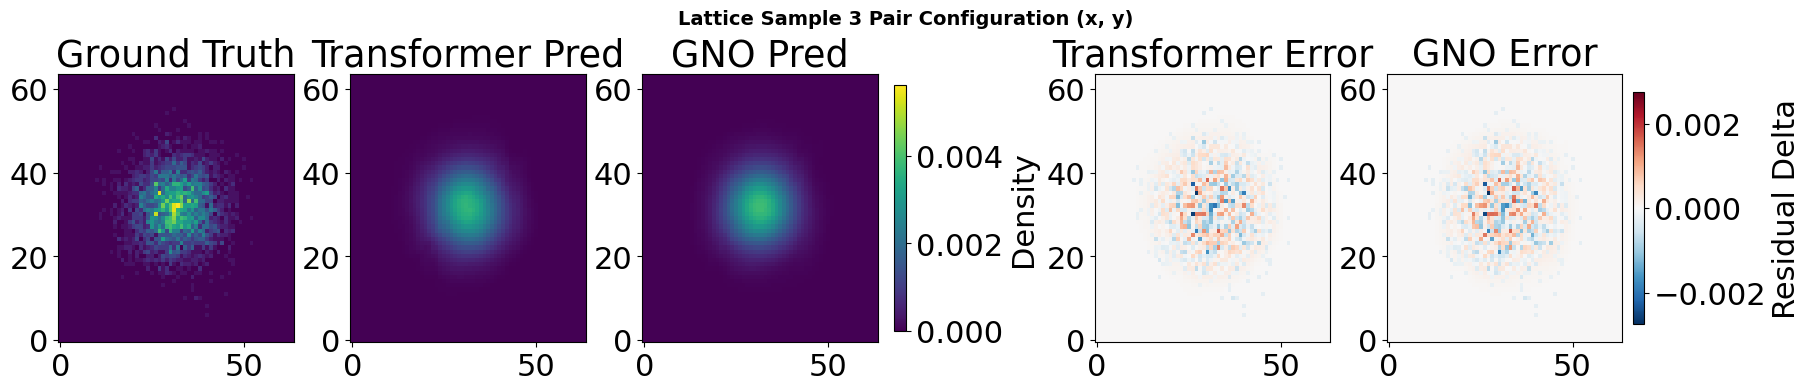

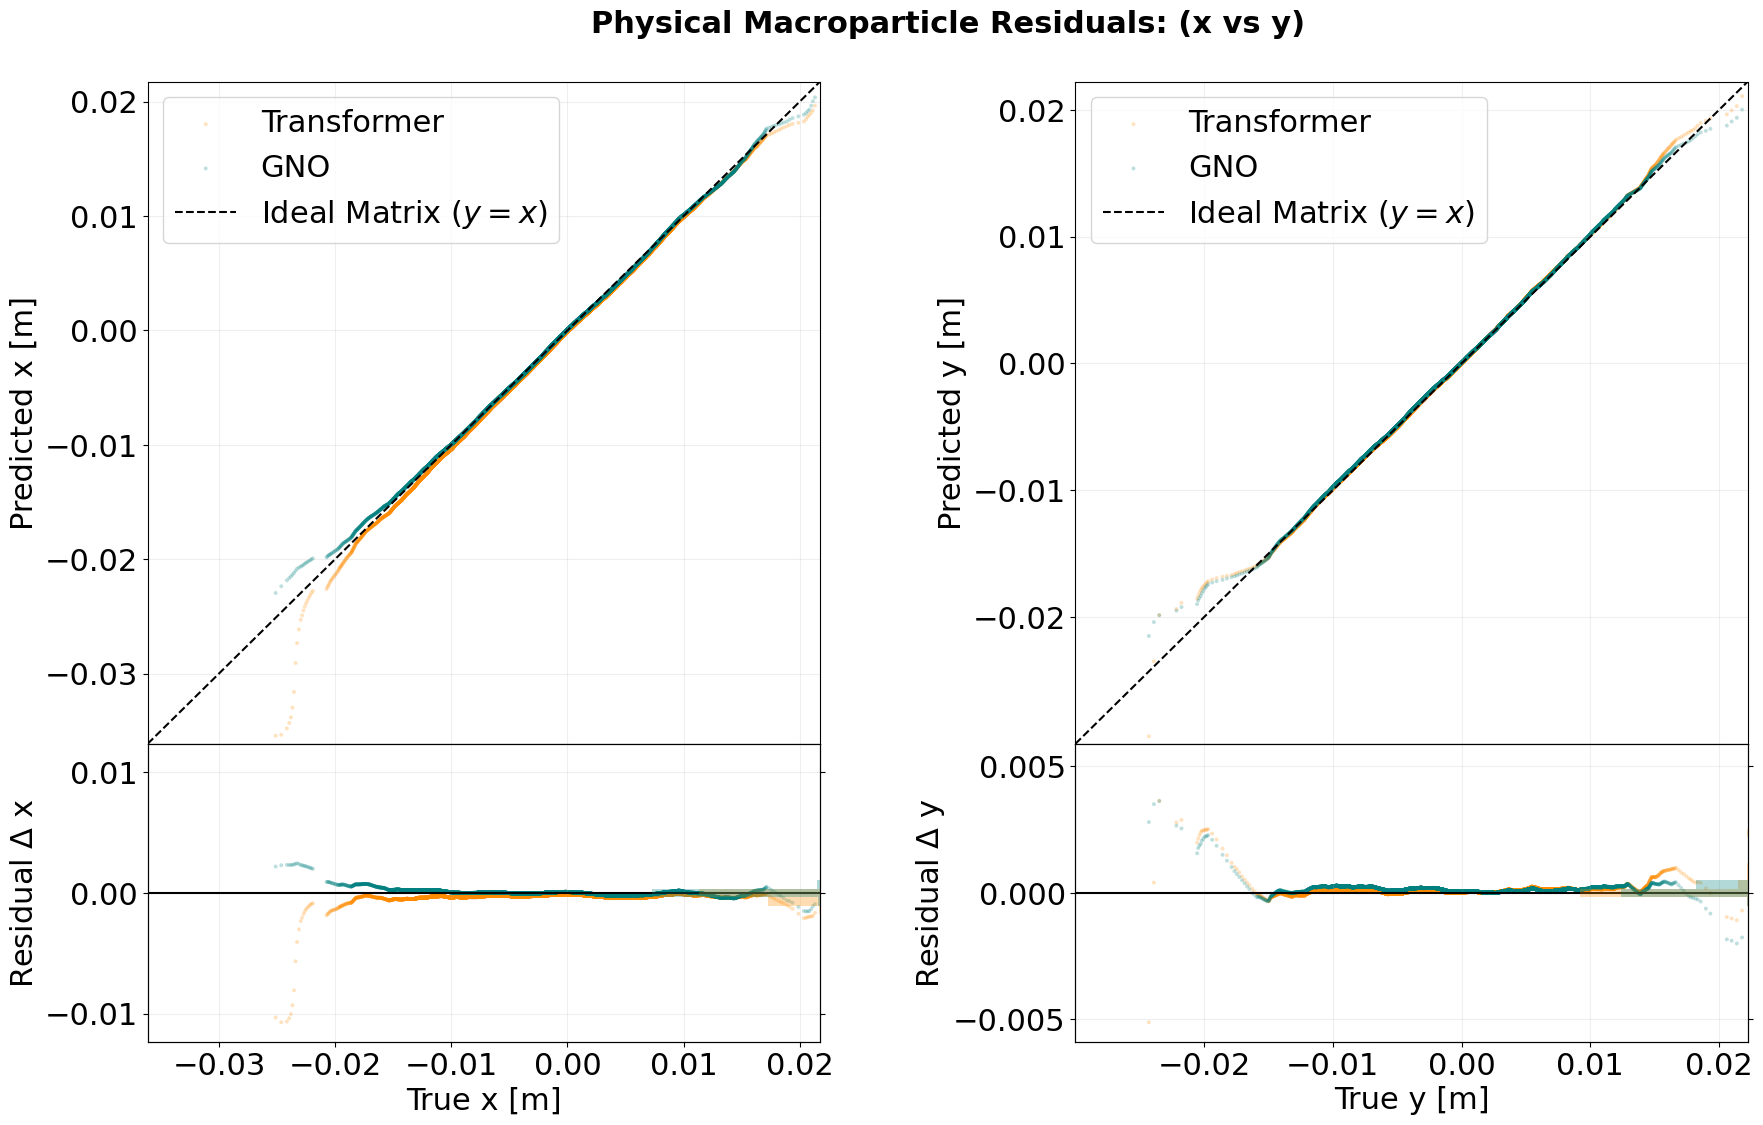

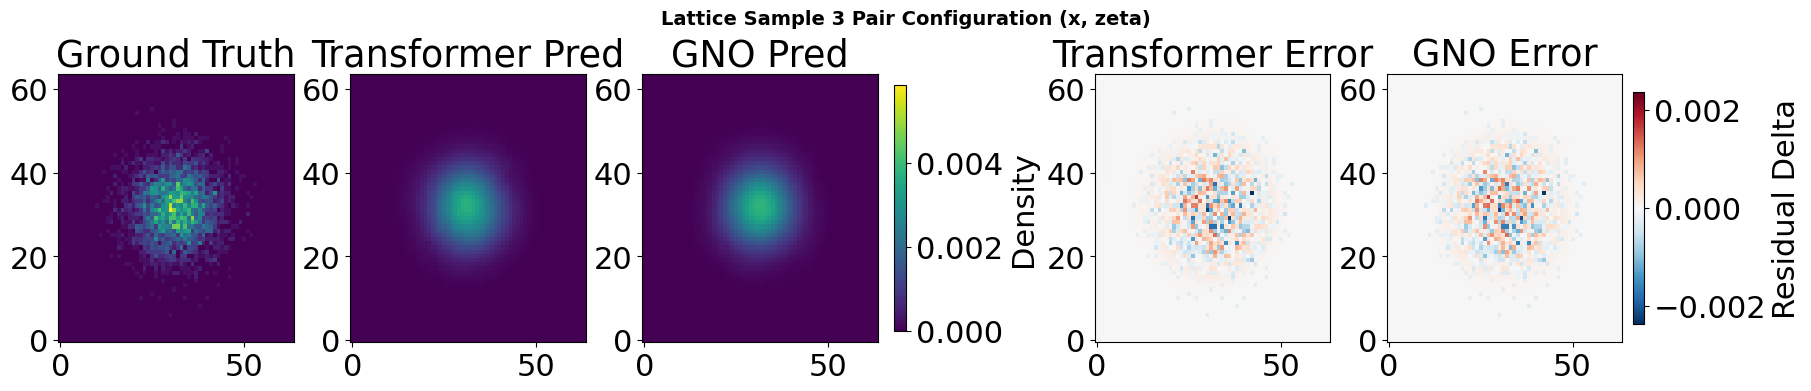

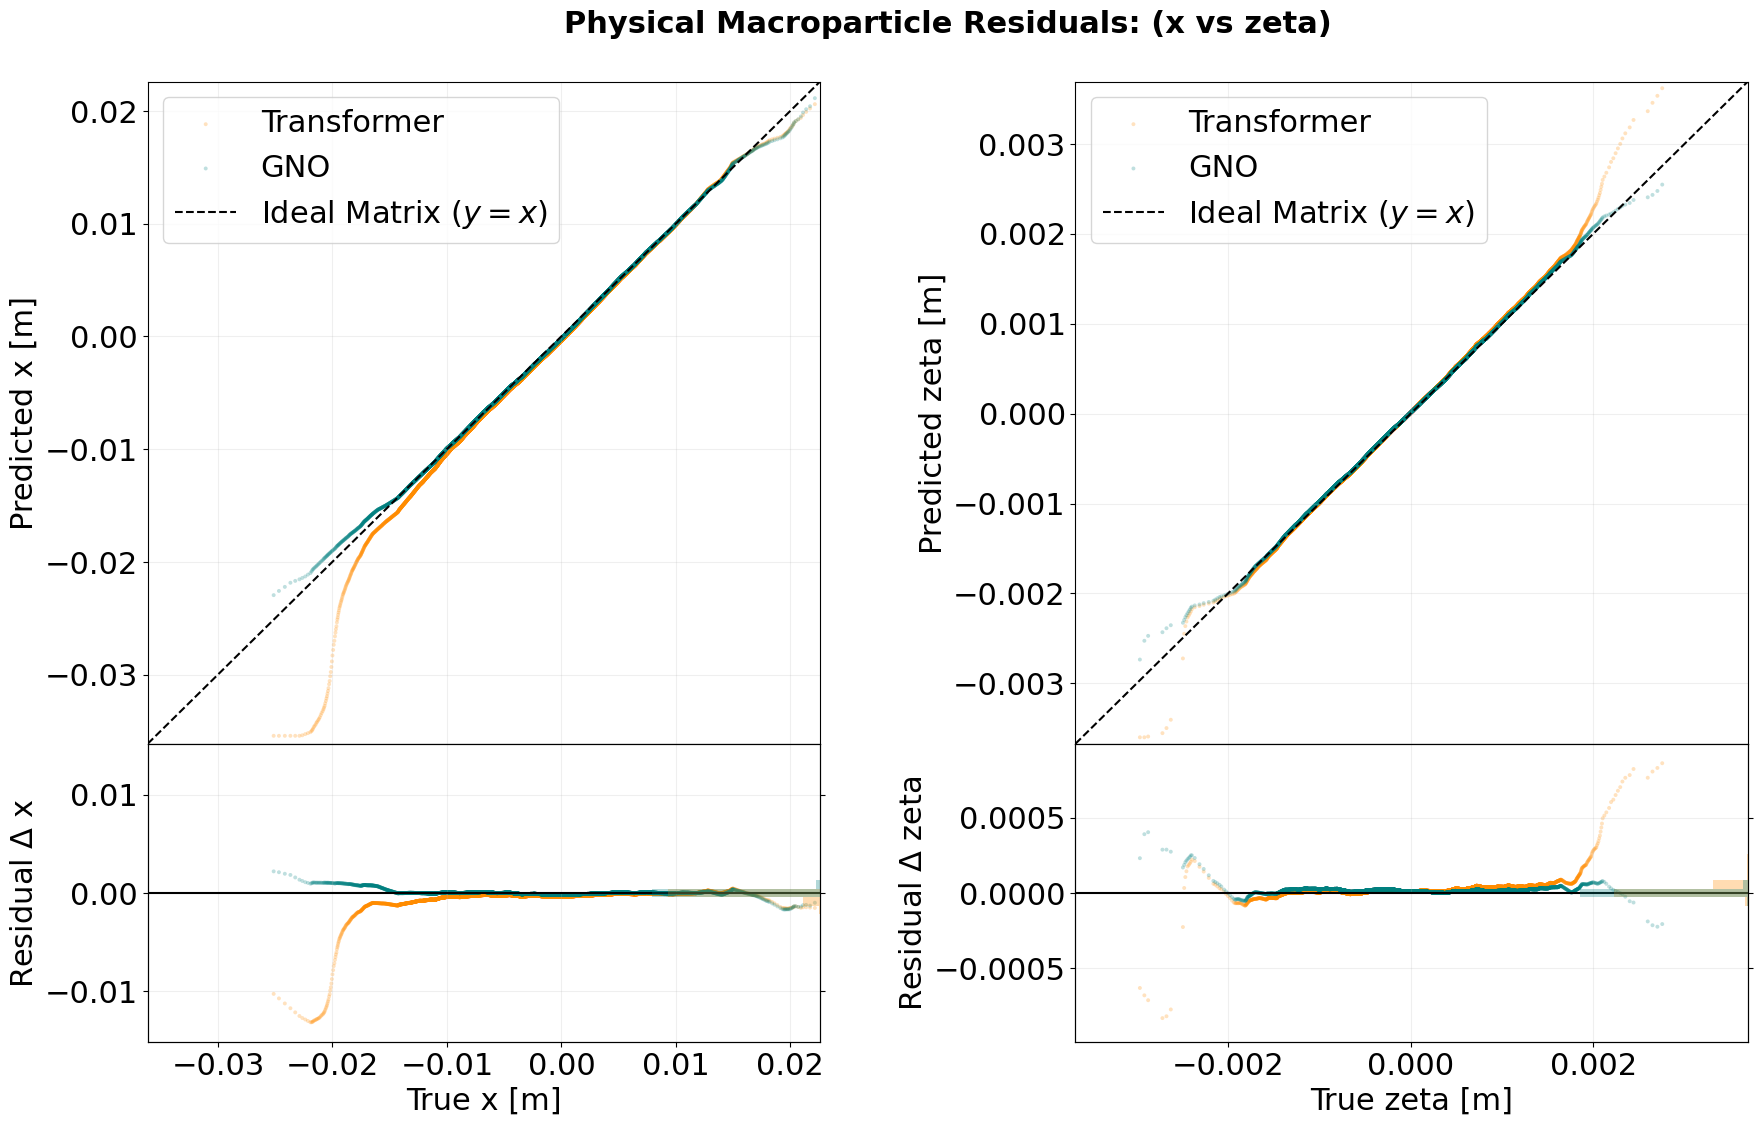

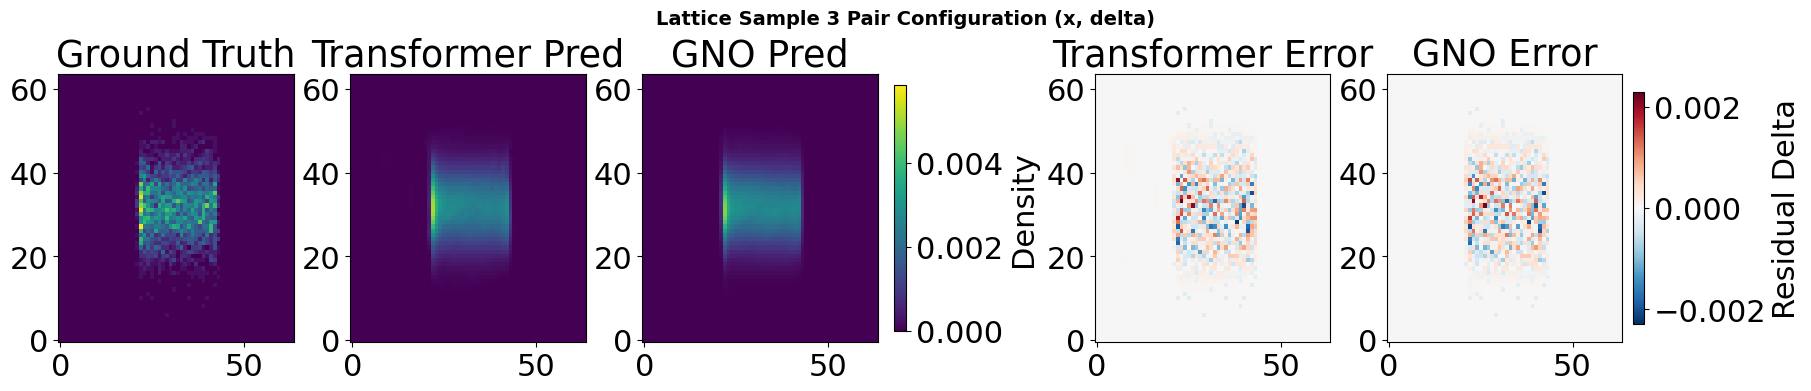

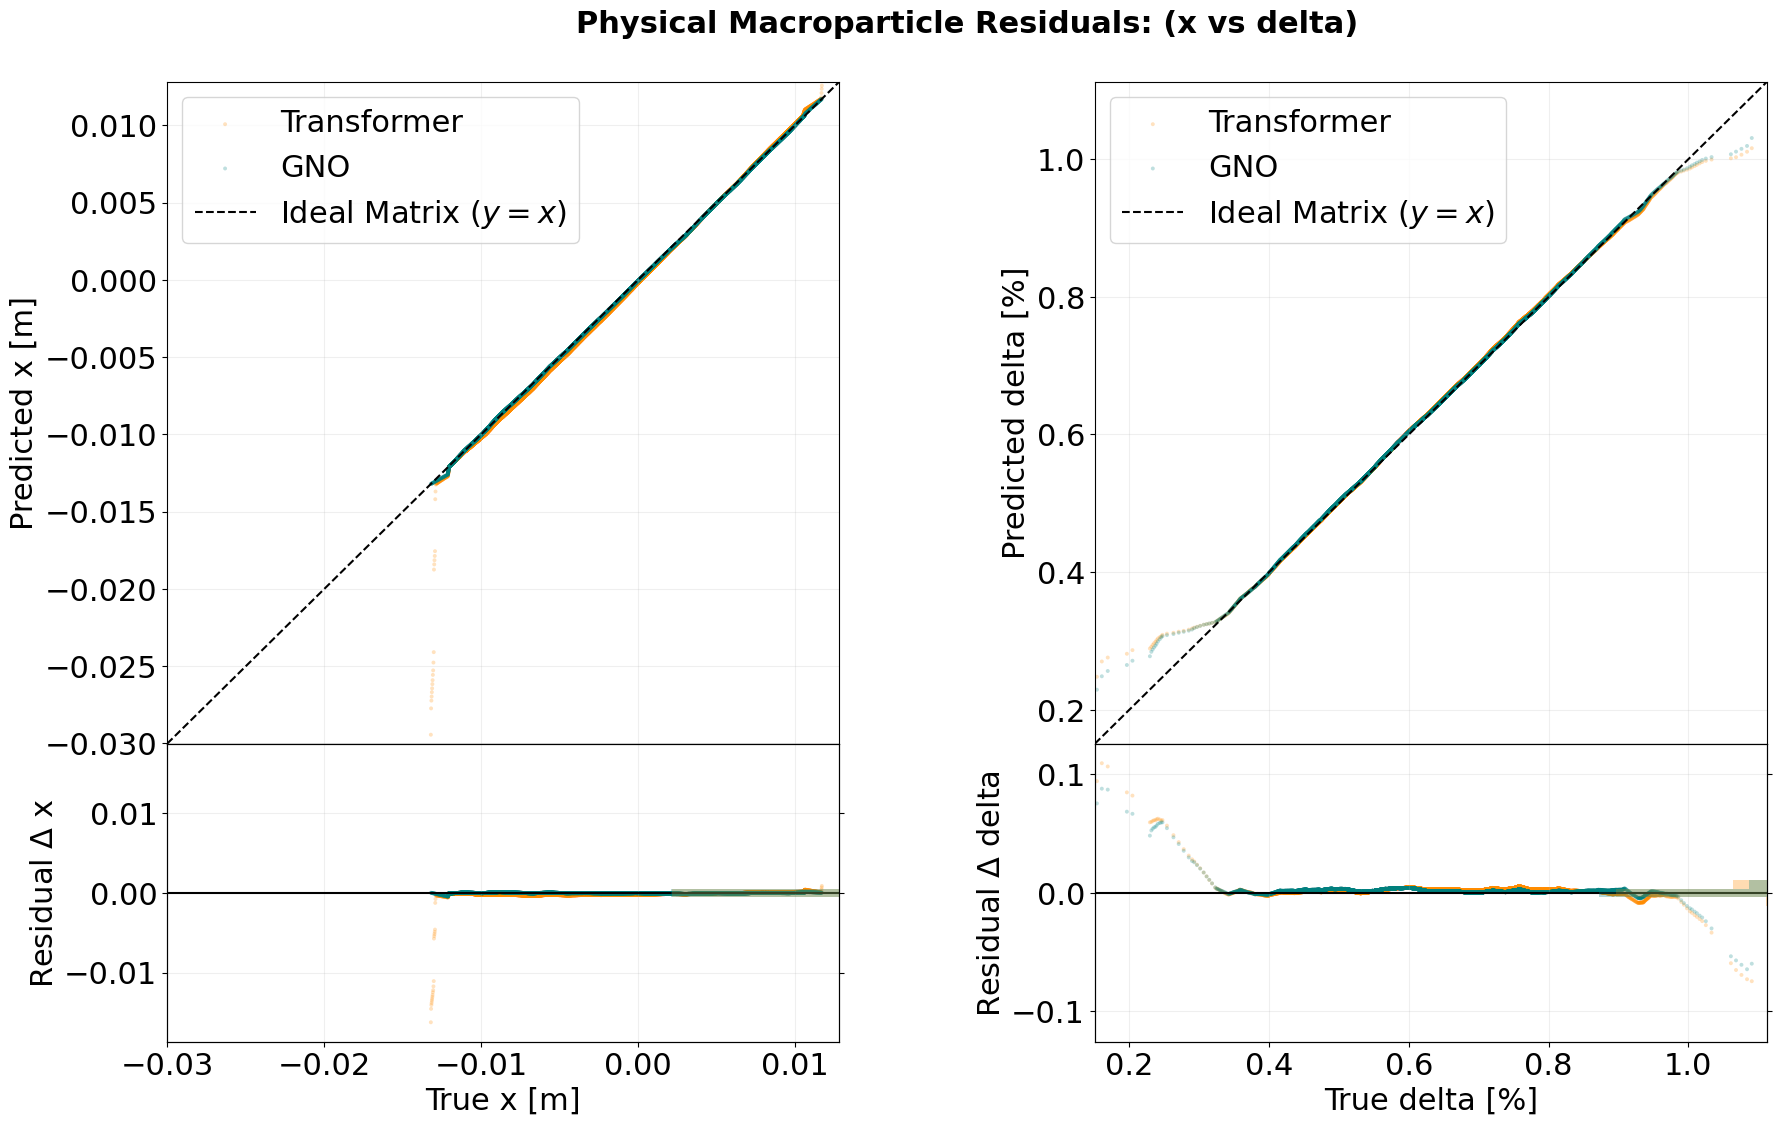

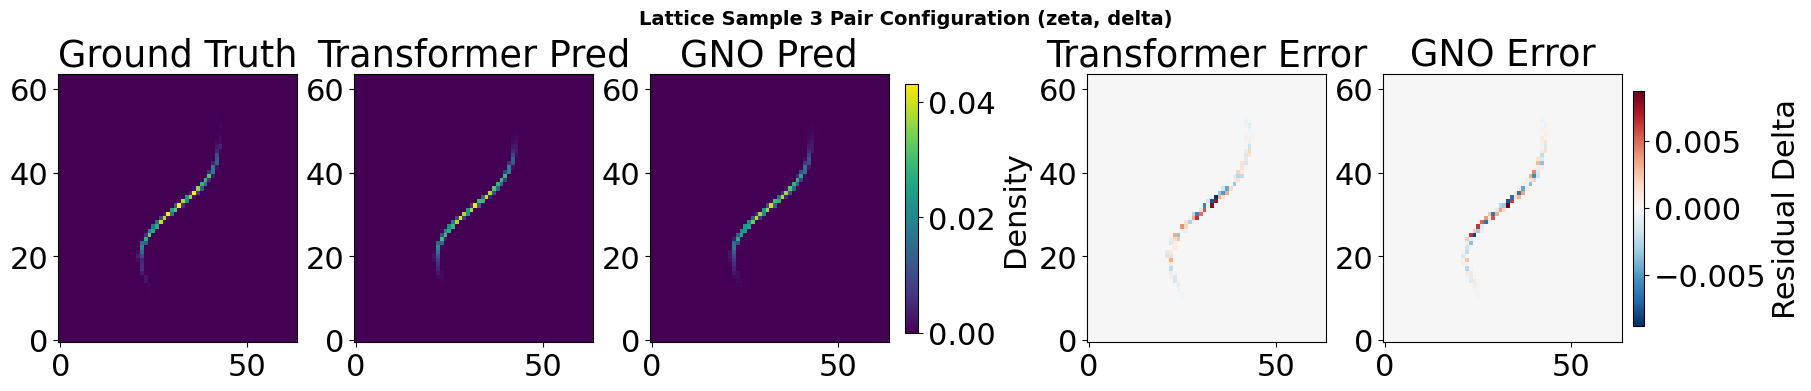

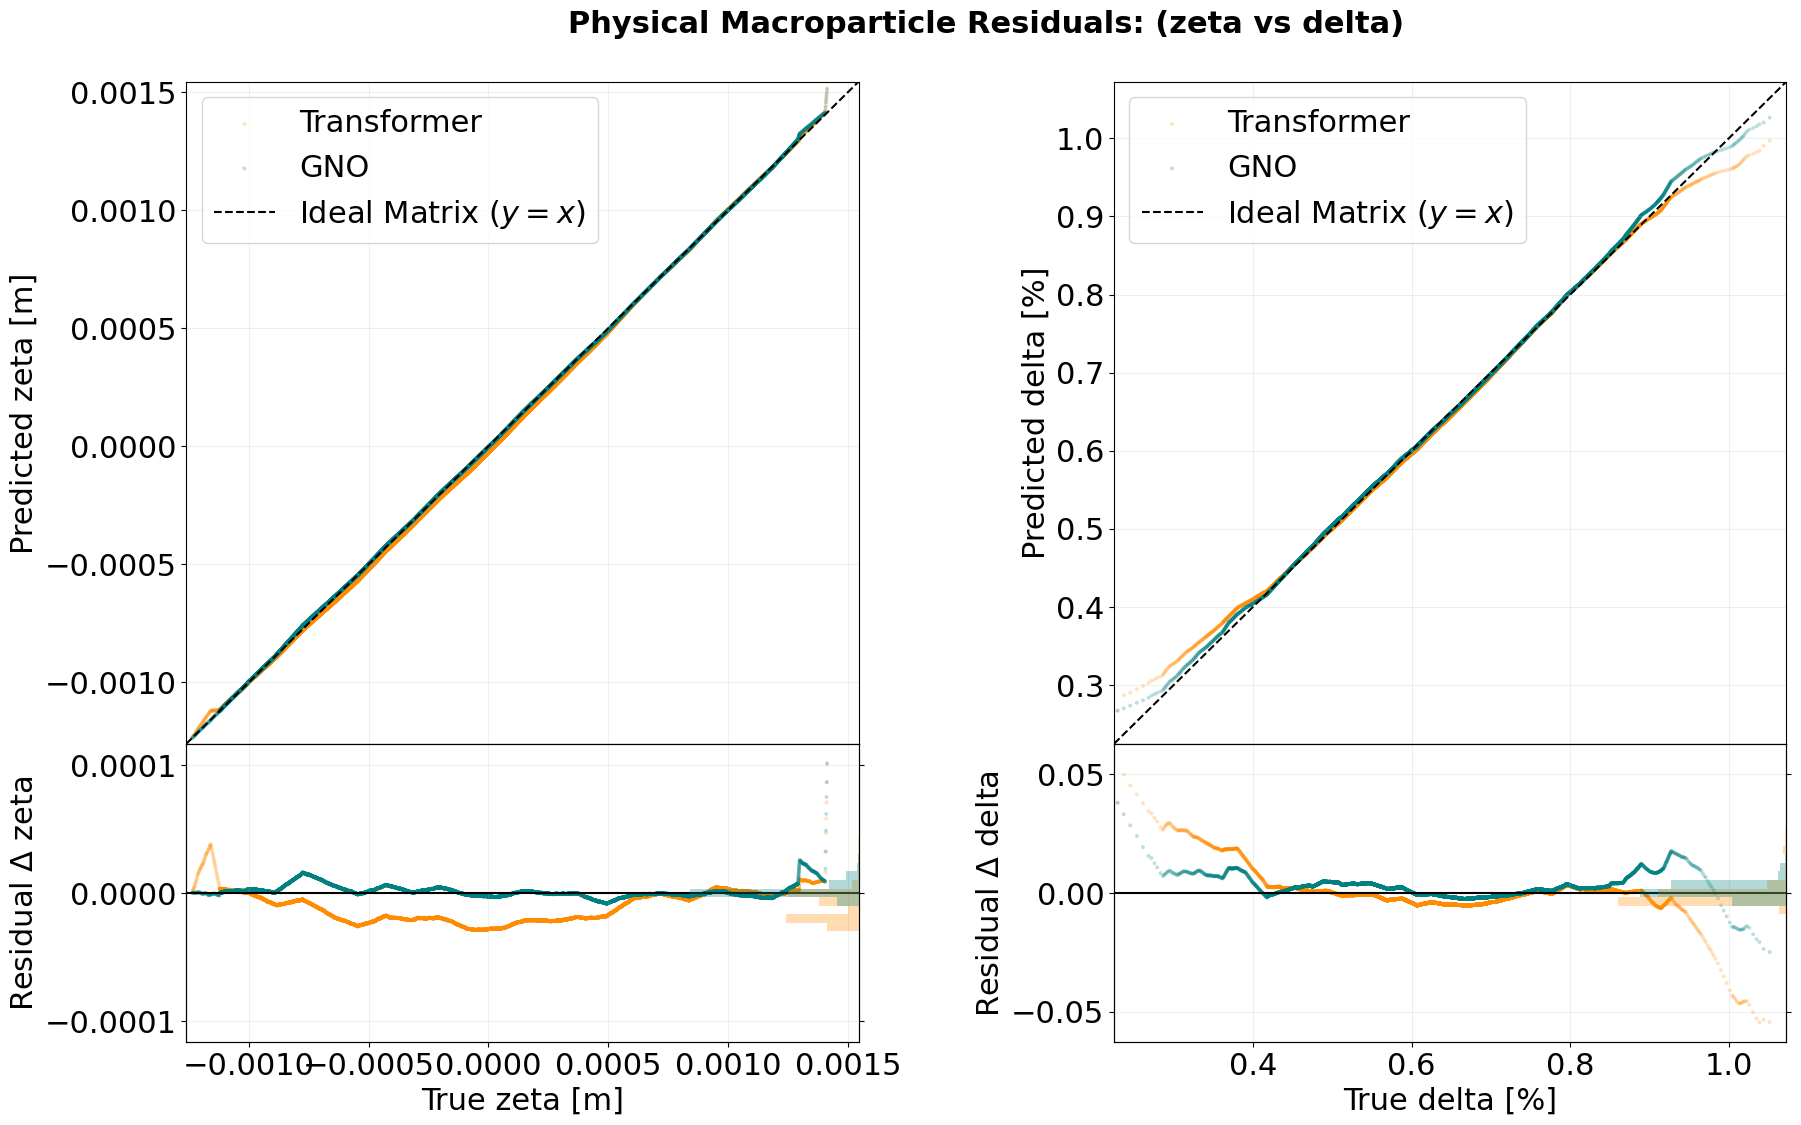

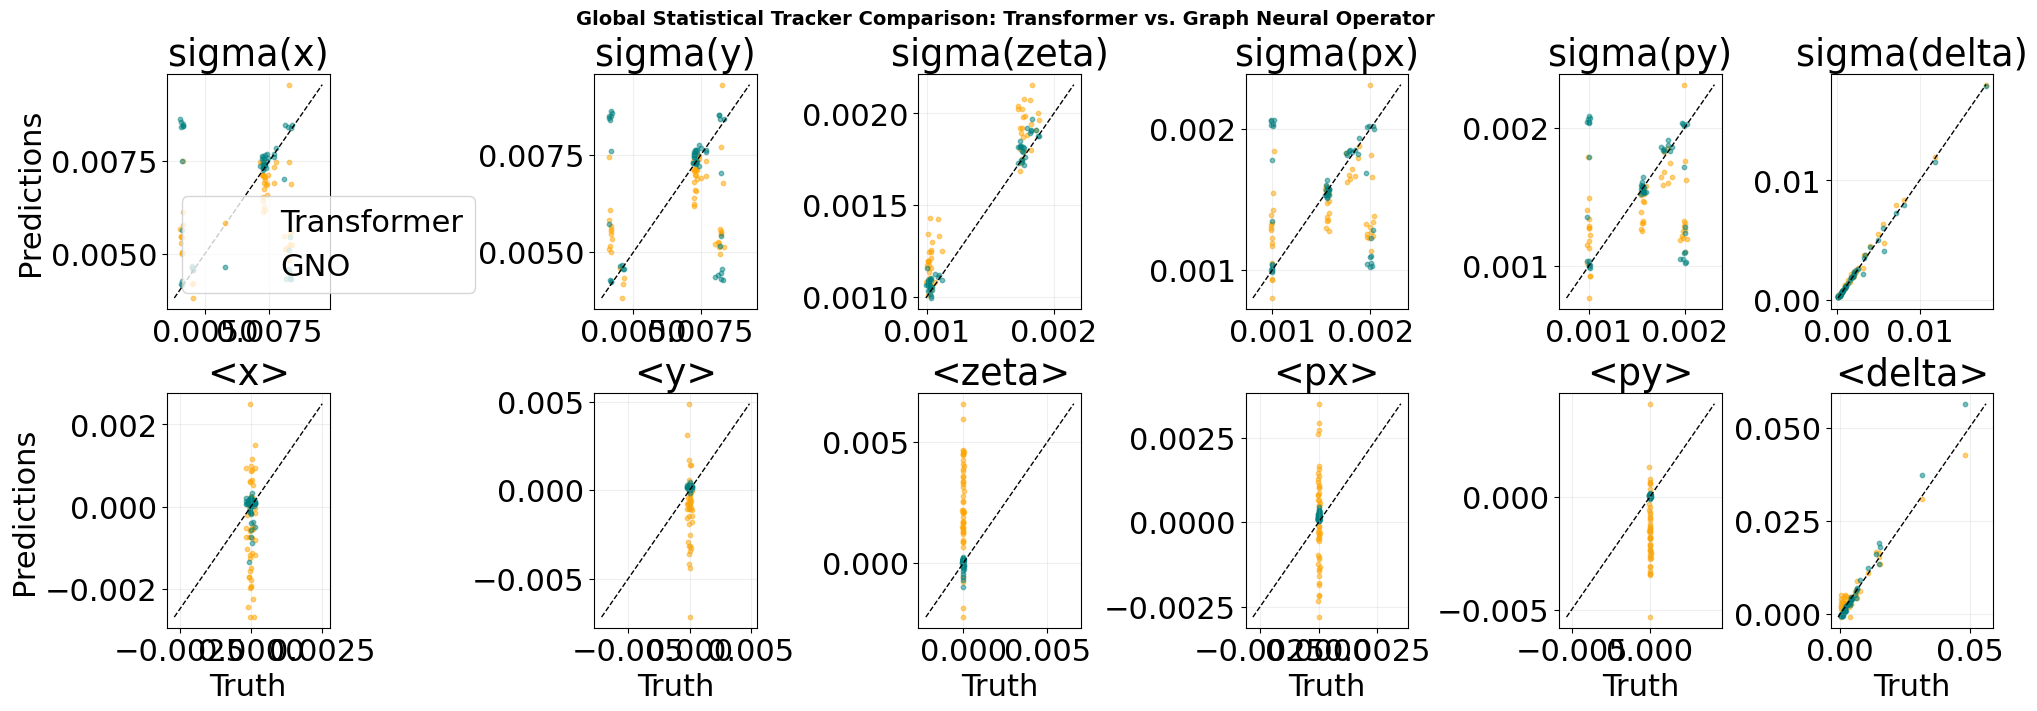

In [141]:
# Storage arrays for dataset-wide tracking metrics
all_sig_true, all_sig_trans, all_sig_gno = [], [], []
all_cnt_true, all_cnt_trans, all_cnt_gno = [], [], []

plt.rcParams.update({'font.size': 22})

# Evaluation Pass
with torch.no_grad():
    for step, (X, Y, MU) in enumerate(val_loader):
        X, Y, MU = X.to(device), Y.to(device), MU.to(device)
        MU_enc = mu_prep(MU)
        B = X.shape[0]
        domain = MU[:, :2]
        
        elem_params, elem_s = make_dummy_lattice_tokens(B, N_elem, device)
        
        # Run inference through both pipelines
        out_trans = model_trans(X, MU_enc, elem_params, elem_s, domain)
        out_gno = model_gno(X, MU_enc, elem_params, elem_s, domain)
        
        # Extract ground truth states
        y_hist_truth = cloud_to_pairwise_hists(Y, nbins=64).detach().cpu().numpy()
        centroid_Y, sigma_Y = beam_centroid_sigma(Y)
        
        # 1. Localized structural profile & Macroparticle visualization (Run on first batch)
        if step == 0:
            y_hat_trans = out_trans["xN_hat"].detach().cpu().numpy()
            y_hat_gno = out_gno["xN_hat"].detach().cpu().numpy()
            
            sample_idx = 3
            pairs_to_plot = [0, 1, 4, 11]  # Select phase space configurations
            
            # Extract the raw physical macroparticle coordinates for this specific sample element
            physical_particles = Y[sample_idx].detach().cpu().numpy()
            
            for pidx in pairs_to_plot:
                i, j = PAIR_INDEX[pidx]
                title_string = f"Lattice Sample {sample_idx} Pair Configuration ({PHASE_SPACE_LABELS[i]}, {PHASE_SPACE_LABELS[j]})"
                
                # --- Visualization A: Standard 5-Panel Density Comparison ---
                plot_5_panel_comparison(
                    truth_map=y_hist_truth[sample_idx, pidx],
                    trans_map=y_hat_trans[sample_idx, pidx],
                    gno_map=y_hat_gno[sample_idx, pidx],
                    title=title_string
                )
                plt.show()
                
                # --- Visualization B: Integrated Dual-Model Macroparticle Dashboard ---
                macro_title = f"Physical Macroparticle Residuals: ({PHASE_SPACE_LABELS[i]} vs {PHASE_SPACE_LABELS[j]})"
                plot_dual_model_macroparticle_dashboard(
                    truth_img=y_hist_truth[sample_idx, pidx],
                    trans_img=y_hat_trans[sample_idx, pidx],
                    gno_img=y_hat_gno[sample_idx, pidx],
                    physical_cloud_after=physical_particles,
                    pair_idx=PAIR_INDEX[pidx],  # Dynamically unpacks the matching (i, j) coordinates
                    title=macro_title,
                    num_particles=1_000_000,
                    plot_stride=100
                )
                
        # 2. Accumulate tracking metrics for regression scatter evaluations
        all_sig_true.append(sigma_Y.cpu().numpy())
        all_cnt_true.append(centroid_Y.cpu().numpy())
        
        all_sig_trans.append(torch.exp(out_trans["log_sigmaN_hat"]).cpu().numpy())
        all_cnt_trans.append(out_trans["centroidN_hat"].cpu().numpy())
        
        all_sig_gno.append(torch.exp(out_gno["log_sigmaN_hat"]).cpu().numpy())
        all_cnt_gno.append(out_gno["centroidN_hat"].cpu().numpy())

# Compile metrics and generate global scatter comparisons
plot_dual_model_scatter(
    sigma_true=np.concatenate(all_sig_true, axis=0),
    sigma_trans=np.concatenate(all_sig_trans, axis=0),
    sigma_gno=np.concatenate(all_sig_gno, axis=0),
    cent_true=np.concatenate(all_cnt_true, axis=0),
    cent_trans=np.concatenate(all_cnt_trans, axis=0),
    cent_gno=np.concatenate(all_cnt_gno, axis=0)
)
plt.show()